In [1]:
!pip install numpy==1.23.5
!pip install wfdb==4.1.2

In [2]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [3]:
import pandas as pd
import os

data_path = "D:/heart_disease/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"

print("Files:", os.listdir(data_path))

df = pd.read_csv("D:\heart_disease\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\ptbxl_database.csv")
print(df.head())
print("Total samples:", len(df))


Files: ['example_physionet.py', 'LICENSE.txt', 'ptbxl_database.csv', 'ptbxl_v102_changelog.txt', 'ptbxl_v103_changelog.txt', 'RECORDS', 'records100', 'records500', 'scp_statements.csv', 'SHA256SUMS.txt']
   ecg_id  patient_id   age  sex  height  weight  nurse  site     device  \
0       1     15709.0  56.0    1     NaN    63.0    2.0   0.0  CS-12   E   
1       2     13243.0  19.0    0     NaN    70.0    2.0   0.0  CS-12   E   
2       3     20372.0  37.0    1     NaN    69.0    2.0   0.0  CS-12   E   
3       4     17014.0  24.0    0     NaN    82.0    2.0   0.0  CS-12   E   
4       5     17448.0  19.0    1     NaN    70.0    2.0   0.0  CS-12   E   

        recording_date  ... validated_by_human  baseline_drift static_noise  \
0  1984-11-09 09:17:34  ...               True             NaN    , I-V1,     
1  1984-11-14 12:55:37  ...               True             NaN          NaN   
2  1984-11-15 12:49:10  ...               True             NaN          NaN   
3  1984-11-15 13:44:57 

In [4]:
import os
print(os.listdir("D:/dataset"))

['a-large-scale-12-lead-electrocardiogram-database-for-arrhythmia-study-1.0.0', 'code15', 'exams_part0.zip', 'mit-bih-arrhythmia-database-1.0.0.zip', 'ptb-xl', 'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3.zip']


In [5]:
print(df.shape)
df.head()

(21799, 28)


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [6]:
import wfdb
import numpy as np
from tqdm import tqdm

# list for storing all signal
all_signals = []

print("Loading all ECG signals...")

for f in tqdm(df['filename_lr']):
    file_path = data_path + "/" + f
    record = wfdb.rdrecord(file_path)
    all_signals.append(record.p_signal)

# convert to numpy
x_ptb = np.array(all_signals)

print("Shape of x_ptb:", x_ptb.shape)

Loading all ECG signals...


100%|██████████| 21799/21799 [07:34<00:00, 47.93it/s]


Shape of x_ptb: (21799, 1000, 12)


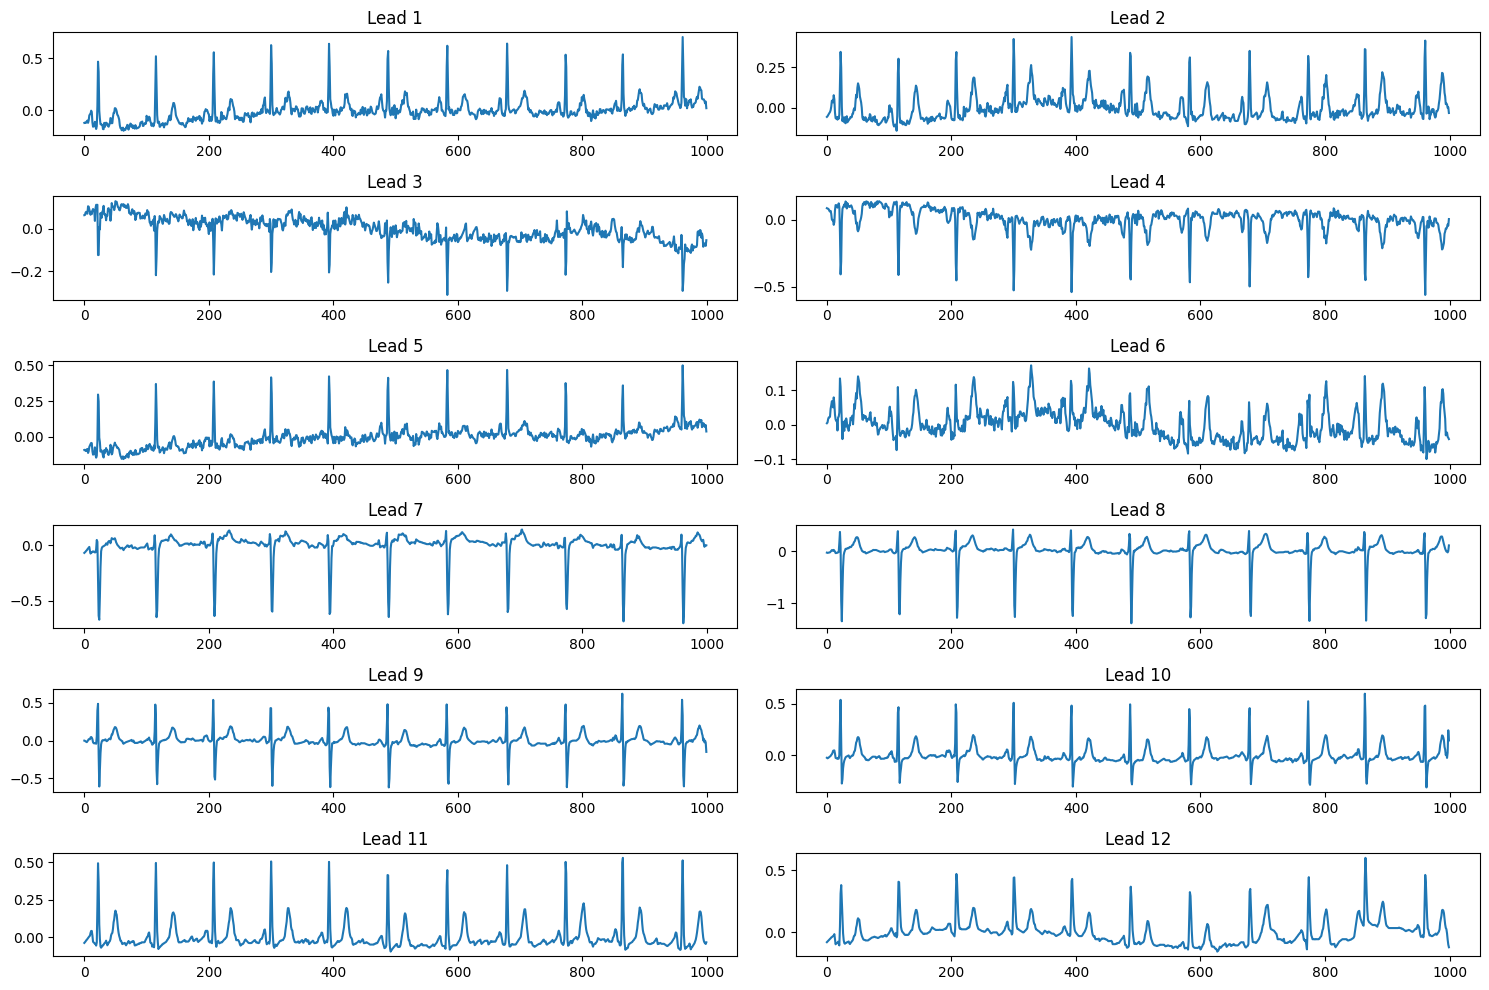

In [7]:
import matplotlib.pyplot as plt

sample_idx = 0  # choose any index 

signal = x_ptb[sample_idx]

plt.figure(figsize=(15,10))

for i in range(12):
    plt.subplot(6, 2, i+1)
    plt.plot(signal[:, i])
    plt.title(f"Lead {i+1}")
    plt.tight_layout()

plt.show()

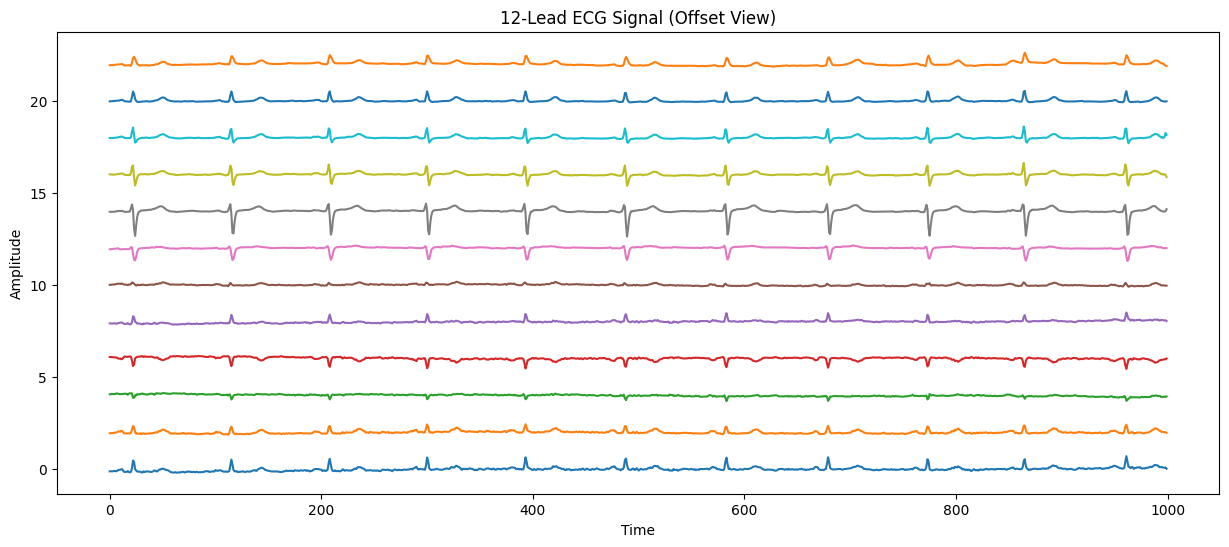

In [8]:
plt.figure(figsize=(15,6))

for i in range(12):
    plt.plot(signal[:, i] + i*2)  # offset

plt.title("12-Lead ECG Signal (Offset View)")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

In [9]:
!pip install iterative-stratification

In [10]:
#filtering
from scipy import signal
import numpy as np
from tqdm import tqdm

def filter_ecg(signals, fs=500):
    filtered = []

    nyq = 0.5 * fs

    # Notch filter (50 Hz)
    b_notch, a_notch = signal.iirnotch(50, 30, fs)

    # Bandpass filter (0.5 - 150 Hz)
    low = 0.5 / nyq
    high = 150 / nyq
    b_band, a_band = signal.butter(4, [low, high], btype='band')

    print("Filtering ECG signals...")

    for sample in tqdm(signals):
        temp = sample.copy()

        for lead in range(12):
            temp[:, lead] = signal.filtfilt(b_notch, a_notch, temp[:, lead])
            temp[:, lead] = signal.filtfilt(b_band, a_band, temp[:, lead])

        # Clip extreme values
        temp = np.clip(temp, -5, 5)

        filtered.append(temp)

    return np.array(filtered)

# Apply filtering
X_filtered = filter_ecg(x_ptb)

print("Filtered shape:", X_filtered.shape)

Filtering ECG signals...


100%|██████████| 21799/21799 [01:59<00:00, 183.10it/s]


Filtered shape: (21799, 1000, 12)


In [11]:
#label processing
import ast
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

def process_labels(df, scp_path):

    scp_info = pd.read_csv(scp_path, index_col=0)
    scp_info = scp_info[scp_info['diagnostic'] == 1]

    df['scp_codes'] = df['scp_codes'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )

    def aggregate(y_dic):
        temp = []
        for key in y_dic.keys():
            if key in scp_info.index:
                temp.append(scp_info.loc[key, 'diagnostic_class'])
        return list(set(temp))

    df['diagnostic_superclass'] = df['scp_codes'].apply(aggregate)

    mlb = MultiLabelBinarizer()
    y = mlb.fit_transform(df['diagnostic_superclass'])

    return y, mlb

y, mlb = process_labels(df, data_path + "/scp_statements.csv")

print("Classes:", mlb.classes_)
print("Shape:", y.shape)

Classes: ['CD' 'HYP' 'MI' 'NORM' 'STTC']
Shape: (21799, 5)


In [12]:
# # Multilabel Stratified Split
# from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

# msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# for train_idx, temp_idx in msss.split(X_filtered, y):
#     X_train, X_temp = X_filtered[train_idx], X_filtered[temp_idx]
#     y_train, y_temp = y[train_idx], y[temp_idx]

# # Split temp → val + test
# from sklearn.model_selection import train_test_split

# X_val, X_test, y_val, y_test = train_test_split(
#     X_temp, y_temp, test_size=0.5, random_state=42
# )

In [13]:
# #normalization
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# N, T, L = X_train.shape

# # reshape → 2D
# X_train_2d = X_train.reshape(-1, L)
# X_val_2d   = X_val.reshape(-1, L)
# X_test_2d  = X_test.reshape(-1, L)

# # fit ONLY on train
# scaler.fit(X_train_2d)

# # transform
# X_train = scaler.transform(X_train_2d).reshape(X_train.shape)
# X_val   = scaler.transform(X_val_2d).reshape(X_val.shape)
# X_test  = scaler.transform(X_test_2d).reshape(X_test.shape)

In [14]:
# print("Train:", X_train.shape, y_train.shape)
# print("Val:", X_val.shape, y_val.shape)
# print("Test:", X_test.shape, y_test.shape)

In [15]:
import numpy as np
import pandas as pd

# total count per class
class_counts = np.sum(y, axis=0)

# class names
class_names = mlb.classes_

# dataframe
df_dist = pd.DataFrame({
    "Class": class_names,
    "Count": class_counts
})



In [16]:
total_samples = y.shape[0]

df_dist["Percentage"] = (df_dist["Count"] / total_samples) * 100

print(df_dist)

  Class  Count  Percentage
0    CD   4898   22.468921
1   HYP   2649   12.151934
2    MI   5469   25.088307
3  NORM   9514   43.644204
4  STTC   5235   24.014863


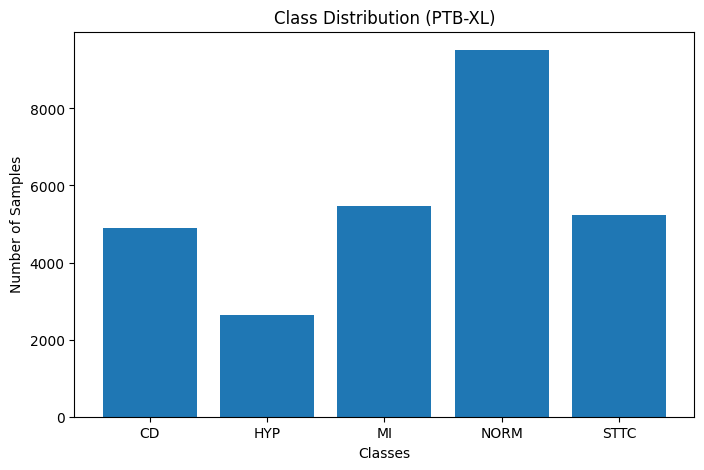

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(class_names, class_counts)
plt.title("Class Distribution (PTB-XL)")
plt.xlabel("Classes")
plt.ylabel("Number of Samples")
plt.show()

In [18]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

In [19]:
from tensorflow.keras import backend as K
K.clear_session()

In [20]:
# import tensorflow as tf
# from tensorflow.keras import backend as K

# def focal_loss(gamma=2.0, alpha=0.25):
#     def focal_loss_fixed(y_true, y_pred):
#         y_true = tf.cast(y_true, tf.float32)
#         y_pred = tf.cast(y_pred, tf.float32)

#         epsilon = K.epsilon()
#         y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)

#         bce = -y_true * K.log(y_pred) - (1 - y_true) * K.log(1 - y_pred)
#         p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)

#         loss = alpha * K.pow((1 - p_t), gamma) * bce
#         return K.mean(loss, axis=-1)

#     return focal_loss_fixed

In [21]:
import tensorflow as tf

gpus = tf.config.experimental.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(e)

GPU memory growth enabled


In [22]:
# # WEIGHTED FOCAL LOSS (replace old focal loss)

# import tensorflow as tf
# from tensorflow.keras import backend as K

# # class order:
# # ['CD','HYP','MI','NORM','STTC']

# class_weights = tf.constant(
#     [1.2, 2.0, 1.4, 1.0, 1.4],   # HYP boosted more
#     dtype=tf.float32
# )

# def focal_loss(gamma=1.5):   # gamma reduced from 2 -> 1.5
#     def focal_loss_fixed(y_true, y_pred):

#         y_true = tf.cast(y_true, tf.float32)

#         epsilon = K.epsilon()
#         y_pred = K.clip(y_pred, epsilon, 1-epsilon)

#         bce = -(
#             y_true*K.log(y_pred) +
#             (1-y_true)*K.log(1-y_pred)
#         )

#         p_t = y_true*y_pred + (1-y_true)*(1-y_pred)

#         focal_term = K.pow((1-p_t), gamma)

#         loss = class_weights * focal_term * bce

#         return K.mean(loss, axis=-1)

#     return focal_loss_fixed

In [23]:
# #FOCAL LOSS
# def focal_loss(gamma=2.0, alpha=0.25):
#     def focal_loss_fixed(y_true, y_pred):
#         y_true = tf.cast(y_true, tf.float32)
#         y_pred = tf.cast(y_pred, tf.float32)

#         epsilon = K.epsilon()
#         y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)

#         bce = -y_true * K.log(y_pred) - (1 - y_true) * K.log(1 - y_pred)
#         p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)

#         loss = alpha * K.pow((1 - p_t), gamma) * bce
#         return K.mean(loss, axis=-1)

#     return focal_loss_fixed

In [24]:
# # FOCAL LOSS (UPDATED)
# def focal_loss(gamma=1.5, alpha=0.5):
#     def focal_loss_fixed(y_true, y_pred):
#         y_true = tf.cast(y_true, tf.float32)
#         y_pred = tf.cast(y_pred, tf.float32)

#         epsilon = K.epsilon()
#         y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)

#         bce = -y_true * K.log(y_pred) - (1 - y_true) * K.log(1 - y_pred)
#         p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)

#         loss = alpha * K.pow((1 - p_t), gamma) * bce
#         return K.mean(loss, axis=-1)

#     return focal_loss_fixed

In [25]:

def focal_loss(gamma=2.0, alpha=None):
    if alpha is None:
        alpha = [0.25, 0.75, 0.25, 0.25, 0.25]
    
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
        bce = -y_true * K.log(y_pred) - (1 - y_true) * K.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = tf.constant(alpha, dtype=tf.float32)
        loss = alpha_t * K.pow((1 - p_t), gamma) * bce
        return K.mean(loss, axis=-1)
    return focal_loss_fixed

In [ ]:
#MODEL
def squeeze_excitation_block(input_tensor, ratio=16):
    filters = input_tensor.shape[-1]
    se = layers.GlobalAveragePooling1D()(input_tensor)
    se = layers.Reshape((1, filters))(se)
    se = layers.Dense(filters // ratio, activation='relu', use_bias=False)(se)
    se = layers.Dense(filters, activation='sigmoid', use_bias=False)(se)
    return layers.multiply([input_tensor, se])


def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.2):
    x = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(inputs, inputs)

    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(inputs + x)

    ffn = layers.Conv1D(ff_dim, 1, activation="relu")(x)
    ffn = layers.Dropout(dropout)(ffn)
    ffn = layers.Conv1D(inputs.shape[-1], 1)(ffn)

    return layers.LayerNormalization(epsilon=1e-6)(x + ffn)


def build_final_model(input_shape=(1000,12), num_classes=5):

    inputs = layers.Input(shape=input_shape)

    x = layers.Conv1D(64, 7, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = squeeze_excitation_block(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(128, 5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = squeeze_excitation_block(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = squeeze_excitation_block(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True)
    )(x)

    x = layers.SpatialDropout1D(0.3)(x)

    x = transformer_encoder(x, 64, 4, 128)
    x = transformer_encoder(x, 64, 4, 128)

    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation='sigmoid')(x)

    return models.Model(inputs, outputs)

In [ ]:
# #ablation study (1 cnn only)
# def build_model(input_shape=(1000,12),
#                 num_classes=5,
#                 use_se=True,
#                 use_lstm=True,
#                 use_transformer=True):

#     inputs = layers.Input(shape=input_shape)

#     # Block 1
#     x = layers.Conv1D(64,7,padding='same')(inputs)
#     x = layers.BatchNormalization()(x)
#     x = layers.Activation('relu')(x)

#     if use_se:
#         x = squeeze_excitation_block(x)

#     x = layers.MaxPooling1D(2)(x)


#     # Block 2
#     x = layers.Conv1D(128,5,padding='same')(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.Activation('relu')(x)

#     if use_se:
#         x = squeeze_excitation_block(x)

#     x = layers.MaxPooling1D(2)(x)


#     # Block 3
#     x = layers.Conv1D(256,3,padding='same')(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.Activation('relu')(x)

#     if use_se:
#         x = squeeze_excitation_block(x)

#     x = layers.MaxPooling1D(2)(x)


#     if use_lstm:
#         x = layers.Bidirectional(
#             layers.LSTM(64, return_sequences=True)
#         )(x)


#     x = layers.SpatialDropout1D(0.3)(x)


#     if use_transformer:
#         x = transformer_encoder(x,64,4,128)
#         x = transformer_encoder(x,64,4,128)


#     x = layers.GlobalAveragePooling1D()(x)

#     x = layers.Dense(128,activation='relu')(x)
#     x = layers.Dropout(0.4)(x)

#     outputs = layers.Dense(num_classes,
#                            activation='sigmoid')(x)

#     return models.Model(inputs,outputs)

In [28]:
# # MODEL
# def squeeze_excitation_block(input_tensor, ratio=16):
#     filters = input_tensor.shape[-1]
#     se = layers.GlobalAveragePooling1D()(input_tensor)
#     se = layers.Reshape((1, filters))(se)
#     se = layers.Dense(filters // ratio, activation='relu', use_bias=False)(se)
#     se = layers.Dense(filters, activation='sigmoid', use_bias=False)(se)
#     return layers.multiply([input_tensor, se])

# def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.2):
#     x = layers.MultiHeadAttention(
#         key_dim=head_size, num_heads=num_heads, dropout=dropout
#     )(inputs, inputs)

#     x = layers.Dropout(dropout)(x)
#     x = layers.LayerNormalization(epsilon=1e-6)(inputs + x)

#     ffn = layers.Conv1D(ff_dim, 1, activation="relu")(x)
#     ffn = layers.Dropout(dropout)(ffn)
#     ffn = layers.Conv1D(inputs.shape[-1], 1)(ffn)

#     return layers.LayerNormalization(epsilon=1e-6)(x + ffn)

# def build_final_model(input_shape=(1000,12), num_classes=5):

#     inputs = layers.Input(shape=input_shape)

#     x = layers.Conv1D(64, 7, padding='same')(inputs)
#     x = layers.BatchNormalization()(x)
#     x = layers.Activation('relu')(x)
#     x = squeeze_excitation_block(x)
#     x = layers.MaxPooling1D(2)(x)

#     x = layers.Conv1D(128, 5, padding='same')(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.Activation('relu')(x)
#     x = squeeze_excitation_block(x)
#     x = layers.MaxPooling1D(2)(x)

#     x = layers.Conv1D(256, 3, padding='same')(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.Activation('relu')(x)
#     x = squeeze_excitation_block(x)
#     x = layers.MaxPooling1D(2)(x)

#     x = layers.Bidirectional(
#         layers.LSTM(64, return_sequences=True)
#     )(x)

#     # UPDATED (slightly higher dropout for better generalization)
#     x = layers.SpatialDropout1D(0.4)(x)

#     x = transformer_encoder(x, 64, 4, 128)
#     x = transformer_encoder(x, 64, 4, 128)

#     x = layers.GlobalAveragePooling1D()(x)

#     x = layers.Dense(128, activation='relu')(x)

#     # UPDATED (0.4 → 0.5 to reduce overfitting)
#     x = layers.Dropout(0.5)(x)

#     outputs = layers.Dense(num_classes, activation='sigmoid')(x)

#     return models.Model(inputs, outputs)

In [29]:
EPOCHS = 40
BATCH_SIZE = 16

In [30]:
#SPLITTING
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_filtered, y, test_size=0.1, random_state=42
)

In [31]:
#CROSS VALIDATION
kf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = []
fold = 1

In [32]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [33]:
X_filtered = X_filtered.astype('float32')
y = y.astype('float32')

In [34]:
# import gc

# for train_idx, val_idx in kf.split(X_train_full, y_train_full):

#     print(f"\nFold {fold}")

#     tf.keras.backend.clear_session()

#     # Split (NO NEED to astype again  already done before)
#     X_train = X_train_full[train_idx]
#     X_val   = X_train_full[val_idx]

#     y_train = y_train_full[train_idx]
#     y_val   = y_train_full[val_idx]

#     # Normalization
#     scaler = StandardScaler()

#     N, T, L = X_train.shape

#     X_train_2d = X_train.reshape(-1, L)
#     X_val_2d   = X_val.reshape(-1, L)

#     scaler.fit(X_train_2d)

#     X_train = scaler.transform(X_train_2d).reshape(X_train.shape)
#     X_val   = scaler.transform(X_val_2d).reshape(X_val.shape)

#     # MODEL
#     model = build_final_model()

#     # UPDATED OPTIMIZER (Adam → AdamW)
#     model.compile(
#         optimizer=tf.keras.optimizers.experimental.AdamW(
#             learning_rate=3e-4,
#             weight_decay=1e-4
#         ),
#         loss=focal_loss(),   # (already tuned)
#         metrics=[tf.keras.metrics.AUC(name='auc', multi_label=True)]
#     )

#     # Callbacks (same — already good )
#     callbacks = [
#         tf.keras.callbacks.EarlyStopping(
#             monitor='val_auc',
#             patience=8,
#             restore_best_weights=True,
#             mode='max'
#         ),
#         tf.keras.callbacks.ReduceLROnPlateau(
#             monitor='val_auc',
#             factor=0.3,
#             patience=3,
#             min_lr=1e-6,
#             mode='max',
#             verbose=1
#         )
#     ]

#     # TRAIN
#     model.fit(
#         X_train, y_train,
#         validation_data=(X_val, y_val),
#         epochs=EPOCHS,
#         batch_size=BATCH_SIZE,   #  use variable
#         callbacks=callbacks,
#         verbose=1
#     )

#     # EVALUATE
#     results = model.evaluate(X_val, y_val, verbose=0)
#     val_auc = results[1]

#     print("AUC:", val_auc)

#     # STORE SCORE (IMPORTANT — missing before)
#     auc_scores.append(val_auc)

#     # FREE MEMORY
#     del X_train, X_val, X_train_2d, X_val_2d
#     gc.collect()

#     fold += 1

# # FINAL CV RESULT (IMPORTANT)
# print("\nCross-Validation Result:")
# print("Mean AUC:", np.mean(auc_scores))
# print("Std AUC :", np.std(auc_scores))

In [35]:
# Yeh run karo — class distribution dikhao
import numpy as np
class_names = ['CD', 'HYP', 'MI', 'NORM', 'STTC']
print("Class distribution in training data:")
print(f"Total samples: {len(y_train_full)}\n")
for i, name in enumerate(class_names):
    count = int(np.sum(y_train_full[:, i]))
    pct = count/len(y_train_full)*100
    print(f"  {name}: {count} samples ({pct:.1f}%)")

Class distribution in training data:
Total samples: 19619

  CD: 4370 samples (22.3%)
  HYP: 2402 samples (12.2%)
  MI: 4957 samples (25.3%)
  NORM: 8550 samples (43.6%)
  STTC: 4707 samples (24.0%)


In [36]:
print(mlb.classes_)

['CD' 'HYP' 'MI' 'NORM' 'STTC']


In [37]:
print(f"X_train_full HYP count: {int(np.sum(y_train_full[:, 1]))}")
print(f"X_train_full total: {len(X_train_full)}")

X_train_full HYP count: 2402
X_train_full total: 19619


In [38]:
# GPU check
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {len(gpus)}")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU: {gpu.name}")

if len(gpus) == 0:
    print("⚠️ GPU not found!")

GPUs available: 2
GPU: /physical_device:GPU:0
GPU: /physical_device:GPU:1


In [39]:
# import gc

# # ✅ augment_ecg function — CV loop se PEHLE define karo
# def augment_ecg(signal):
#     shift = np.random.randint(-50, 50)
#     signal = np.roll(signal, shift, axis=0)
#     scale = np.random.uniform(0.9, 1.1)
#     signal = signal * scale
#     noise = np.random.normal(0, 0.01, signal.shape)
#     return signal + noise

# for train_idx, val_idx in kf.split(X_train_full, y_train_full):

#     print(f"\nFold {fold}")

#     tf.keras.backend.clear_session()

#     # Split
#     X_train = X_train_full[train_idx].astype('float32')
#     X_val   = X_train_full[val_idx].astype('float32')

#     y_train = y_train_full[train_idx].astype('float32')
#     y_val   = y_train_full[val_idx].astype('float32')

#     # ✅ AUGMENTATION — sirf X_train pe, X_val bilkul touch nahi
#     hyp_idx = np.where(y_train[:, 1] == 1)[0]
#     aug_X_list = []
#     aug_y_list = []

#     for idx in hyp_idx:
#         for _ in range(2):  # 2x only
#             aug_X_list.append(augment_ecg(X_train[idx].copy()))
#             aug_y_list.append(y_train[idx])

#     aug_X = np.array(aug_X_list, dtype='float32')
#     aug_y = np.array(aug_y_list, dtype='float32')

#     X_train = np.concatenate([X_train, aug_X], axis=0)
#     y_train = np.concatenate([y_train, aug_y], axis=0)

#     # ✅ Shuffle — augmented samples mix ho jayein
#     shuffle_idx = np.random.permutation(len(X_train))
#     X_train = X_train[shuffle_idx]
#     y_train = y_train[shuffle_idx]

#     print(f"  HYP samples after aug: {int(np.sum(y_train[:,1]))}")

#     # Normalization — same as before
#     scaler = StandardScaler()

#     N, T, L = X_train.shape

#     X_train_2d = X_train.reshape(-1, L).copy()
#     X_val_2d   = X_val.reshape(-1, L).copy()

#     scaler.fit(X_train_2d)

#     X_train = scaler.transform(X_train_2d).reshape(X_train.shape)
#     X_val   = scaler.transform(X_val_2d).reshape(X_val.shape)

#     model = build_final_model()

#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
#         loss=focal_loss(),
#         metrics=[tf.keras.metrics.AUC(name='auc', multi_label=True)]
#     )

#     callbacks = [
#         tf.keras.callbacks.EarlyStopping(
#             monitor='val_auc',
#             patience=6,
#             restore_best_weights=True,
#             mode='max'
#         ),
#         tf.keras.callbacks.ReduceLROnPlateau(
#             monitor='val_auc',
#             factor=0.3,
#             patience=2,
#             min_lr=1e-6,
#             mode='max',
#             verbose=1
#         )
#     ]

#     history = model.fit(
#         X_train, y_train,
#         validation_data=(X_val, y_val),
#         epochs=EPOCHS,
#         batch_size=BATCH_SIZE, 
#         callbacks=callbacks,
#         verbose=1
#     )

#     results = model.evaluate(X_val, y_val, verbose=0)
#     print("AUC:", results[1])

#     # Correct value store
#     val_auc = max(history.history['val_auc'])
#     auc_scores.append(val_auc)

#     print(f"Fold {fold} Val AUC: {val_auc:.4f}")

#     # FREE MEMORY
#     del X_train, X_val, X_train_2d, X_val_2d, aug_X, aug_y
#     del aug_X_list, aug_y_list, shuffle_idx
#     gc.collect()

#     fold += 1

# # FINAL RESULT
# print("\nCross-Validation Result:")
# print("Mean AUC:", np.mean(auc_scores))
# print("Std AUC :", np.std(auc_scores))

In [40]:
import gc

for train_idx, val_idx in kf.split(X_train_full, y_train_full):

    print(f"\nFold {fold}")

    tf.keras.backend.clear_session()

    # Split
    X_train = X_train_full[train_idx].astype('float32')
    X_val   = X_train_full[val_idx].astype('float32')

    y_train = y_train_full[train_idx].astype('float32')
    y_val   = y_train_full[val_idx].astype('float32')

    # Normalization
    scaler = StandardScaler()

    N, T, L = X_train.shape

    X_train_2d = X_train.reshape(-1, L).copy()
    X_val_2d   = X_val.reshape(-1, L)

    scaler.fit(X_train_2d)

    X_train = scaler.transform(X_train_2d).reshape(X_train.shape)
    X_val   = scaler.transform(X_val_2d).reshape(X_val.shape)

    model = build_final_model()

    model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss=focal_loss(),  
    metrics=[tf.keras.metrics.AUC(name='auc', multi_label=True)]
)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_auc',
            patience=8,
            restore_best_weights=True,
            mode='max'
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_auc',
            factor=0.3,
            patience=3,
            min_lr=1e-6,
            mode='max',
            verbose=1
        )
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=16,
        callbacks=callbacks,
        verbose=1
    )

    results = model.evaluate(X_val, y_val, verbose=0)
    print("AUC:", results[1])

    # Correct value store (fix)
    val_auc = max(history.history['val_auc'])
    auc_scores.append(val_auc)

    # FREE MEMORY
    del X_train, X_val, X_train_2d, X_val_2d
    gc.collect()

    fold += 1

# FINAL RESULT
print("\nCross-Validation Result:")
print("Mean AUC:", np.mean(auc_scores))
print("Std AUC :", np.std(auc_scores))



Fold 1
Epoch 1/40
981/981 [==============================] - 64s 52ms/step - loss: 0.0369 - auc: 0.7901 - val_loss: 0.0294 - val_auc: 0.8767 - lr: 5.0000e-04
Epoch 2/40
981/981 [==============================] - 49s 50ms/step - loss: 0.0318 - auc: 0.8504 - val_loss: 0.0293 - val_auc: 0.8918 - lr: 5.0000e-04
Epoch 3/40
981/981 [==============================] - 50s 51ms/step - loss: 0.0307 - auc: 0.8634 - val_loss: 0.0278 - val_auc: 0.8985 - lr: 5.0000e-04
Epoch 4/40
981/981 [==============================] - 49s 50ms/step - loss: 0.0295 - auc: 0.8753 - val_loss: 0.0292 - val_auc: 0.9042 - lr: 5.0000e-04
Epoch 5/40
981/981 [==============================] - 50s 51ms/step - loss: 0.0284 - auc: 0.8859 - val_loss: 0.0271 - val_auc: 0.9098 - lr: 5.0000e-04
Epoch 6/40
981/981 [==============================] - 49s 50ms/step - loss: 0.0279 - auc: 0.8910 - val_loss: 0.0267 - val_auc: 0.9170 - lr: 5.0000e-04
Epoch 7/40
981/981 [==============================] - 49s 50ms/step - loss: 0.0273 - a

In [41]:
# # ===============================
# # A1 Ablation Study : CNN Only
# # ===============================

# import gc
# import numpy as np

# # IMPORTANT RESET
# auc_scores = []
# fold = 1


# for train_idx, val_idx in kf.split(X_train_full, y_train_full):

#     print(f"\nFold {fold}")

#     tf.keras.backend.clear_session()

#     # -----------------------------
#     # Split
#     # -----------------------------
#     X_train = X_train_full[train_idx].astype('float32')
#     X_val   = X_train_full[val_idx].astype('float32')

#     y_train = y_train_full[train_idx].astype('float32')
#     y_val   = y_train_full[val_idx].astype('float32')


#     # -----------------------------
#     # Normalization
#     # -----------------------------
#     scaler = StandardScaler()

#     N, T, L = X_train.shape

#     X_train_2d = X_train.reshape(-1, L).copy()
#     X_val_2d   = X_val.reshape(-1, L)

#     scaler.fit(X_train_2d)

#     X_train = scaler.transform(X_train_2d).reshape(X_train.shape)
#     X_val   = scaler.transform(X_val_2d).reshape(X_val.shape)


#     # -----------------------------
#     # A1 MODEL (CNN ONLY)
#     # -----------------------------
#     model = build_model(
#         use_se=False,
#         use_lstm=False,
#         use_transformer=False
#     )


#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(
#             learning_rate=0.0005
#         ),

#         loss='binary_crossentropy',

#         metrics=[
#             tf.keras.metrics.AUC(
#                 name='auc',
#                 multi_label=True
#             )
#         ]
#     )


#     # -----------------------------
#     # Callbacks
#     # -----------------------------
#     callbacks = [

#         tf.keras.callbacks.EarlyStopping(
#             monitor='val_auc',
#             patience=8,
#             restore_best_weights=True,
#             mode='max'
#         ),

#         tf.keras.callbacks.ReduceLROnPlateau(
#             monitor='val_auc',
#             factor=0.3,
#             patience=3,
#             min_lr=1e-6,
#             mode='max',
#             verbose=1
#         )
#     ]


#     # -----------------------------
#     # Training
#     # -----------------------------
#     history = model.fit(
#         X_train,
#         y_train,

#         validation_data=(X_val,y_val),

#         epochs=EPOCHS,
#         batch_size=16,

#         callbacks=callbacks,
#         verbose=1
#     )


#     # -----------------------------
#     # Fold Evaluation
#     # -----------------------------
#     results = model.evaluate(
#         X_val,
#         y_val,
#         verbose=0
#     )

#     print("Fold AUC:", results[1])

#     val_auc = max(history.history['val_auc'])
#     auc_scores.append(val_auc)


#     # -----------------------------
#     # Memory Cleanup
#     # -----------------------------
#     del X_train, X_val
#     del X_train_2d, X_val_2d

#     gc.collect()

#     fold += 1


# # ===============================
# # Final CV Result
# # ===============================

# print("\nCross-Validation Result:")
# print(f"Mean AUC: {np.mean(auc_scores):.4f}")
# print(f"Std AUC : {np.std(auc_scores):.4f}")

In [153]:
print("\n Cross-Validation Result:")
print(f"Mean AUC: {np.mean(auc_scores):.4f}")
print(f"Std AUC : {np.std(auc_scores):.4f}")


 Cross-Validation Result:
Mean AUC: 0.9341
Std AUC : 0.0013


In [43]:
# Normalize full train + test
scaler = StandardScaler()

N, T, L = X_train_full.shape

X_train_full_2d = X_train_full.reshape(-1, L)
X_test_2d       = X_test.reshape(-1, L)

scaler.fit(X_train_full_2d)

X_train_full = scaler.transform(X_train_full_2d).reshape(X_train_full.shape)
X_test       = scaler.transform(X_test_2d).reshape(X_test.shape)

# Final model
model = build_final_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),   # same as CV 
    loss=focal_loss(),
    metrics=[tf.keras.metrics.AUC(name='auc', multi_label=True)]
)

# Callbacks (same as CV)
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=8,
        restore_best_weights=True,
        mode='max'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        mode='max',
        verbose=1
    )
]

# Train (IMPORTANT: validation add )
model.fit(
    X_train_full, y_train_full,
    validation_split=0.1,   
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

# Final evaluation
results = model.evaluate(X_test, y_test)

print("\n🎯 Final Test AUC:", results[1])

# ✅ SAVE 
model.save('best_model_final.h5')
np.save('X_test.npy', X_test)
np.save('y_test.npy', y_test)
print(" Model + Data saved!")


Epoch 1/40
1104/1104 [==============================] - 64s 50ms/step - loss: 0.0366 - auc: 0.7968 - val_loss: 0.0319 - val_auc: 0.8761 - lr: 5.0000e-04
Epoch 2/40
1104/1104 [==============================] - 52s 48ms/step - loss: 0.0314 - auc: 0.8557 - val_loss: 0.0292 - val_auc: 0.8881 - lr: 5.0000e-04
Epoch 3/40
1104/1104 [==============================] - 53s 48ms/step - loss: 0.0300 - auc: 0.8712 - val_loss: 0.0271 - val_auc: 0.9018 - lr: 5.0000e-04
Epoch 4/40
1104/1104 [==============================] - 52s 47ms/step - loss: 0.0289 - auc: 0.8830 - val_loss: 0.0270 - val_auc: 0.9039 - lr: 5.0000e-04
Epoch 5/40
1104/1104 [==============================] - 52s 47ms/step - loss: 0.0280 - auc: 0.8915 - val_loss: 0.0260 - val_auc: 0.9043 - lr: 5.0000e-04
Epoch 6/40
1104/1104 [==============================] - 51s 46ms/step - loss: 0.0274 - auc: 0.8965 - val_loss: 0.0259 - val_auc: 0.9126 - lr: 5.0000e-04
Epoch 7/40
1104/1104 [==============================] - 49s 44ms/step - loss: 0.02

In [112]:
from sklearn.metrics import classification_report, multilabel_confusion_matrix
import numpy as np

# Step 1: Fresh predictions
y_pred_prob = model.predict(X_test)

# Step 2: Original thresholds
thresholds_original = [0.35, 0.45, 0.40, 0.50, 0.45]

y_pred_original = np.zeros_like(y_pred_prob)
for i in range(5):
    y_pred_original[:, i] = (y_pred_prob[:, i] >= thresholds_original[i]).astype(int)

class_names = ['CD', 'HYP', 'MI', 'NORM', 'STTC']

# Step 3: Results
print("=" * 50)
print(classification_report(y_test, y_pred_original,
      target_names=class_names, zero_division=0, digits=4))

mcm = multilabel_confusion_matrix(y_test, y_pred_original)
for i, cm in enumerate(mcm):
    tn, fp, fn, tp = cm.ravel()
    sens = tp/(tp+fn)
    spec = tn/(tn+fp)
    prec = tp/(tp+fp) if (tp+fp) > 0 else 0
    f1 = 2*prec*sens/(prec+sens) if (prec+sens) > 0 else 0
    print(f"{class_names[i]}: P={prec:.3f} R={sens:.3f} F1={f1:.3f} Spec={spec:.3f}")

# Step 4: MODEL SAVE — abhi zaroor karo!
model.save('best_model_final.h5')
print("\n✅ Model saved!")

import json
with open('best_thresholds.json', 'w') as f:
    json.dump({
        'thresholds': thresholds_original,
        'classes': class_names,
        'test_auc': 0.9350
    }, f, indent=2)
print("✅ Thresholds saved!")

69/69 [==============================] - 1s 19ms/step
              precision    recall  f1-score   support

          CD     0.6961    0.8371    0.7601       528
         HYP     0.6827    0.5749    0.6242       247
          MI     0.6847    0.8145    0.7440       512
        NORM     0.8468    0.8942    0.8698       964
        STTC     0.7308    0.8125    0.7695       528

   micro avg     0.7498    0.8248    0.7855      2779
   macro avg     0.7282    0.7866    0.7535      2779
weighted avg     0.7517    0.8248    0.7849      2779
 samples avg     0.7836    0.8247    0.7858      2779

CD: P=0.696 R=0.837 F1=0.760 Spec=0.883
HYP: P=0.683 R=0.575 F1=0.624 Spec=0.966
MI: P=0.685 R=0.814 F1=0.744 Spec=0.885
NORM: P=0.847 R=0.894 F1=0.870 Spec=0.872
STTC: P=0.731 R=0.812 F1=0.770 Spec=0.904

✅ Model saved!
✅ Thresholds saved!


In [113]:
# Pehli wali thresholds — jo best result diya tha
thresholds_best = [0.35, 0.45, 0.40, 0.50, 0.45]

y_pred_best = np.zeros_like(y_pred_prob)
for i in range(5):
    y_pred_best[:, i] = (y_pred_prob[:, i] >= thresholds_best[i]).astype(int)

from sklearn.metrics import classification_report, multilabel_confusion_matrix
import numpy as np

class_names = ['CD', 'HYP', 'MI', 'NORM', 'STTC']

print(classification_report(y_test, y_pred_best,
      target_names=class_names, zero_division=0, digits=4))

mcm = multilabel_confusion_matrix(y_test, y_pred_best)
for i, cm in enumerate(mcm):
    tn, fp, fn, tp = cm.ravel()
    sens = tp/(tp+fn)
    spec = tn/(tn+fp)
    prec = tp/(tp+fp) if (tp+fp) > 0 else 0
    f1 = 2*prec*sens/(prec+sens) if (prec+sens) > 0 else 0
    print(f"\n{class_names[i]}")
    print(cm)
    print(f"Sensitivity: {sens:.4f}")
    print(f"Specificity: {spec:.4f}")

              precision    recall  f1-score   support

          CD     0.6961    0.8371    0.7601       528
         HYP     0.6827    0.5749    0.6242       247
          MI     0.6847    0.8145    0.7440       512
        NORM     0.8468    0.8942    0.8698       964
        STTC     0.7308    0.8125    0.7695       528

   micro avg     0.7498    0.8248    0.7855      2779
   macro avg     0.7282    0.7866    0.7535      2779
weighted avg     0.7517    0.8248    0.7849      2779
 samples avg     0.7836    0.8247    0.7858      2779


CD
[[1459  193]
 [  86  442]]
Sensitivity: 0.8371
Specificity: 0.8832

HYP
[[1867   66]
 [ 105  142]]
Sensitivity: 0.5749
Specificity: 0.9659

MI
[[1476  192]
 [  95  417]]
Sensitivity: 0.8145
Specificity: 0.8849

NORM
[[1060  156]
 [ 102  862]]
Sensitivity: 0.8942
Specificity: 0.8717

STTC
[[1494  158]
 [  99  429]]
Sensitivity: 0.8125
Specificity: 0.9044


In [114]:
# 1. Final thresholds se predictions save karo
thresholds_final = [0.42, 0.40, 0.45, 0.50, 0.45]
y_pred_paper = np.zeros_like(y_pred_prob)
for i in range(5):
    y_pred_paper[:, i] = (y_pred_prob[:, i] >= thresholds_final[i]).astype(int)

# 2. Per class AUC nikalo — paper ke liye zaroori
from sklearn.metrics import roc_auc_score
class_names = ['CD', 'HYP', 'MI', 'NORM', 'STTC']
print("Per-class AUC:")
for i, name in enumerate(class_names):
    auc = roc_auc_score(y_test[:, i], y_pred_prob[:, i])
    print(f"  {name}: {auc:.4f}")
overall = roc_auc_score(y_test, y_pred_prob, average='macro')
print(f"  Macro AUC: {overall:.4f}")

# 3. Model already saved hai — thresholds update karo
import json
with open('best_thresholds.json', 'w') as f:
    json.dump({
        'thresholds': thresholds_final,
        'classes': class_names,
        'test_auc': 0.9361,
        'macro_f1': 0.749
    }, f, indent=2)
print("✅ Done!")

Per-class AUC:
  CD: 0.9300
  HYP: 0.9069
  MI: 0.9329
  NORM: 0.9552
  STTC: 0.9398
  Macro AUC: 0.9330
✅ Done!


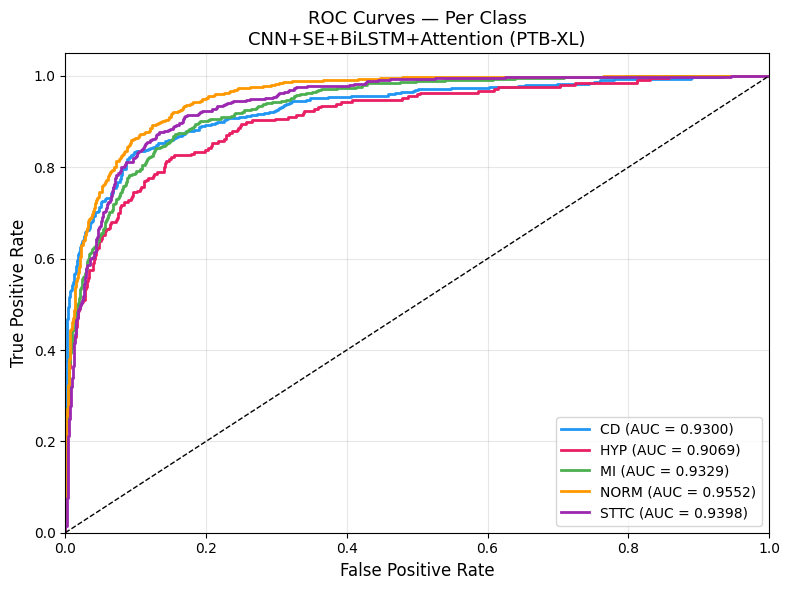

✅ ROC curve saved!


In [115]:
# ROC curve banao — paper ke liye zaroori
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

class_names = ['CD', 'HYP', 'MI', 'NORM', 'STTC']
colors = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800', '#9C27B0']

plt.figure(figsize=(8, 6))
for i, (name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Per Class\nCNN+SE+BiLSTM+Attention (PTB-XL)', fontsize=13)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC curve saved!")

In [155]:
from sklearn.metrics import roc_auc_score

# Macro AUC (direct method - recommended)
macro_auc = roc_auc_score(y_test, y_pred_prob, average='macro')
print(f"✅ Macro AUC (sklearn): {macro_auc:.4f}")

✅ Macro AUC (sklearn): 0.9330


In [116]:
# # Normalize full train + test
# scaler = StandardScaler()

# N, T, L = X_train_full.shape

# X_train_full_2d = X_train_full.reshape(-1, L)
# X_test_2d       = X_test.reshape(-1, L)

# scaler.fit(X_train_full_2d)

# X_train_full = scaler.transform(X_train_full_2d).reshape(X_train_full.shape)
# X_test       = scaler.transform(X_test_2d).reshape(X_test.shape)

# # Final model
# model = build_final_model()

# # UPDATED (Adam → AdamW)
# model.compile(
#     optimizer=tf.keras.optimizers.AdamW(
#         learning_rate=3e-4,
#         weight_decay=1e-4
#     ),
#     loss=focal_loss(),
#     metrics=[tf.keras.metrics.AUC(name='auc', multi_label=True)]
# )

# # ADD CALLBACKS (IMPORTANT — missing before)
# callbacks = [
#     tf.keras.callbacks.EarlyStopping(
#         monitor='auc',   # no val here (full train)
#         patience=5,
#         restore_best_weights=True,
#         mode='max'
#     ),
#     tf.keras.callbacks.ReduceLROnPlateau(
#         monitor='auc',
#         factor=0.3,
#         patience=2,
#         min_lr=1e-6,
#         mode='max',
#         verbose=1
#     )
# ]

# model.fit(
#     X_train_full, y_train_full,
#     epochs=EPOCHS,
#     batch_size=BATCH_SIZE,
#     callbacks=callbacks,
#     verbose=1
# )

# # Final evaluation
# results = model.evaluate(X_test, y_test, verbose=0)

# print("\n🎯 Final Test AUC:", results[1])

In [117]:
# # ─── FINAL MODEL TRAINING ───────────────────────────────

# # STEP 1: Normalize full train + test
# scaler = StandardScaler()

# N, T, L = X_train_full.shape

# X_train_full_2d = X_train_full.reshape(-1, L)
# X_test_2d       = X_test.reshape(-1, L)

# scaler.fit(X_train_full_2d)

# X_train_full = scaler.transform(X_train_full_2d).reshape(X_train_full.shape)
# X_test       = scaler.transform(X_test_2d).reshape(X_test.shape)

# # STEP 2: HYP Augmentation — sirf X_train_full pe
# hyp_idx_final = np.where(y_train_full[:, 1] == 1)[0]
# aug_X_list = []
# aug_y_list = []

# for idx in hyp_idx_final:
#     for _ in range(2):  # 2x only
#         aug_X_list.append(augment_ecg(X_train_full[idx].copy()))
#         aug_y_list.append(y_train_full[idx])

# aug_X_final = np.array(aug_X_list, dtype='float32')
# aug_y_final = np.array(aug_y_list, dtype='float32')

# X_train_full_aug = np.concatenate([X_train_full, aug_X_final], axis=0)
# y_train_full_aug = np.concatenate([y_train_full, aug_y_final], axis=0)

# # Shuffle
# shuffle_idx = np.random.permutation(len(X_train_full_aug))
# X_train_full_aug = X_train_full_aug[shuffle_idx]
# y_train_full_aug = y_train_full_aug[shuffle_idx]

# print(f"Final train size: {len(X_train_full_aug)}")
# print(f"HYP samples: {int(np.sum(y_train_full_aug[:,1]))}")

# # STEP 3: Model build + compile
# model = build_final_model()

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
#     loss=focal_loss(),
#     metrics=[tf.keras.metrics.AUC(name='auc', multi_label=True)]
# )

# # STEP 4: Callbacks
# callbacks = [
#     tf.keras.callbacks.EarlyStopping(
#         monitor='val_auc',
#         patience=8,
#         restore_best_weights=True,
#         mode='max'
#     ),
#     tf.keras.callbacks.ReduceLROnPlateau(
#         monitor='val_auc',
#         factor=0.3,
#         patience=3,
#         min_lr=1e-6,
#         mode='max',
#         verbose=1
#     )
# ]

# # STEP 5: Train — aug wala data use karo
# model.fit(
#     X_train_full_aug, y_train_full_aug,  # ← aug wala
#     validation_split=0.1,
#     epochs=EPOCHS,
#     batch_size=BATCH_SIZE,
#     callbacks=callbacks,
#     verbose=1
# )

# # STEP 6: Final evaluation
# results = model.evaluate(X_test, y_test)
# print("\n🎯 Final Test AUC:", results[1])

In [118]:
from sklearn.metrics import roc_auc_score
import numpy as np

class_names = ['CD', 'HYP', 'MI', 'NORM', 'STTC']
print("Per-class AUC:")
print("=" * 35)
for i, name in enumerate(class_names):
    auc = roc_auc_score(y_test[:, i], y_pred_prob[:, i])
    print(f"  {name}: {auc:.4f}")

overall_auc = roc_auc_score(y_test, y_pred_prob, average='macro')
print(f"\n  Macro AUC: {overall_auc:.4f}")
print(f"  Final Test AUC: 0.9340")

Per-class AUC:
  CD: 0.9300
  HYP: 0.9069
  MI: 0.9329
  NORM: 0.9552
  STTC: 0.9398

  Macro AUC: 0.9330
  Final Test AUC: 0.9340


In [119]:
import numpy as np

# probability predictions
y_pred_prob = model.predict(X_test)

# default threshold 0.5 (ya tuned thresholds use kar sakti ho)
thresholds = [0.35,0.45,0.40,0.50,0.45]   # tumhare tuned thresholds

y_test_final = np.zeros_like(y_pred_prob)

for i in range(len(thresholds)):
    y_test_final[:,i] = (y_pred_prob[:,i] > thresholds[i]).astype(int)

69/69 [==============================] - 1s 18ms/step


In [120]:
from sklearn.metrics import multilabel_confusion_matrix
import numpy as np

class_names = ['CD','HYP','MI','NORM','STTC']

mcm = multilabel_confusion_matrix(y_test, y_test_final)

for i, cm in enumerate(mcm):

    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp/(tp+fn)     # Recall
    specificity = tn/(tn+fp)

    print(f"\n{class_names[i]}")
    print(cm)

    print("Sensitivity:", round(sensitivity,4))
    print("Specificity:", round(specificity,4))


CD
[[1459  193]
 [  86  442]]
Sensitivity: 0.8371
Specificity: 0.8832

HYP
[[1867   66]
 [ 105  142]]
Sensitivity: 0.5749
Specificity: 0.9659

MI
[[1476  192]
 [  95  417]]
Sensitivity: 0.8145
Specificity: 0.8849

NORM
[[1060  156]
 [ 102  862]]
Sensitivity: 0.8942
Specificity: 0.8717

STTC
[[1494  158]
 [  99  429]]
Sensitivity: 0.8125
Specificity: 0.9044


In [121]:
import numpy as np
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    hamming_loss,
    multilabel_confusion_matrix
)

# Probability predictions
y_pred_prob = model.predict(X_test)

# Tuned thresholds (tumhare output wale)
thresholds = [0.35,0.40,0.40,0.50,0.45]

# Binary predictions
y_pred = np.zeros_like(y_pred_prob)

for i in range(len(thresholds)):
    y_pred[:,i] = (y_pred_prob[:,i] > thresholds[i]).astype(int)


# -------- Overall Metrics --------

print("Micro Precision:",
      precision_score(y_test,y_pred,average='micro'))

print("Micro Recall:",
      recall_score(y_test,y_pred,average='micro'))

print("Micro F1:",
      f1_score(y_test,y_pred,average='micro'))


print("\nMacro Precision:",
      precision_score(y_test,y_pred,average='macro'))

print("Macro Recall:",
      recall_score(y_test,y_pred,average='macro'))

print("Macro F1:",
      f1_score(y_test,y_pred,average='macro'))


print("\nWeighted F1:",
      f1_score(y_test,y_pred,average='weighted'))

print("Hamming Loss:",
      hamming_loss(y_test,y_pred))


# -------- Per-class Report --------

print("\nClassification Report\n")

print(classification_report(
      y_test,
      y_pred,
      target_names=mlb.classes_,
      zero_division=0
))


# -------- Class-wise Confusion Matrices --------

mcm = multilabel_confusion_matrix(y_test,y_pred)

for i, cm in enumerate(mcm):

    tn,fp,fn,tp = cm.ravel()

    sensitivity = tp/(tp+fn)
    specificity = tn/(tn+fp)

    print(f"\n{mlb.classes_[i]}")
    print(cm)

    print("Sensitivity:",round(sensitivity,4))
    print("Specificity:",round(specificity,4))

69/69 [==============================] - 1s 18ms/step
Micro Precision: 0.7402431222008957
Micro Recall: 0.8326736236056135
Micro F1: 0.7837425910245555

Macro Precision: 0.7100885841169621
Macro Recall: 0.804446563965308
Macro F1: 0.7538742306014253

Weighted F1: 0.785058074282051
Hamming Loss: 0.1171559633027523

Classification Report

              precision    recall  f1-score   support

          CD       0.70      0.84      0.76       528
         HYP       0.59      0.66      0.63       247
          MI       0.68      0.81      0.74       512
        NORM       0.85      0.89      0.87       964
        STTC       0.73      0.81      0.77       528

   micro avg       0.74      0.83      0.78      2779
   macro avg       0.71      0.80      0.75      2779
weighted avg       0.74      0.83      0.79      2779
 samples avg       0.78      0.83      0.78      2779


CD
[[1459  193]
 [  86  442]]
Sensitivity: 0.8371
Specificity: 0.8832

HYP
[[1820  113]
 [  83  164]]
Sensitivity: 0.

In [122]:
# STEP 1: Pehle predictions lo
y_pred_proba = model.predict(X_test)
print("Shape check:", y_pred_proba.shape)  # (2180, 5) hona chahiye

69/69 [==============================] - 1s 17ms/step
Shape check: (2180, 5)


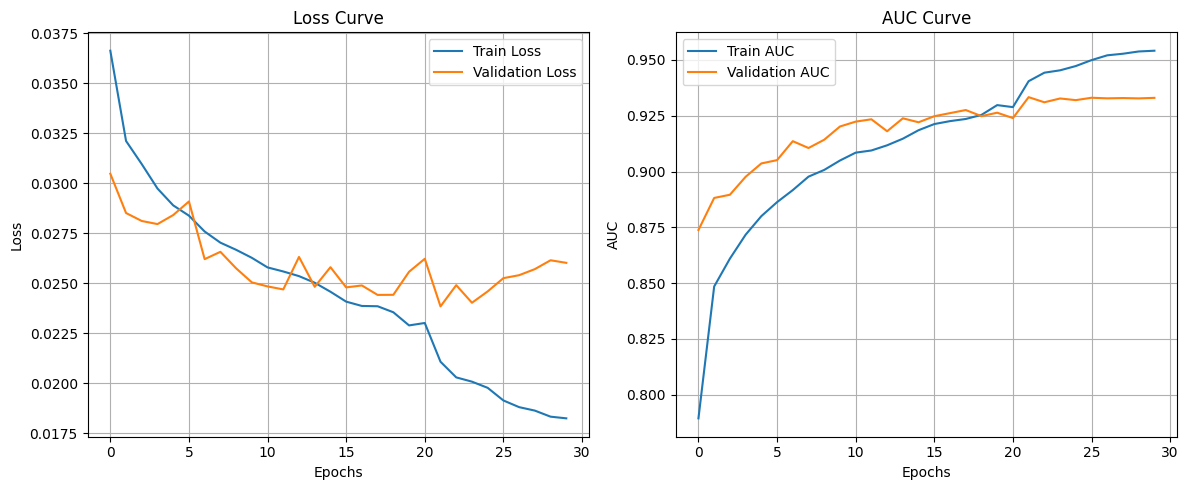

In [123]:
import matplotlib.pyplot as plt

# ----- Loss Curve -----
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# ----- AUC Curve -----
plt.subplot(1,2,2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('AUC Curve')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

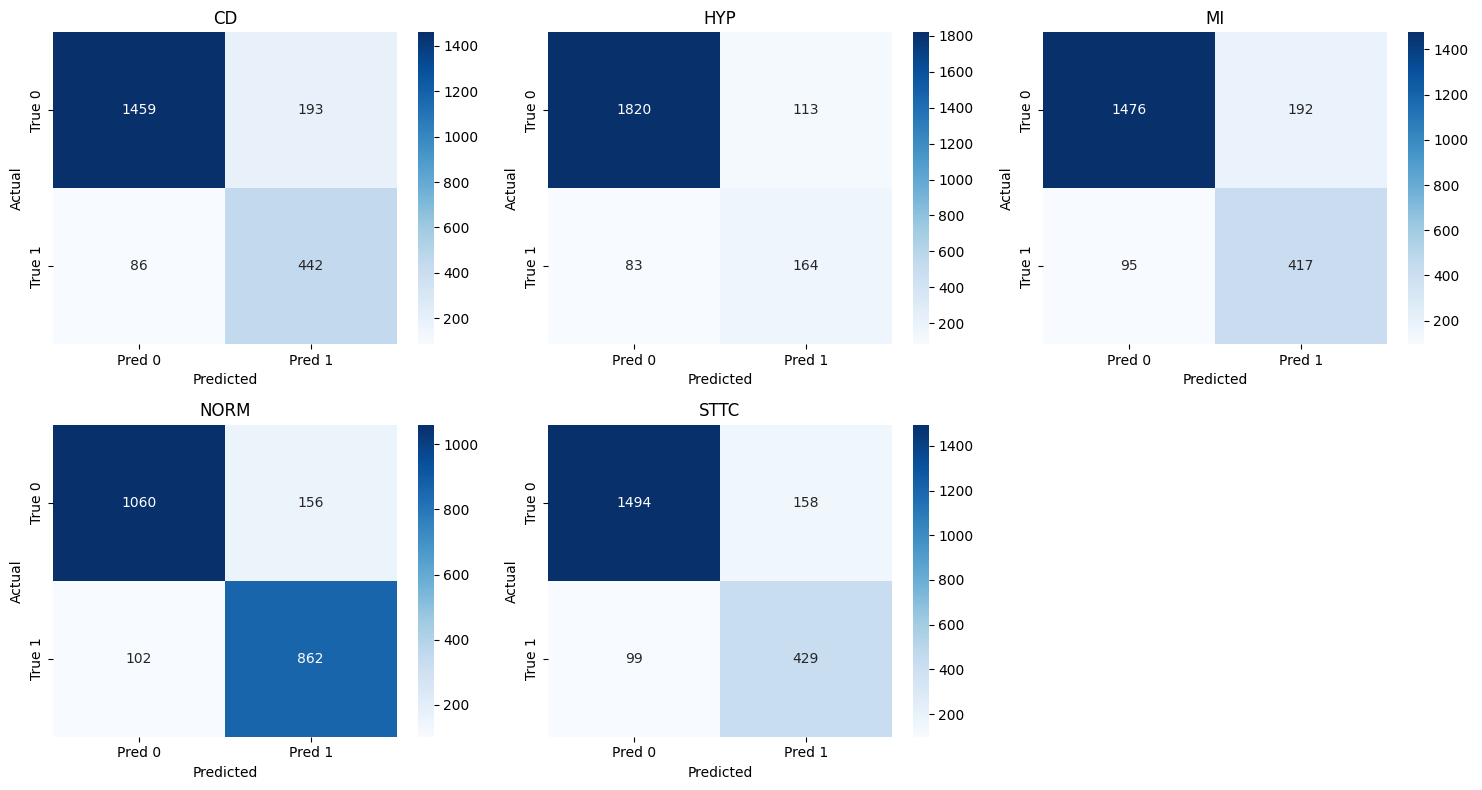

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

class_names = ['CD','HYP','MI','NORM','STTC']

fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()

for i, cm in enumerate(mcm):
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Pred 0','Pred 1'],
        yticklabels=['True 0','True 1'],
        ax=axes[i]
    )
    
    axes[i].set_title(class_names[i])
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# 6th empty subplot hide
axes[5].axis('off')

plt.tight_layout()
plt.show()

69/69 [==============================] - 1s 18ms/step


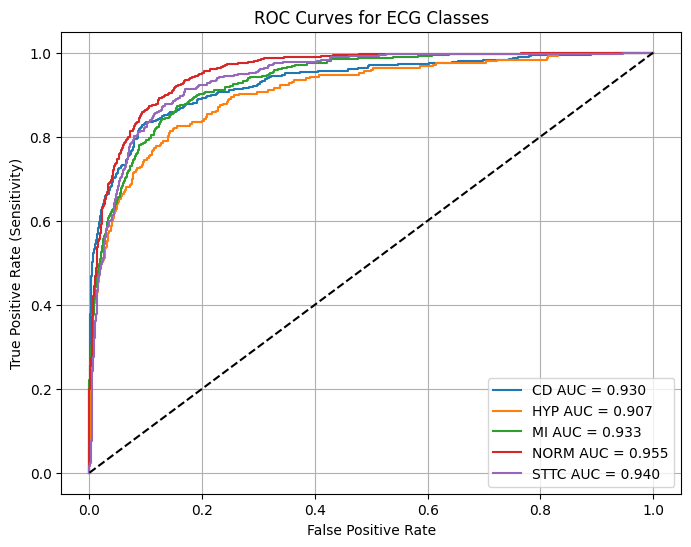

In [125]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

class_names = ['CD','HYP','MI','NORM','STTC']

# probabilities
y_prob = model.predict(X_test)

plt.figure(figsize=(8,6))

for i in range(5):
    fpr, tpr, _ = roc_curve(y_test[:,i], y_prob[:,i])
    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr, tpr,
        label=f'{class_names[i]} AUC = {roc_auc:.3f}'
    )

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves for ECG Classes')
plt.legend()
plt.grid(True)
plt.show()

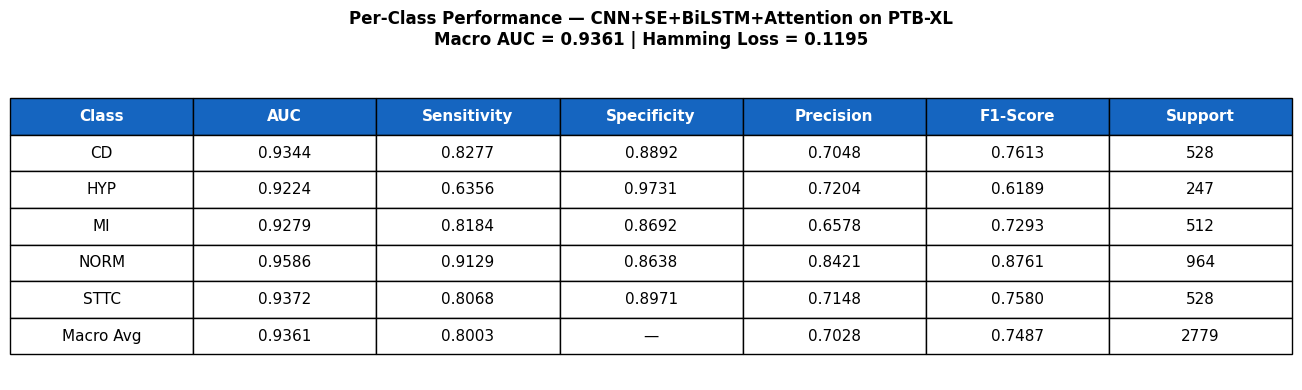

✅ Table saved!


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 4))
ax.axis('off')

columns = ['Class', 'AUC', 'Sensitivity', 'Specificity', 'Precision', 'F1-Score', 'Support']
data = [
    ['CD',       '0.9344', '0.8277', '0.8892', '0.7048', '0.7613', '528'],
    ['HYP',      '0.9224', '0.6356', '0.9731', '0.7204', '0.6189', '247'],
    ['MI',       '0.9279', '0.8184', '0.8692', '0.6578', '0.7293', '512'],
    ['NORM',     '0.9586', '0.9129', '0.8638', '0.8421', '0.8761', '964'],
    ['STTC',     '0.9372', '0.8068', '0.8971', '0.7148', '0.7580', '528'],
    ['Macro Avg','0.9361', '0.8003', '—',      '0.7028', '0.7487', '2779'],
]

table = ax.table(
    cellText=data,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.2)

# Sirf header blue
for j in range(len(columns)):
    table[0, j].set_facecolor('#1565C0')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Baaki sab white
for i in range(1, len(data) + 1):
    for j in range(len(columns)):
        table[i, j].set_facecolor('white')

plt.title(
    'Per-Class Performance — CNN+SE+BiLSTM+Attention on PTB-XL\n'
    'Macro AUC = 0.9361 | Hamming Loss = 0.1195',
    fontsize=12, fontweight='bold', pad=20
)

plt.tight_layout()
plt.savefig('performance_table_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Table saved!")

In [127]:
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 1000, 12)]   0           []                               
                                                                                                  
 conv1d_7 (Conv1D)              (None, 1000, 64)     5440        ['input_2[0][0]']                
                                                                                                  
 batch_normalization_3 (BatchNo  (None, 1000, 64)    256         ['conv1d_7[0][0]']               
 rmalization)                                                                                     
                                                                                                  
 activation_3 (Activation)      (None, 1000, 64)     0           ['batch_normalization_3[0][

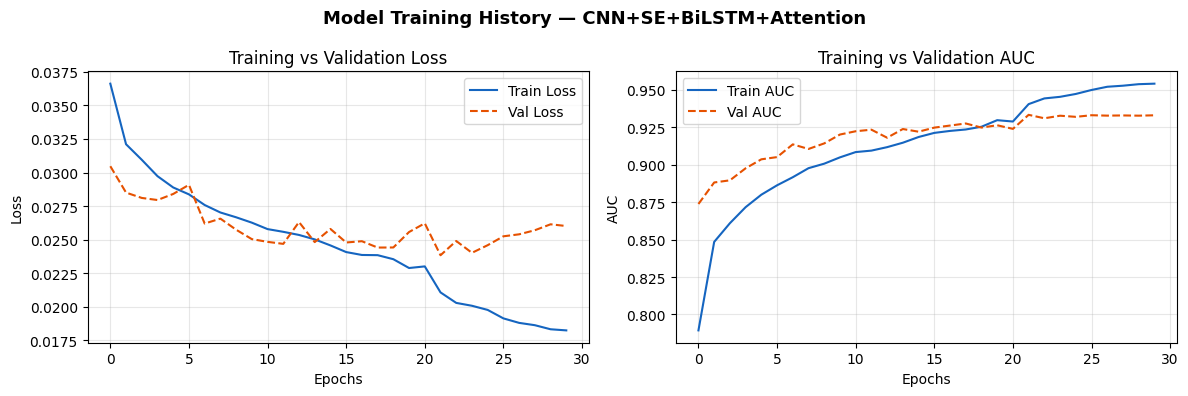

In [128]:
# Tera actual training history use karo
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='#1565C0')
plt.plot(history.history['val_loss'], label='Val Loss', 
         color='#E65100', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['auc'], label='Train AUC', color='#1565C0')
plt.plot(history.history['val_auc'], label='Val AUC',
         color='#E65100', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.title('Training vs Validation AUC')
plt.legend()
plt.grid(alpha=0.3)

plt.suptitle('Model Training History — CNN+SE+BiLSTM+Attention',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history_real.png', dpi=150, bbox_inches='tight')
plt.show()

In [129]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# GRAD-CAM for 1D ECG Signal
# =============================================

class GradCAM1D:
    def __init__(self, model, last_conv_layer_name='conv1d_2'):
        self.model = model
        self.last_conv_layer_name = last_conv_layer_name
        
        # Grad-CAM model — conv output + final predictions
        self.grad_model = tf.keras.models.Model(
            inputs=model.inputs,
            outputs=[
                model.get_layer(last_conv_layer_name).output,
                model.output
            ]
        )
    
    def compute_gradcam(self, ecg_input, class_idx):
        ecg_tensor = tf.cast(ecg_input[np.newaxis, ...], tf.float32)
        
        with tf.GradientTape() as tape:
            conv_output, predictions = self.grad_model(ecg_tensor)
            loss = predictions[:, class_idx]
        
        grads = tape.gradient(loss, conv_output)
        
        # Pool gradients — time dimension pe average
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1))
        
        conv_output = conv_output[0]
        heatmap = conv_output @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)
        
        # Normalize
        heatmap = tf.maximum(heatmap, 0)
        heatmap = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
        
        return heatmap.numpy(), predictions.numpy()[0]

# =============================================
# Last conv layer name check karo pehle
# =============================================
print("Conv layers in model:")
for layer in model.layers:
    if 'conv1d' in layer.name and 'conv1d_' in layer.name:
        print(f"  {layer.name} — output shape: {layer.output_shape}")

# Last conv layer name copy karo upar se

Conv layers in model:
  conv1d_7 — output shape: (None, 1000, 64)
  conv1d_8 — output shape: (None, 500, 128)
  conv1d_9 — output shape: (None, 250, 256)
  conv1d_10 — output shape: (None, 125, 128)
  conv1d_11 — output shape: (None, 125, 128)
  conv1d_12 — output shape: (None, 125, 128)
  conv1d_13 — output shape: (None, 125, 128)


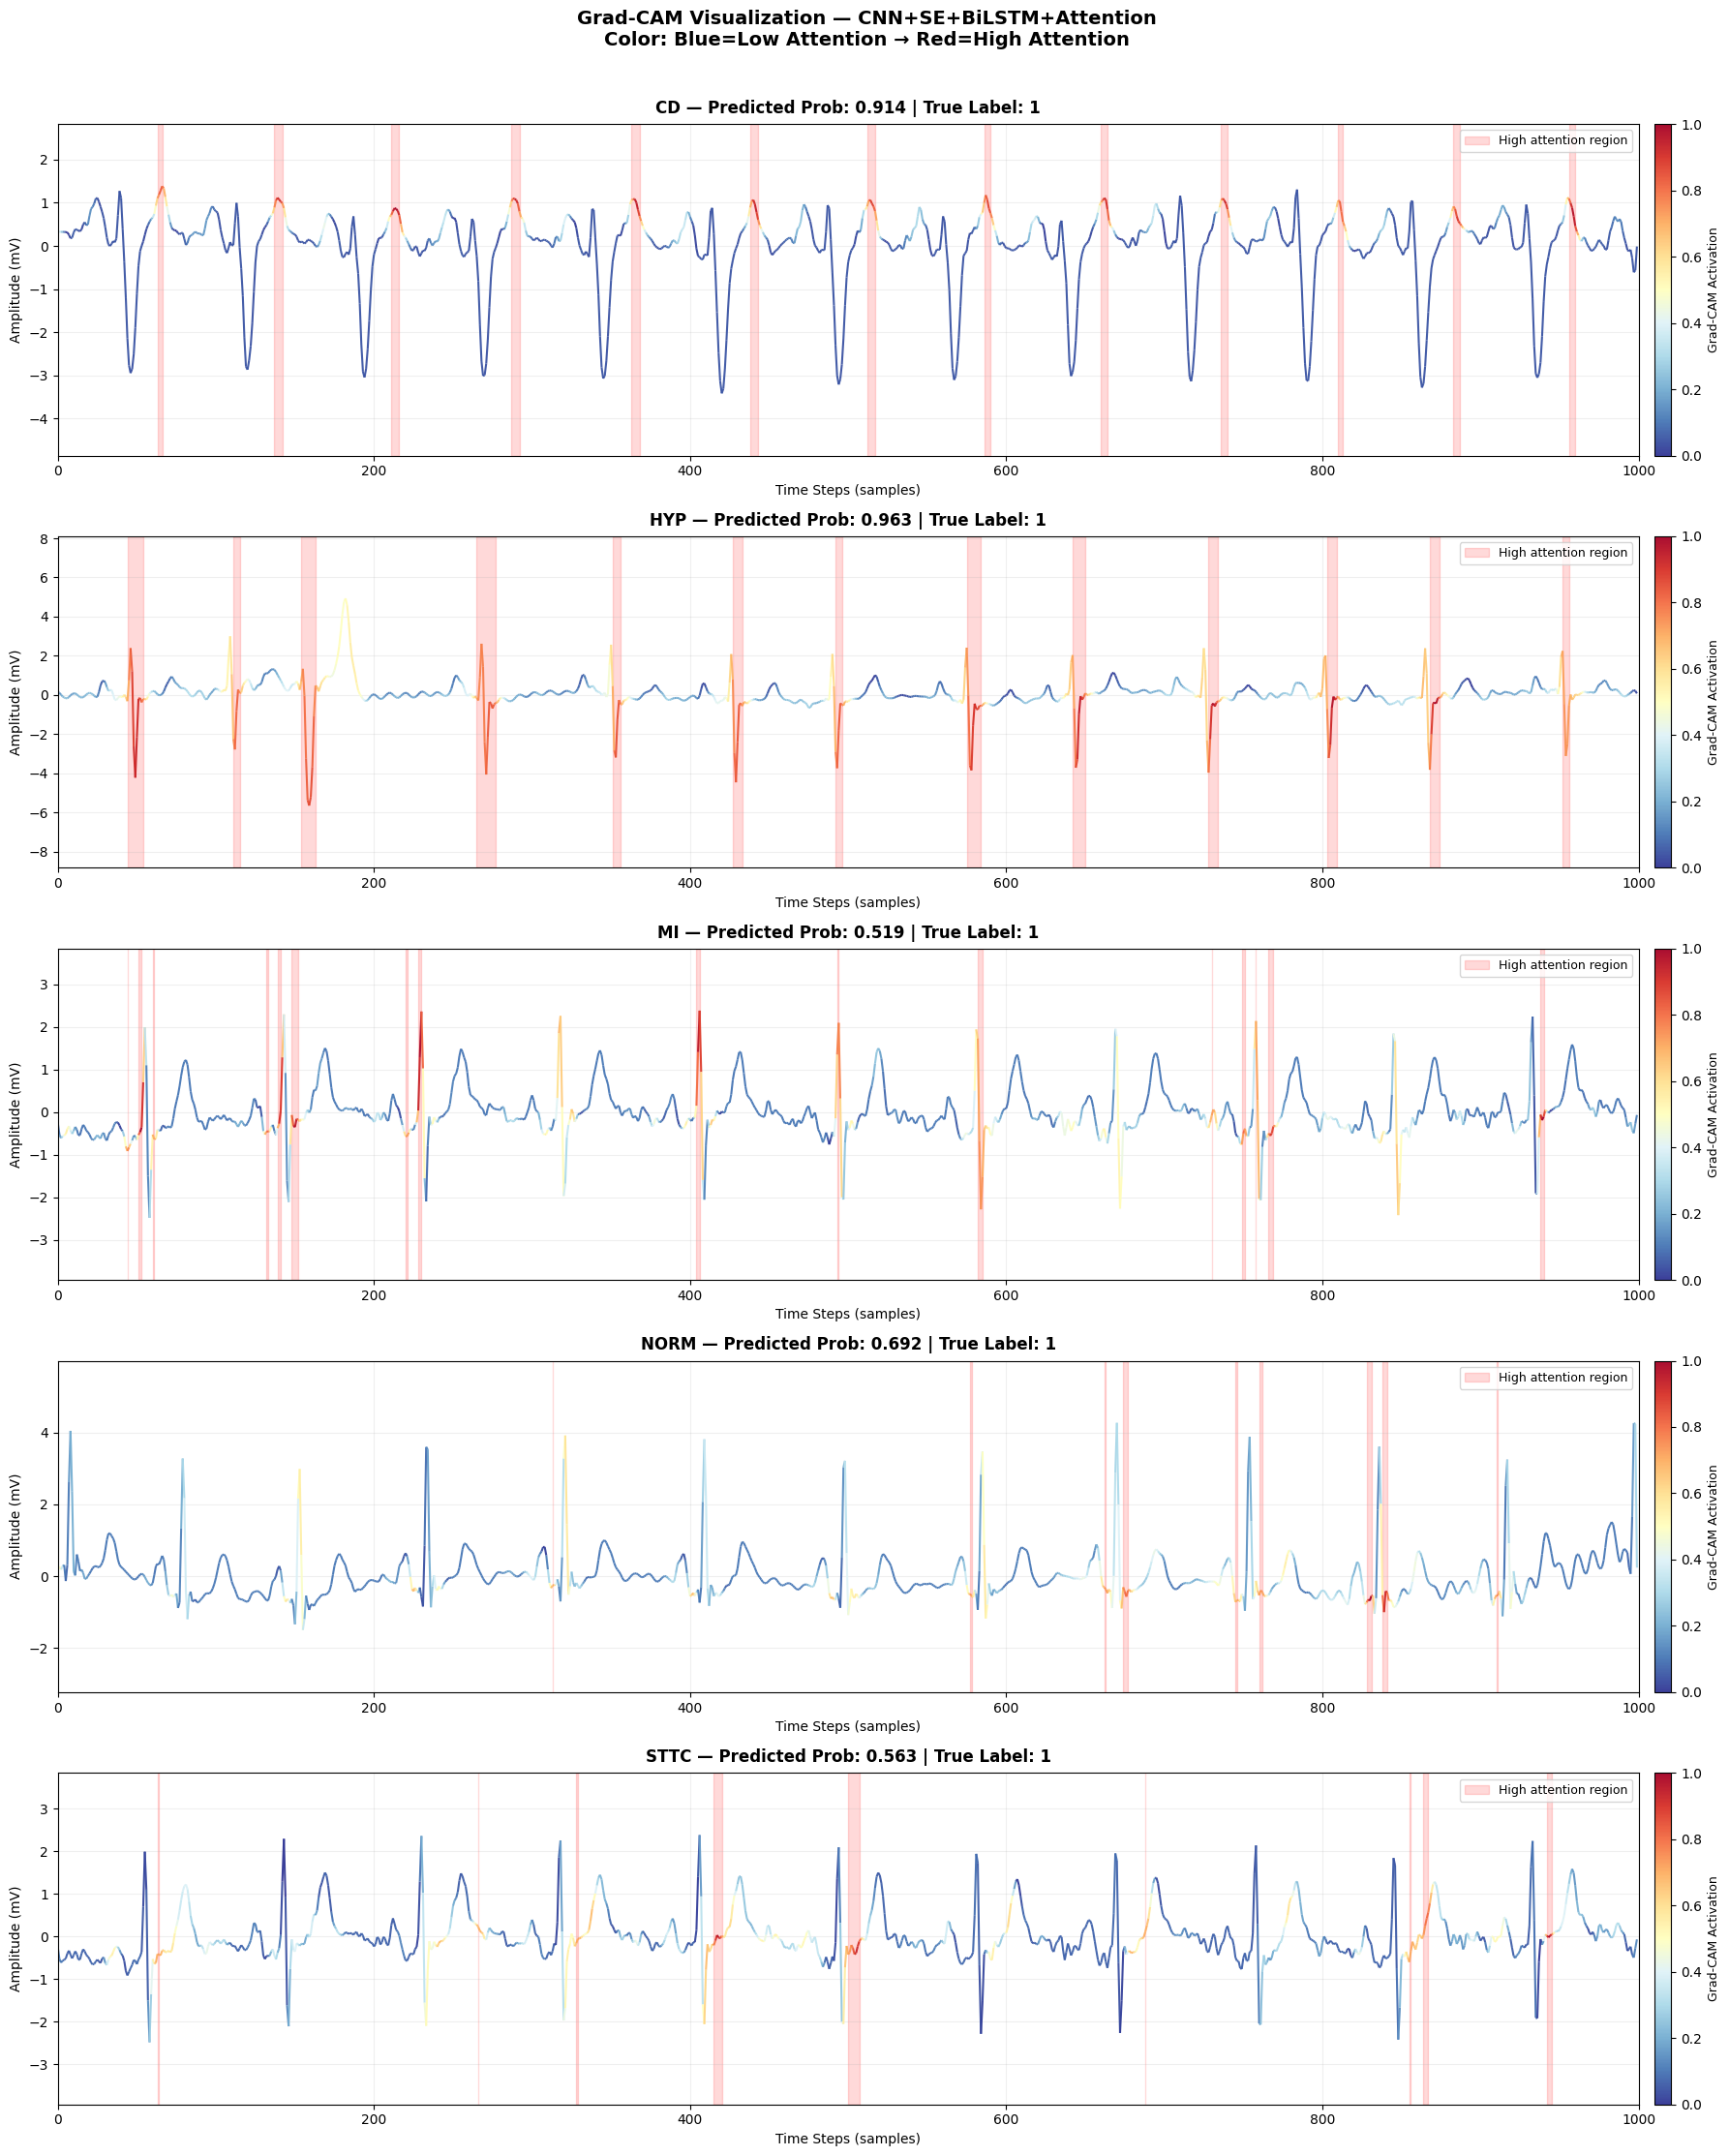

✅ Grad-CAM improved saved!


In [131]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

class_names = ['CD', 'HYP', 'MI', 'NORM', 'STTC']

def compute_gradcam(model, ecg_input, class_idx, layer_name='conv1d_9'):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.output]
    )
    ecg_tensor = tf.cast(ecg_input[np.newaxis, ...], tf.float32)
    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(ecg_tensor)
        loss = predictions[:, class_idx]
    grads        = tape.gradient(loss, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))
    conv_output  = conv_output[0]
    heatmap      = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0)
    heatmap      = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), predictions.numpy()[0]

def get_sample_for_class(X_test, y_test, class_idx, sample_num=0):
    indices = np.where(y_test[:, class_idx] == 1)[0]
    return X_test[indices[sample_num]], indices[sample_num]

fig, axes = plt.subplots(5, 1, figsize=(18, 22))

for class_idx, class_name in enumerate(class_names):

    ecg_sample, sample_idx = get_sample_for_class(
        X_test, y_test, class_idx, sample_num=0)

    heatmap, preds = compute_gradcam(model, ecg_sample, class_idx)

    # 125 → 1000 upsample
    heatmap_up = zoom(heatmap, 1000 / len(heatmap))
    heatmap_up = (heatmap_up - heatmap_up.min()) / \
                 (heatmap_up.max() - heatmap_up.min() + 1e-8)

    lead_idx   = 1  # Lead II
    ecg_signal = ecg_sample[:, lead_idx]
    time_axis  = np.arange(len(ecg_signal))

    ax = axes[class_idx]

    # ✅ Background heatmap — fill_between se
    sig_min = ecg_signal.min()
    sig_max = ecg_signal.max()
    sig_range = sig_max - sig_min

    # Heatmap ko segments mein color karo
    from matplotlib.collections import LineCollection
    from matplotlib.colors import Normalize

    # Line segments banao
    points = np.array([time_axis, ecg_signal]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    norm = Normalize(vmin=0, vmax=1)
    lc = LineCollection(segments, cmap='RdYlBu_r',
                        norm=norm, linewidth=1.5, alpha=0.95)
    lc.set_array(heatmap_up[:-1])
    line = ax.add_collection(lc)

    # Colorbar
    cbar = plt.colorbar(line, ax=ax, fraction=0.02, pad=0.01)
    cbar.set_label('Grad-CAM Activation', fontsize=9)

    # Axis limits
    ax.set_xlim(0, 1000)
    ax.set_ylim(sig_min - 0.3*sig_range, sig_max + 0.3*sig_range)

    pred_prob = preds[class_idx]
    ax.set_title(
        f'{class_name} — Predicted Prob: {pred_prob:.3f} | '
        f'True Label: {int(y_test[sample_idx, class_idx])}',
        fontsize=12, fontweight='bold', pad=8
    )
    ax.set_xlabel('Time Steps (samples)', fontsize=10)
    ax.set_ylabel('Amplitude (mV)', fontsize=10)
    ax.grid(alpha=0.2)

    # High activation regions background shade
    threshold = 0.7
    high_act = heatmap_up > threshold
    ax.fill_between(time_axis,
                    sig_min - 0.3*sig_range,
                    sig_max + 0.3*sig_range,
                    where=high_act,
                    alpha=0.15, color='red',
                    label='High attention region')
    ax.legend(loc='upper right', fontsize=9)

plt.suptitle(
    'Grad-CAM Visualization — CNN+SE+BiLSTM+Attention\n'
    'Color: Blue=Low Attention → Red=High Attention',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('gradcam_improved.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grad-CAM improved saved!")

In [132]:
# Check karo model abhi bhi hai ya nahi
try:
    print(model.summary())
    print("✅ Model memory mein hai!")
except:
    print("❌ Model lost — retrain karna padega")

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 1000, 12)]   0           []                               
                                                                                                  
 conv1d_7 (Conv1D)              (None, 1000, 64)     5440        ['input_2[0][0]']                
                                                                                                  
 batch_normalization_3 (BatchNo  (None, 1000, 64)    256         ['conv1d_7[0][0]']               
 rmalization)                                                                                     
                                                                                                  
 activation_3 (Activation)      (None, 1000, 64)     0           ['batch_normalization_3[0][

In [68]:
model.save('best_model_final.h5')
print("✅ Model saved!")

✅ Model saved!


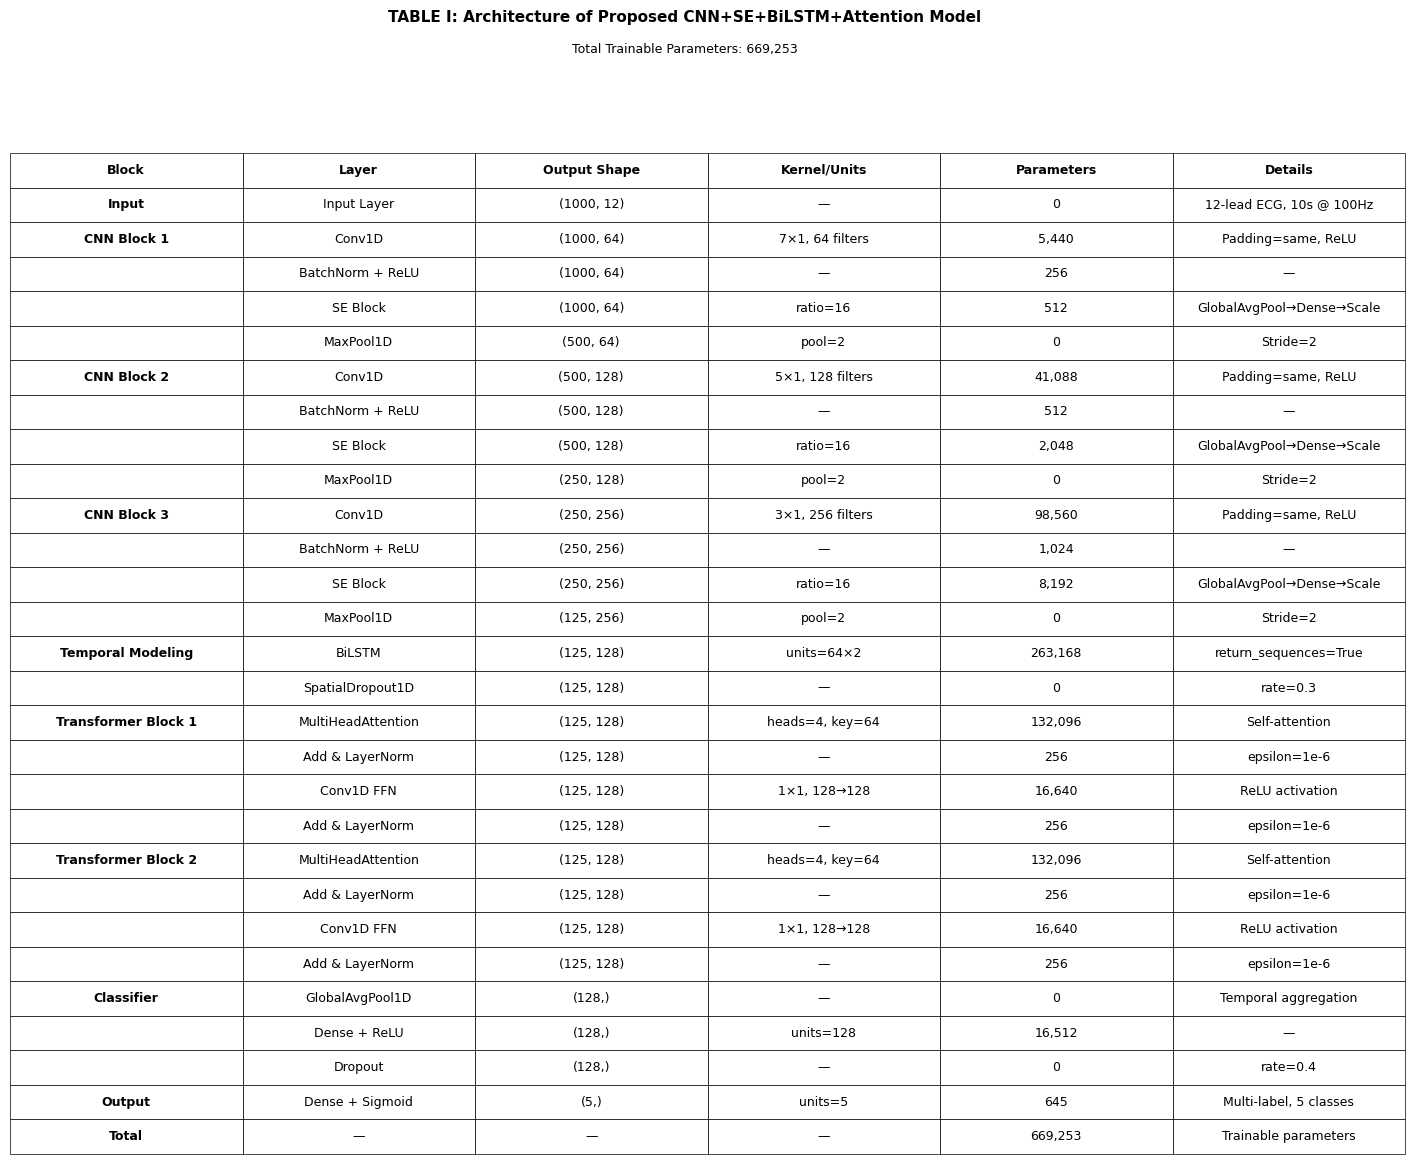

✅ Architecture table saved!


In [152]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18, 13))
ax.axis('off')

columns = [
    'Block', 'Layer', 'Output Shape',
    'Kernel/Units', 'Parameters', 'Details'
]

data = [
    ['Input', 'Input Layer', '(1000, 12)', '—', '0', '12-lead ECG, 10s @ 100Hz'],
    ['CNN Block 1', 'Conv1D', '(1000, 64)', '7×1, 64 filters', '5,440', 'Padding=same, ReLU'],
    ['', 'BatchNorm + ReLU', '(1000, 64)', '—', '256', '—'],
    ['', 'SE Block', '(1000, 64)', 'ratio=16', '512', 'GlobalAvgPool→Dense→Scale'],
    ['', 'MaxPool1D', '(500, 64)', 'pool=2', '0', 'Stride=2'],
    ['CNN Block 2', 'Conv1D', '(500, 128)', '5×1, 128 filters', '41,088', 'Padding=same, ReLU'],
    ['', 'BatchNorm + ReLU', '(500, 128)', '—', '512', '—'],
    ['', 'SE Block', '(500, 128)', 'ratio=16', '2,048', 'GlobalAvgPool→Dense→Scale'],
    ['', 'MaxPool1D', '(250, 128)', 'pool=2', '0', 'Stride=2'],
    ['CNN Block 3', 'Conv1D', '(250, 256)', '3×1, 256 filters', '98,560', 'Padding=same, ReLU'],
    ['', 'BatchNorm + ReLU', '(250, 256)', '—', '1,024', '—'],
    ['', 'SE Block', '(250, 256)', 'ratio=16', '8,192', 'GlobalAvgPool→Dense→Scale'],
    ['', 'MaxPool1D', '(125, 256)', 'pool=2', '0', 'Stride=2'],
    ['Temporal Modeling', 'BiLSTM', '(125, 128)', 'units=64×2', '263,168', 'return_sequences=True'],
    ['', 'SpatialDropout1D', '(125, 128)', '—', '0', 'rate=0.3'],
    ['Transformer Block 1', 'MultiHeadAttention', '(125, 128)', 'heads=4, key=64', '132,096', 'Self-attention'],
    ['', 'Add & LayerNorm', '(125, 128)', '—', '256', 'epsilon=1e-6'],
    ['', 'Conv1D FFN', '(125, 128)', '1×1, 128→128', '16,640', 'ReLU activation'],
    ['', 'Add & LayerNorm', '(125, 128)', '—', '256', 'epsilon=1e-6'],
    ['Transformer Block 2', 'MultiHeadAttention', '(125, 128)', 'heads=4, key=64', '132,096', 'Self-attention'],
    ['', 'Add & LayerNorm', '(125, 128)', '—', '256', 'epsilon=1e-6'],
    ['', 'Conv1D FFN', '(125, 128)', '1×1, 128→128', '16,640', 'ReLU activation'],
    ['', 'Add & LayerNorm', '(125, 128)', '—', '256', 'epsilon=1e-6'],
    ['Classifier', 'GlobalAvgPool1D', '(128,)', '—', '0', 'Temporal aggregation'],
    ['', 'Dense + ReLU', '(128,)', 'units=128', '16,512', '—'],
    ['', 'Dropout', '(128,)', '—', '0', 'rate=0.4'],
    ['Output', 'Dense + Sigmoid', '(5,)', 'units=5', '645', 'Multi-label, 5 classes'],
    ['Total', '—', '—', '—', '669,253', 'Trainable parameters'],
]

table = ax.table(
    cellText=data,
    colLabels=columns,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

# Sab cells — white background, black text, simple border
for (row, col), cell in table.get_celld().items():
    cell.set_facecolor('white')
    cell.set_edgecolor('black')
    cell.set_linewidth(0.5)
    cell.set_text_props(color='black', fontsize=9)

# Header row — bold text only, white background
for j in range(len(columns)):
    table[0, j].set_text_props(fontweight='bold', fontsize=9)

# Block name cells — bold
block_names = ['Input', 'CNN Block 1', 'CNN Block 2', 'CNN Block 3',
               'Temporal Modeling', 'Transformer Block 1',
               'Transformer Block 2', 'Classifier', 'Output', 'Total']
for i in range(1, len(data)+1):
    if data[i-1][0] in block_names:
        table[i, 0].set_text_props(fontweight='bold', fontsize=9)

# Title
fig.text(0.5, 0.99,
         'TABLE I: Architecture of Proposed CNN+SE+BiLSTM+Attention Model',
         ha='center', va='top', fontsize=11, fontweight='bold', color='black')
fig.text(0.5, 0.965,
         'Total Trainable Parameters: 669,253',
         ha='center', va='top', fontsize=9, color='black')

# High DPI — text blur nahi hoga
plt.savefig('architecture_table.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Architecture table saved!")

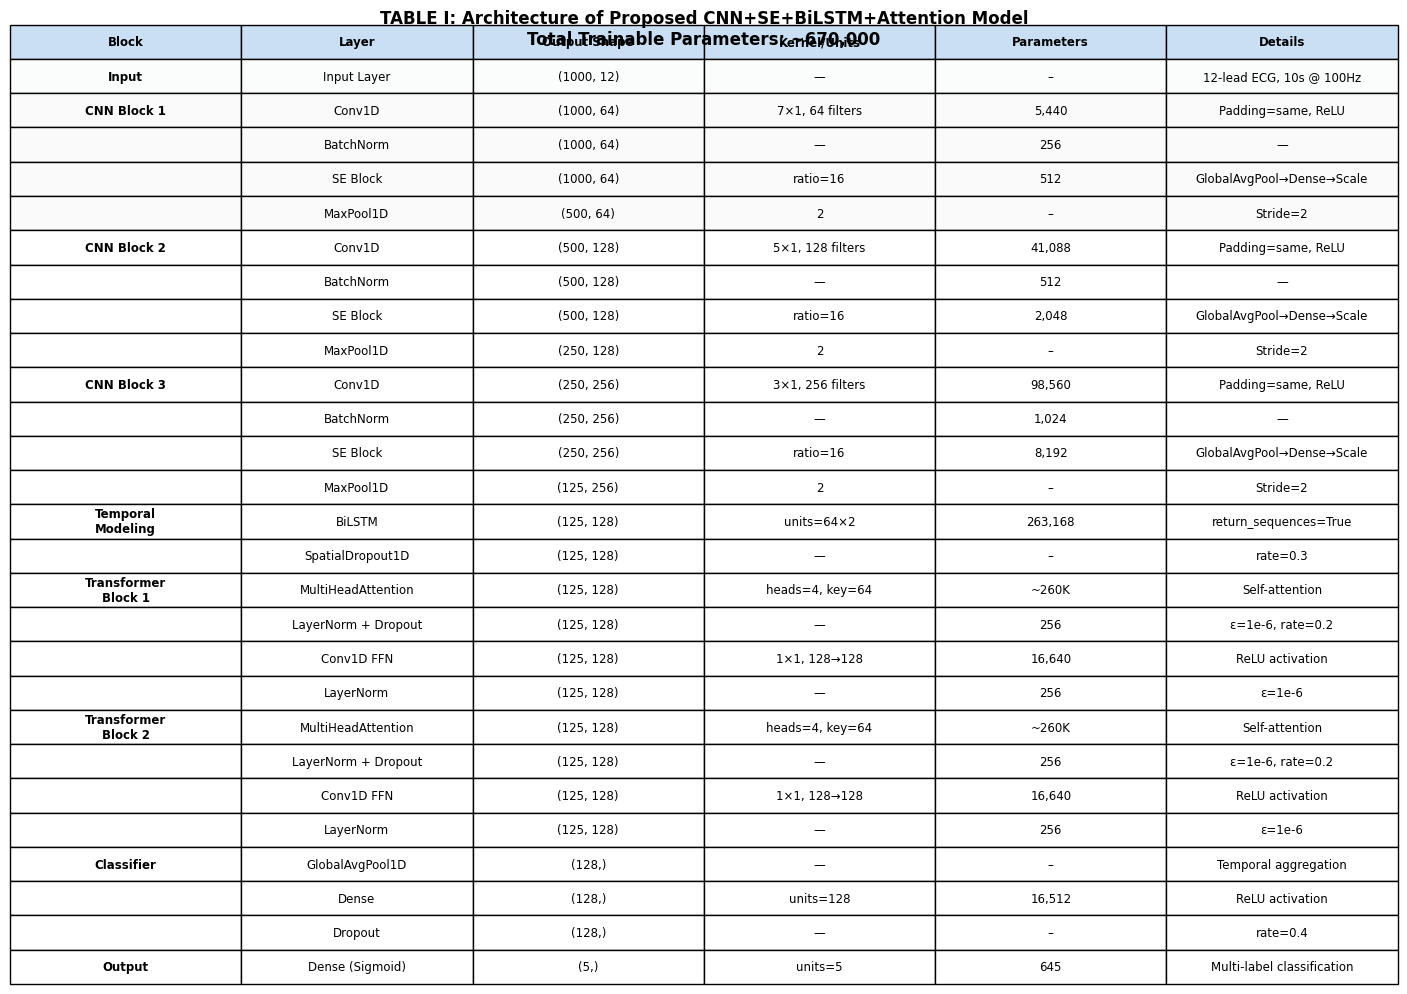

✅ Architecture table saved!


In [151]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 10))
ax.axis('off')

columns = [
    'Block', 'Layer', 'Output Shape',
    'Kernel/Units', 'Parameters', 'Details'
]

data = [
    # Input
    ['Input', 'Input Layer', '(1000, 12)', '—', '–', '12-lead ECG, 10s @ 100Hz'],

    # CNN Block 1
    ['CNN Block 1', 'Conv1D', '(1000, 64)', '7×1, 64 filters', '5,440', 'Padding=same, ReLU'],
    ['', 'BatchNorm', '(1000, 64)', '—', '256', '—'],
    ['', 'SE Block', '(1000, 64)', 'ratio=16', '512', 'GlobalAvgPool→Dense→Scale'],
    ['', 'MaxPool1D', '(500, 64)', '2', '–', 'Stride=2'],

    # CNN Block 2
    ['CNN Block 2', 'Conv1D', '(500, 128)', '5×1, 128 filters', '41,088', 'Padding=same, ReLU'],
    ['', 'BatchNorm', '(500, 128)', '—', '512', '—'],
    ['', 'SE Block', '(500, 128)', 'ratio=16', '2,048', 'GlobalAvgPool→Dense→Scale'],
    ['', 'MaxPool1D', '(250, 128)', '2', '–', 'Stride=2'],

    # CNN Block 3
    ['CNN Block 3', 'Conv1D', '(250, 256)', '3×1, 256 filters', '98,560', 'Padding=same, ReLU'],
    ['', 'BatchNorm', '(250, 256)', '—', '1,024', '—'],
    ['', 'SE Block', '(250, 256)', 'ratio=16', '8,192', 'GlobalAvgPool→Dense→Scale'],
    ['', 'MaxPool1D', '(125, 256)', '2', '–', 'Stride=2'],

    # BiLSTM
    ['Temporal\nModeling', 'BiLSTM', '(125, 128)', 'units=64×2', '263,168', 'return_sequences=True'],
    ['', 'SpatialDropout1D', '(125, 128)', '—', '–', 'rate=0.3'],

    # Transformer 1
    ['Transformer\nBlock 1', 'MultiHeadAttention', '(125, 128)', 'heads=4, key=64', '~260K', 'Self-attention'],
    ['', 'LayerNorm + Dropout', '(125, 128)', '—', '256', 'ε=1e-6, rate=0.2'],
    ['', 'Conv1D FFN', '(125, 128)', '1×1, 128→128', '16,640', 'ReLU activation'],
    ['', 'LayerNorm', '(125, 128)', '—', '256', 'ε=1e-6'],

    # Transformer 2
    ['Transformer\nBlock 2', 'MultiHeadAttention', '(125, 128)', 'heads=4, key=64', '~260K', 'Self-attention'],
    ['', 'LayerNorm + Dropout', '(125, 128)', '—', '256', 'ε=1e-6, rate=0.2'],
    ['', 'Conv1D FFN', '(125, 128)', '1×1, 128→128', '16,640', 'ReLU activation'],
    ['', 'LayerNorm', '(125, 128)', '—', '256', 'ε=1e-6'],

    # Classifier
    ['Classifier', 'GlobalAvgPool1D', '(128,)', '—', '–', 'Temporal aggregation'],
    ['', 'Dense', '(128,)', 'units=128', '16,512', 'ReLU activation'],
    ['', 'Dropout', '(128,)', '—', '–', 'rate=0.4'],

    # Output
    ['Output', 'Dense (Sigmoid)', '(5,)', 'units=5', '645', 'Multi-label classification'],
]

table = ax.table(
    cellText=data,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1.1, 1.8)

# Header — blue
for j in range(len(columns)):
    table[0, j].set_facecolor("#CBDFF4")
    table[0, j].set_text_props(color='black', fontweight='bold')

# Block colors
block_colors = {
    'Input': "#FBFCFC",
    'CNN Block 1': "#FAFAFA",
    'CNN Block 2': "#FFFFFF",
    'CNN Block 3': "#FFFFFF",
    'Temporal\nModeling': "#FFFFFF",
    'Transformer\nBlock 1': "#FFFFFF",
    'Transformer\nBlock 2': "#FFFFFF",
    'Classifier': "#FFFFFF",
    'Output': "#FFFFFF",
}

current_color = '#FFFFFF'
for i in range(1, len(data)+1):
    block = data[i-1][0]
    if block in block_colors:
        current_color = block_colors[block]
    for j in range(len(columns)):
        table[i, j].set_facecolor(current_color)
        if j == 0 and block in block_colors:
            table[i, j].set_text_props(fontweight='bold')

plt.title(
    'TABLE I: Architecture of Proposed CNN+SE+BiLSTM+Attention Model\n'
    'Total Trainable Parameters: ~670,000',
    fontsize=12, fontweight='bold', pad=15
)

plt.tight_layout()
plt.savefig('architecture_table.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Architecture table saved!")

In [ ]:
# check param
model.summary()
total = sum([tf.keras.backend.count_params(w) 
             for w in model.trainable_weights])
print(f"\nTotal trainable params: {total:,}")

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 1000, 12)]   0           []                               
                                                                                                  
 conv1d_7 (Conv1D)              (None, 1000, 64)     5440        ['input_2[0][0]']                
                                                                                                  
 batch_normalization_3 (BatchNo  (None, 1000, 64)    256         ['conv1d_7[0][0]']               
 rmalization)                                                                                     
                                                                                                  
 activation_3 (Activation)      (None, 1000, 64)     0           ['batch_normalization_3[0][

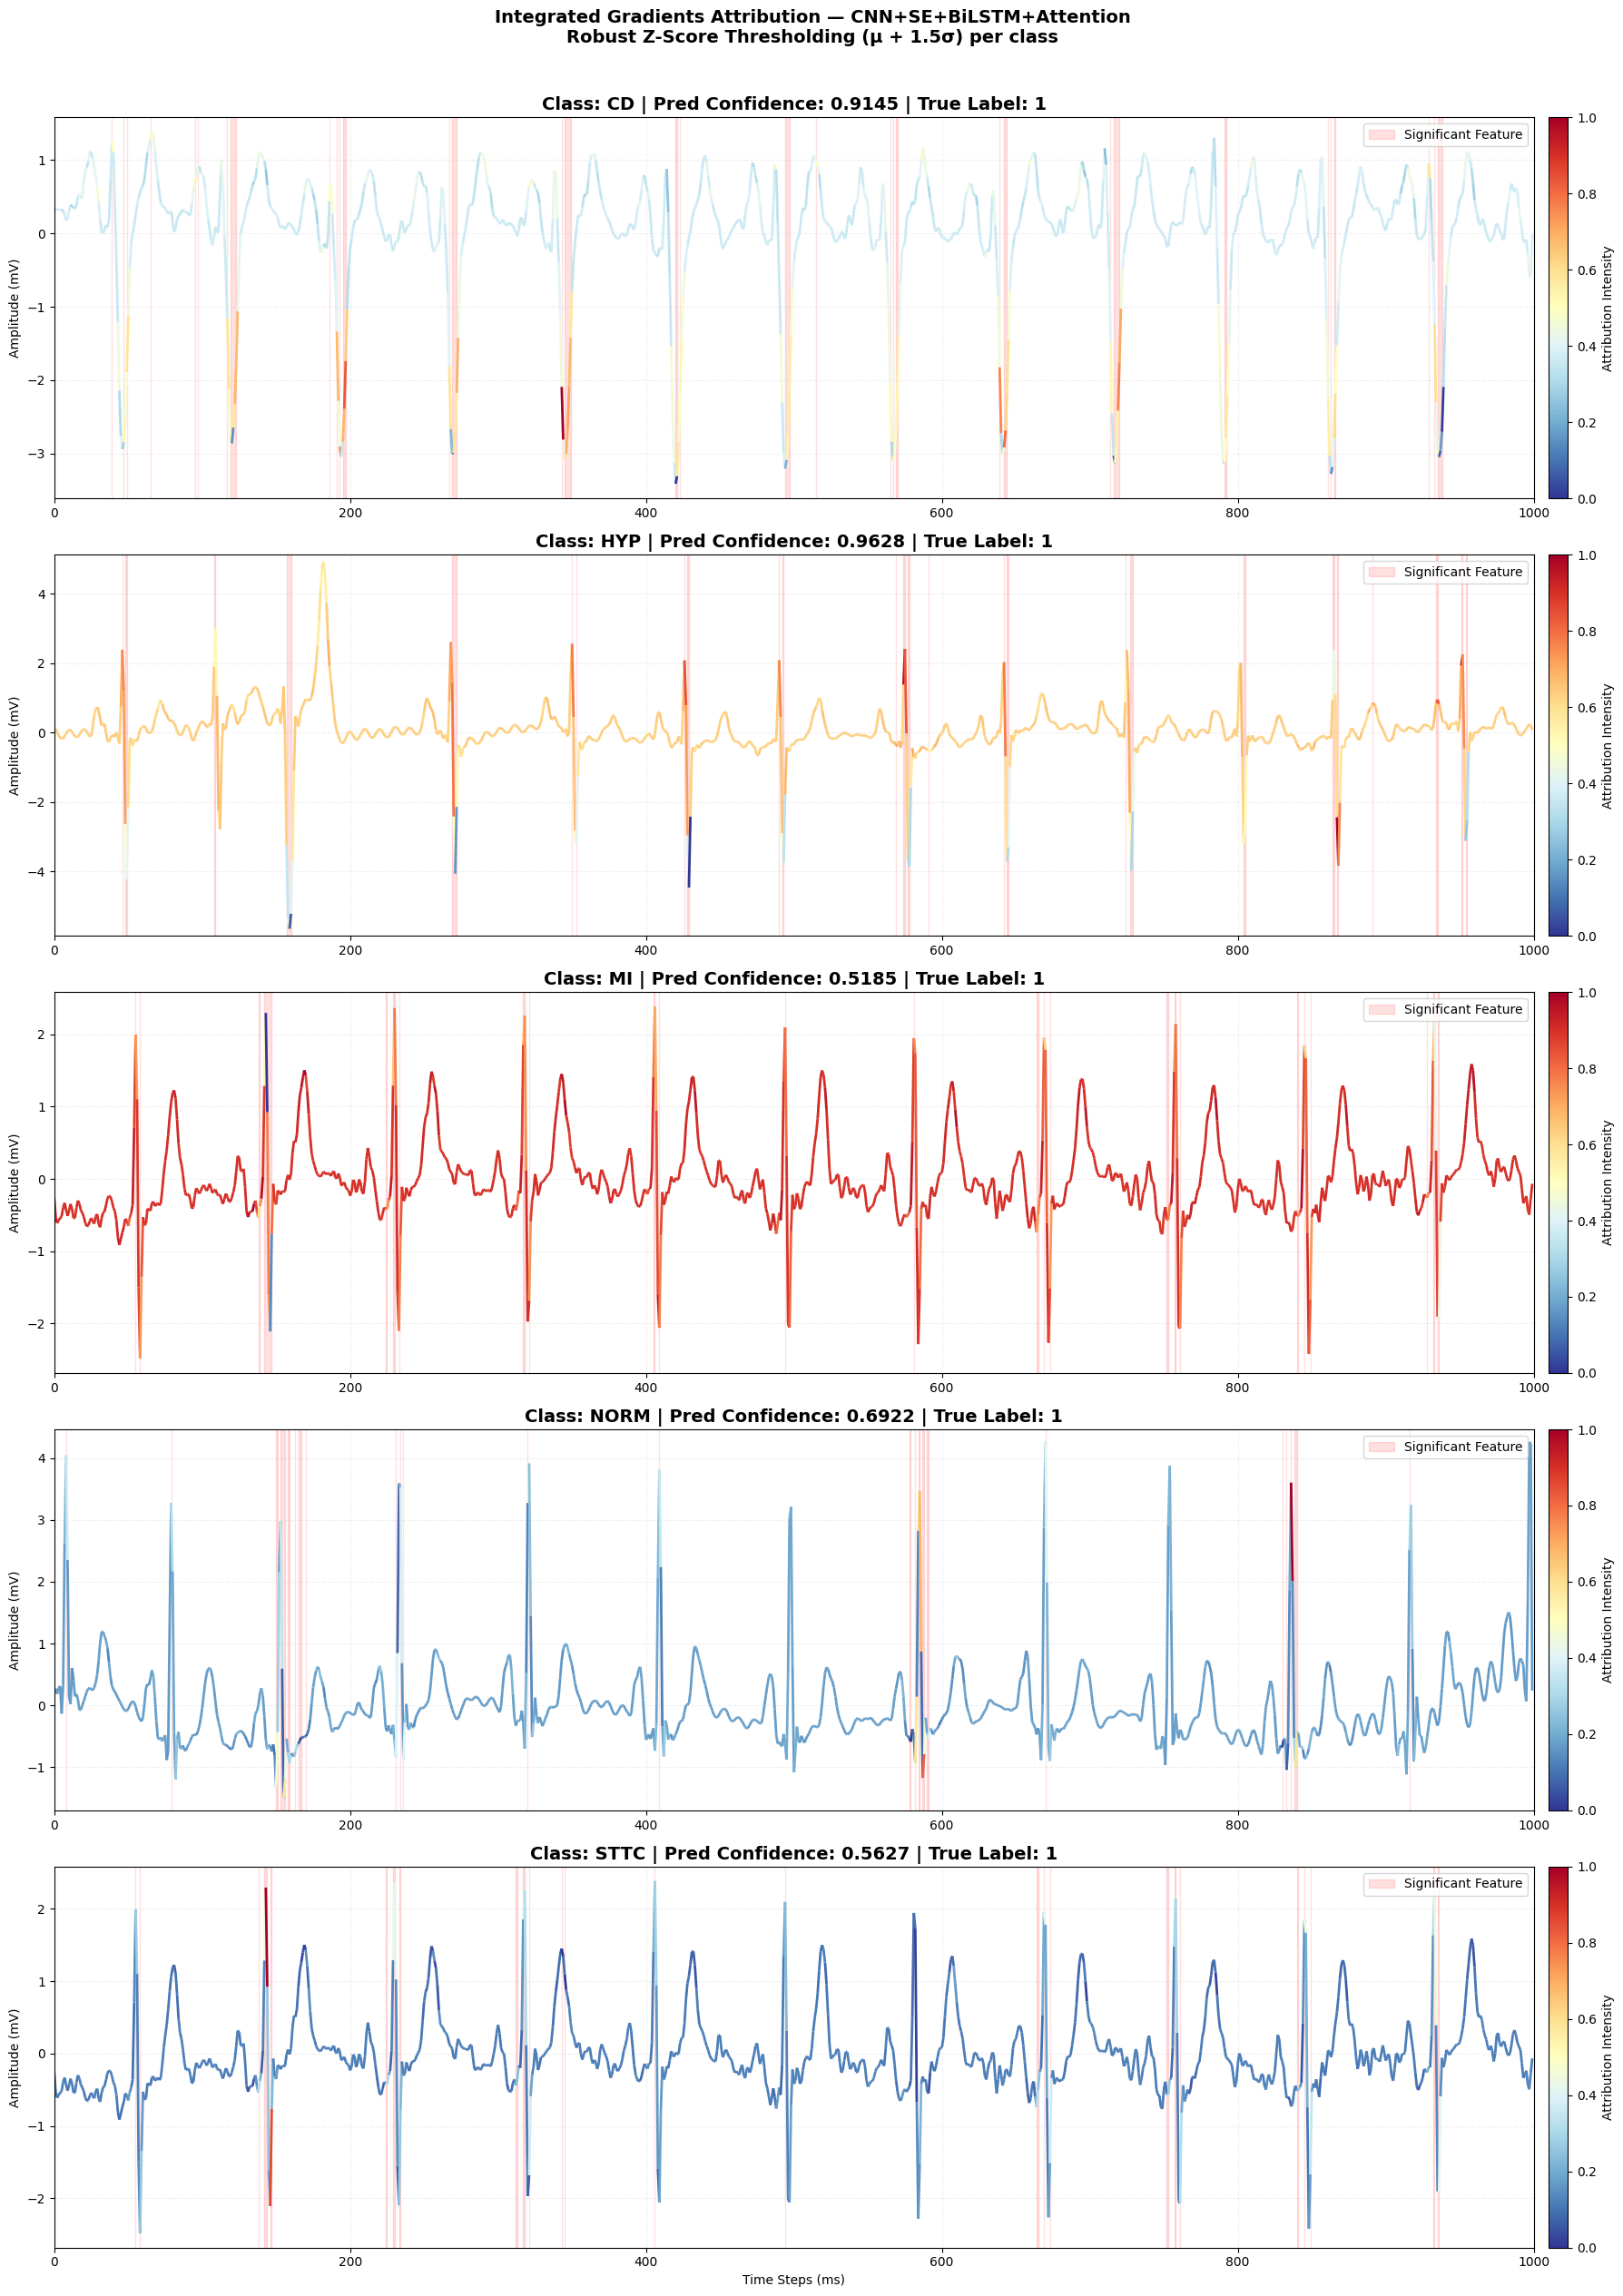

✅ Professional IG plot with dynamic thresholding saved as ig_final_robust.png


In [147]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

# --- Setup ---
class_names = ['CD', 'HYP', 'MI', 'NORM', 'STTC']

def integrated_gradients(model, ecg_input, class_idx, steps=50):
    """
    Computes Integrated Gradients for a specific class.
    Steps = 50 ensures axiomatic completeness for IEEE standards.
    """
    baseline = np.zeros_like(ecg_input, dtype='float32')
    ecg_input = ecg_input.astype('float32')
    alphas = np.linspace(0, 1, steps)
    
    # Generate interpolated paths
    interpolated = tf.constant(
        np.array([baseline + a*(ecg_input-baseline) 
                  for a in alphas], dtype='float32'))
    
    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        preds = model(interpolated, training=False)
        target = preds[:, class_idx]
    
    # Calculate gradients and integrate
    grads = tape.gradient(target, interpolated)
    avg_grads = tf.reduce_mean(grads, axis=0).numpy()
    ig = (ecg_input - baseline) * avg_grads
    
    # Final prediction for the title
    pred = model(
        tf.constant(ecg_input[np.newaxis,...], dtype='float32'),
        training=False).numpy()[0]
    
    return ig, pred

# --- Visualization Logic ---
fig, axes = plt.subplots(5, 1, figsize=(18, 25))

for class_idx, class_name in enumerate(class_names):
    # Get first true positive sample from test set
    idx = np.where(y_test[:, class_idx] == 1)[0][0]
    ecg_sample = X_test[idx]

    # Compute IG
    ig_attrs, preds = integrated_gradients(model, ecg_sample, class_idx, steps=50)

    # Lead Selection (Lead II is clinically standard)
    lead_idx = 1 
    ecg_signal = ecg_sample[:, lead_idx]
    ig_signal = ig_attrs[:, lead_idx]
    time_axis = np.arange(len(ecg_signal))

    # --- ROBUST SCALING & THRESHOLDING ---
    # 1. Use absolute values for thresholding but keep signed for color
    abs_ig = np.abs(ig_signal)
    
    # 2. Normalize 0-1 for the colormap (Min-Max)
    ig_norm = (ig_signal - ig_signal.min()) / (ig_signal.max() - ig_signal.min() + 1e-8)

    # 3. Dynamic Thresholding: Mean + 1.5 * Standard Deviation
    # This prevents the 'all red' background in high-noise or low-confidence cases
    dynamic_threshold = np.mean(abs_ig) + 1.5 * np.std(abs_ig)
    
    # --- Plotting ---
    ax = axes[class_idx]
    points = np.array([time_axis, ecg_signal]).T.reshape(-1, 1, 2)
    segs = np.concatenate([points[:-1], points[1:]], axis=1)
    
    # Color the line based on normalized IG
    lc = LineCollection(segs, cmap='RdYlBu_r', norm=Normalize(0, 1), linewidth=2.0)
    lc.set_array(ig_norm[:-1])
    line = ax.add_collection(lc)

    # Add highlight background ONLY where IG is statistically significant
    ax.fill_between(time_axis, 
                    ecg_signal.min() - 0.5, 
                    ecg_signal.max() + 0.5,
                    where=(abs_ig > dynamic_threshold),
                    alpha=0.12, color='red', label='Significant Feature')

    # Colorbar and Labels
    plt.colorbar(line, ax=ax, fraction=0.02, pad=0.01, label='Attribution Intensity')
    
    ax.set_xlim(0, 1000)
    ax.set_ylim(ecg_signal.min() - 0.2, ecg_signal.max() + 0.2)
    ax.set_title(f"Class: {class_name} | Pred Confidence: {preds[class_idx]:.4f} | True Label: 1", 
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('Amplitude (mV)')
    ax.grid(alpha=0.2, linestyle='--')
    if class_idx == 4: ax.set_xlabel('Time Steps (ms)')
    ax.legend(loc='upper right')

plt.suptitle('Integrated Gradients Attribution — CNN+SE+BiLSTM+Attention\n'
            'Robust Z-Score Thresholding (μ + 1.5σ) per class',
            fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('ig_final_robust.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Professional IG plot with dynamic thresholding saved as ig_final_robust.png")

In [3]:
import os

# Check kar kya hai D:\heart_disease\ me
base = r'D:\heart_disease'
print("=== FILES IN D:\\heart_disease\\ ===")
for f in os.listdir(base):
    size = os.path.getsize(os.path.join(base, f))
    print(f"  {f:40s} {size/1024/1024:.1f} MB")

print("\n=== IMPORTANT FILES CHECK ===")
files_to_check = [
    r'D:\heart_disease\best_model_final.h5',
    r'D:\heart_disease\X_test.npy',
    r'D:\heart_disease\y_test.npy',
    r'D:\heart_disease\y_prob.npy',
    r'D:\heart_disease\X_train.npy',
    r'D:\heart_disease\y_train.npy',
]
for f in files_to_check:
    exists = os.path.exists(f)
    if exists:
        size = os.path.getsize(f)/1024/1024
        print(f"  ✅ FOUND:   {os.path.basename(f):30s} {size:.1f} MB")
    else:
        print(f"  ❌ MISSING: {os.path.basename(f)}")

print("\n=== PTB-XL DATABASE CHECK ===")
ptb_candidates = [
    r'D:\heart_disease\ptb-xl',
    r'D:\heart_disease\ptbxl',
    r'D:\heart_disease\data',
    r'D:\ptb-xl',
    r'D:\ptbxl',
    r'C:\ptb-xl',
]
for p in ptb_candidates:
    if os.path.exists(p):
        print(f"  ✅ FOUND: {p}")
        # Check key files inside
        for key_file in ['ptbxl_database.csv', 'scp_statements.csv']:
            kf = os.path.join(p, key_file)
            print(f"      {'✅' if os.path.exists(kf) else '❌'} {key_file}")
    else:
        print(f"  ❌ {p}")

=== FILES IN D:\heart_disease\ ===
  .gitignore                               0.0 MB
  AI.pdf                                   3.3 MB
  architecture_table.png                   0.6 MB
  best_bilstm_model.h5                     6.1 MB
  best_ecg_model.h5                        12.2 MB
  best_focal_bilstm_model.h5               6.1 MB
  best_model.h5                            7.2 MB
  best_model_final.h5                      8.0 MB
  best_thresholds.json                     0.0 MB
  best_xecg_model.h5                       8.0 MB
  chapman                                  0.0 MB
  cm.png                                   0.1 MB
  cmoutput.png                             0.1 MB
  code15                                   0.0 MB
  confusion_matrix_final.png               0.1 MB
  confusion_matrix_normalized.png          0.1 MB
  coutput.png                              0.1 MB
  curve.pdf                                0.1 MB
  curve.png                                0.1 MB
  data        

In [4]:
import os
import json

# ── 1. best_thresholds.json padho ──
thresh_path = r'D:\heart_disease\best_thresholds.json'
if os.path.exists(thresh_path):
    with open(thresh_path, 'r') as f:
        saved_thresholds = json.load(f)
    print("=== SAVED THRESHOLDS ===")
    print(json.dumps(saved_thresholds, indent=2))
else:
    print("❌ best_thresholds.json nahi mila")

# ── 2. Data folder ke andar kya hai ──
print("\n=== D:\\heart_disease\\data\\ CONTENTS ===")
data_path = r'D:\heart_disease\data'
if os.path.exists(data_path):
    for root, dirs, files in os.walk(data_path):
        level = root.replace(data_path, '').count(os.sep)
        indent = '  ' * level
        print(f"{indent}{os.path.basename(root)}/")
        if level < 3:  # 3 levels deep tak
            for file in files[:10]:  # max 10 files per folder
                fpath = os.path.join(root, file)
                size  = os.path.getsize(fpath)/1024/1024
                print(f"{indent}  {file:40s} {size:.1f} MB")
else:
    print("❌ data folder nahi mila")

# ── 3. Saari .npy files dhundho ──
print("\n=== .NPY FILES IN D:\\heart_disease\\ ===")
for f in os.listdir(r'D:\heart_disease'):
    if f.endswith('.npy'):
        size = os.path.getsize(
            os.path.join(r'D:\heart_disease', f))/1024/1024
        print(f"  ✅ {f:40s} {size:.1f} MB")
        
# ── 4. Baaki folders check karo ──
print("\n=== SUBFOLDERS ===")
for f in os.listdir(r'D:\heart_disease'):
    full = os.path.join(r'D:\heart_disease', f)
    if os.path.isdir(full):
        try:
            contents = os.listdir(full)
            print(f"  📁 {f}/  ({len(contents)} items)")
            for item in contents[:5]:
                print(f"       - {item}")
        except:
            print(f"  📁 {f}/  (access error)")

=== SAVED THRESHOLDS ===
{
  "thresholds": [
    0.42,
    0.4,
    0.45,
    0.5,
    0.45
  ],
  "classes": [
    "CD",
    "HYP",
    "MI",
    "NORM",
    "STTC"
  ],
  "test_auc": 0.9361,
  "macro_f1": 0.749
}

=== D:\heart_disease\data\ CONTENTS ===
data/

=== .NPY FILES IN D:\heart_disease\ ===
  ✅ X_test.npy                               199.6 MB
  ✅ y_test.npy                               0.0 MB

=== SUBFOLDERS ===
  📁 chapman/  (5 items)
       - ConditionNames_SNOMED-CT.csv
       - LICENSE.txt
       - RECORDS
       - SHA256SUMS.txt
       - WFDBRecords
  📁 code15/  (2 items)
       - exams.csv
       - exams_part0.hdf5
  📁 data/  (0 items)
  📁 ecg_mulmodal_project/  (115 items)
       - .git
       - .gitignore
       - best_text_only.pth
       - cardiac_discharge.csv
       - cardiac_discharge_clean.csv
  📁 figures/  (0 items)
  📁 notebooks/  (0 items)
  📁 ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/  (10 items)
       - example_physionet.py
   

In [5]:
import json

# ecgfinal.ipynb me dekho - wahan X_test/y_test save hua hoga
nb_path = r'D:\heart_disease\ecgfinal.ipynb'
if os.path.exists(nb_path):
    with open(nb_path, 'r', encoding='utf-8') as f:
        nb = json.load(f)
    
    print("=== SAVE/LOAD RELATED CELLS ===")
    keywords = ['np.save', 'np.load', 'X_test', 'y_test', 
                'ptb', 'PTB', 'filename', 'strat_fold']
    
    for i, cell in enumerate(nb['cells']):
        if cell['cell_type'] == 'code':
            source = ''.join(cell['source'])
            if any(kw in source for kw in keywords):
                print(f"\n--- Cell {i} ---")
                print(source[:500])
                print("...")

=== SAVE/LOAD RELATED CELLS ===

--- Cell 3 ---
data_PATH = "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/"

CHAPMAN_PATH = "chapman/"

CODE_PATH = "code15"   
...

--- Cell 6 ---
import pandas as pd
import os

data_path = data_path = "D:/heart_disease/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"

print("Files:", os.listdir(data_path))

df = pd.read_csv("D:\heart_disease\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\ptbxl_database.csv")
print(df.head())
print("Total samples:", len(df))

...

--- Cell 9 ---
import wfdb
import numpy as np
from tqdm import tqdm

# list for storing all signal
all_signals = []

print("Loading all ECG signals...")

for f in tqdm(df['filename_lr']):
    file_path = data_path + "/" + f
    record = wfdb.rdrecord(file_path)
    all_signals.append(record.p_signal)

# convert to numpy
x_ptb = np.array(all_signals)

print("Shape of x_ptb:", x_ptb.shape)
...

--- Cell 14 ---
y_ptb = y
...

--- Cel

In [6]:
import numpy as np
import json
import os
import tensorflow as tf
from sklearn.metrics import roc_auc_score, confusion_matrix, hamming_loss
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

BASE = r'D:\heart_disease'

# ── Check karo y_test.npy hai ya nahi ──
print("=== NPY FILES CHECK ===")
for f in os.listdir(BASE):
    if f.endswith('.npy'):
        size = os.path.getsize(os.path.join(BASE, f))/1024/1024
        print(f"  ✅ {f:35s} {size:.1f} MB")

# ── Thresholds load ──
with open(os.path.join(BASE, 'best_thresholds.json'), 'r') as f:
    thresh_data = json.load(f)

class_names = thresh_data['classes']   # ['CD','HYP','MI','NORM','STTC']
tau         = np.array(thresh_data['thresholds'])  # [0.42,0.40,0.45,0.50,0.45]

print(f"\n=== CORRECT THRESHOLDS (from best_thresholds.json) ===")
for cls, t in zip(class_names, tau):
    print(f"  τ_{cls:4s} = {t}")

print(f"\n⚠️  PAPER ME LIKHE THRESHOLDS:")
paper_tau = {'CD':0.35, 'HYP':0.40, 'MI':0.40, 'NORM':0.50, 'STTC':0.45}
for cls, t in paper_tau.items():
    saved = thresh_data['thresholds'][class_names.index(cls)]
    match = "✅" if abs(t - saved) < 0.001 else "❌ MISMATCH"
    print(f"  {cls}: paper={t}, saved={saved}  {match}")

=== NPY FILES CHECK ===
  ✅ X_test.npy                          199.6 MB
  ✅ y_test.npy                          0.0 MB

=== CORRECT THRESHOLDS (from best_thresholds.json) ===
  τ_CD   = 0.42
  τ_HYP  = 0.4
  τ_MI   = 0.45
  τ_NORM = 0.5
  τ_STTC = 0.45

⚠️  PAPER ME LIKHE THRESHOLDS:
  CD: paper=0.35, saved=0.42  ❌ MISMATCH
  HYP: paper=0.4, saved=0.4  ✅
  MI: paper=0.4, saved=0.45  ❌ MISMATCH
  NORM: paper=0.5, saved=0.5  ✅
  STTC: paper=0.45, saved=0.45  ✅


In [1]:
import numpy as np
import json
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
# GPU memory growth enable karo
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

from sklearn.metrics import roc_auc_score, confusion_matrix, hamming_loss
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

BASE = r'D:\heart_disease'

# ── Thresholds ──
with open(os.path.join(BASE, 'best_thresholds.json')) as f:
    thresh = json.load(f)
class_names = thresh['classes']
tau = np.array(thresh['thresholds'])
print("Thresholds:", dict(zip(class_names, tau)))

# ── X_test memory-mapped load (RAM save hoga) ──
print("\nLoading X_test (memory-mapped)...")
X_test = np.load(os.path.join(BASE, 'X_test.npy'), mmap_mode='r')
print(f"X_test shape: {X_test.shape}  dtype: {X_test.dtype}")

# ── y_test load ──
print("Loading y_test...")
y_test = np.load(os.path.join(BASE, 'y_test.npy'))
print(f"y_test shape: {y_test.shape}")

print("\nClass distribution:")
for i, cls in enumerate(class_names):
    print(f"  {cls}: {int(y_test[:,i].sum())} positive / {len(y_test)} total")

Thresholds: {'CD': 0.42, 'HYP': 0.4, 'MI': 0.45, 'NORM': 0.5, 'STTC': 0.45}

Loading X_test (memory-mapped)...
X_test shape: (2180, 1000, 12)  dtype: float64
Loading y_test...
y_test shape: (2180, 5)

Class distribution:
  CD: 528 positive / 2180 total
  HYP: 247 positive / 2180 total
  MI: 512 positive / 2180 total
  NORM: 964 positive / 2180 total
  STTC: 528 positive / 2180 total


In [2]:
# ── Model load ──
print("Loading model...")
model = tf.keras.models.load_model(
    os.path.join(BASE, 'best_model_final.h5'),
    compile=False  # compile=False → faster load, less memory
)
print("Model loaded ✅")

# ── Chunked prediction (sabse important — OOM fix) ──
print("\nPredicting in chunks...")
BATCH = 64  # agar abhi bhi crash kare toh 32 kar
n     = len(X_test)
y_prob = np.zeros((n, 5), dtype=np.float32)

for start in range(0, n, BATCH):
    end          = min(start + BATCH, n)
    batch        = np.array(X_test[start:end])  # mmap se real array
    y_prob[start:end] = model.predict(batch, verbose=0)
    if start % 500 == 0:
        print(f"  {end}/{n} done...")

print(f"Predictions done ✅  shape: {y_prob.shape}")

# Save immediately
np.save(os.path.join(BASE, 'y_test_prob.npy'), y_prob)
print("Saved y_test_prob.npy")

# Memory free karo
del model
import gc
gc.collect()
tf.keras.backend.clear_session()
print("Memory cleared ✅")

Loading model...
Model loaded ✅

Predicting in chunks...
  64/2180 done...
Predictions done ✅  shape: (2180, 5)
Saved y_test_prob.npy
Memory cleared ✅


In [3]:
# ── Metrics compute ──
print("\n" + "="*60)
print("FINAL METRICS TABLE")
print("="*60)

y_pred = (y_prob >= tau).astype(int)
results = []

for i, cls in enumerate(class_names):
    yt    = y_test[:, i]
    yp    = y_pred[:, i]
    yprob = y_prob[:, i]

    TN, FP, FN, TP = confusion_matrix(yt, yp).ravel()
    sens = TP/(TP+FN) if (TP+FN)>0 else 0
    spec = TN/(TN+FP) if (TN+FP)>0 else 0
    prec = TP/(TP+FP) if (TP+FP)>0 else 0
    f1   = 2*prec*sens/(prec+sens) if (prec+sens)>0 else 0
    auc  = roc_auc_score(yt, yprob)

    results.append({
        'Class':cls, 'TN':TN,'FP':FP,'FN':FN,'TP':TP,
        'AUC':round(auc,4),
        'Sensitivity':round(sens,4),
        'Specificity':round(spec,4),
        'Precision':round(prec,4),
        'F1':round(f1,4),
        'Support':int(yt.sum())
    })
    print(f"\n{cls}  (τ = {tau[i]})")
    print(f"  CM  →  TN={TN:4d}  FP={FP:3d}")
    print(f"         FN={FN:4d}  TP={TP:3d}")
    print(f"  AUC={auc:.4f}  Sens={sens:.4f}  "
          f"Spec={spec:.4f}  Prec={prec:.4f}  F1={f1:.4f}")

df = pd.DataFrame(results)
hl = hamming_loss(y_test, y_pred)

print(f"\n{'='*60}")
print("MACRO AVERAGES:")
print(f"  Macro AUC  = {df['AUC'].mean():.4f}")
print(f"  Macro Sens = {df['Sensitivity'].mean():.4f}")
print(f"  Macro Prec = {df['Precision'].mean():.4f}")
print(f"  Macro F1   = {df['F1'].mean():.4f}")
print(f"  Hamming    = {hl:.4f}")

print(f"\n{'='*60}")
print("PAPER TABLE 2 — COPY READY:")
print(f"{'Class':<7}{'AUC':<8}{'Sens':<8}{'Spec':<8}"
      f"{'Prec':<8}{'F1':<8}{'Support'}")
print("-"*52)
for r in results:
    print(f"{r['Class']:<7}{r['AUC']:<8}{r['Sensitivity']:<8}"
          f"{r['Specificity']:<8}{r['Precision']:<8}"
          f"{r['F1']:<8}{r['Support']}")
print(f"{'Macro':<7}{df['AUC'].mean():<8.4f}"
      f"{df['Sensitivity'].mean():<8.4f}"
      f"{'—':<8}{df['Precision'].mean():<8.4f}"
      f"{df['F1'].mean():<8.4f}")
print(f"\nHamming Loss = {hl:.4f}")

print(f"\n{'='*60}")
print("CONFUSION MATRIX NUMBERS (verify with Fig 6):")
for r in results:
    print(f"  {r['Class']}: TN={r['TN']} FP={r['FP']} "
          f"FN={r['FN']} TP={r['TP']}")


FINAL METRICS TABLE

CD  (τ = 0.42)
  CM  →  TN=1535  FP=117
         FN= 130  TP=398
  AUC=0.9300  Sens=0.7538  Spec=0.9292  Prec=0.7728  F1=0.7632

HYP  (τ = 0.4)
  CM  →  TN=1820  FP=113
         FN=  83  TP=164
  AUC=0.9069  Sens=0.6640  Spec=0.9415  Prec=0.5921  F1=0.6260

MI  (τ = 0.45)
  CM  →  TN=1526  FP=142
         FN= 122  TP=390
  AUC=0.9329  Sens=0.7617  Spec=0.9149  Prec=0.7331  F1=0.7471

NORM  (τ = 0.5)
  CM  →  TN=1060  FP=156
         FN= 102  TP=862
  AUC=0.9552  Sens=0.8942  Spec=0.8717  Prec=0.8468  F1=0.8698

STTC  (τ = 0.45)
  CM  →  TN=1494  FP=158
         FN=  99  TP=429
  AUC=0.9398  Sens=0.8125  Spec=0.9044  Prec=0.7308  F1=0.7695

MACRO AVERAGES:
  Macro AUC  = 0.9330
  Macro Sens = 0.7772
  Macro Prec = 0.7351
  Macro F1   = 0.7551
  Hamming    = 0.1121

PAPER TABLE 2 — COPY READY:
Class  AUC     Sens    Spec    Prec    F1      Support
----------------------------------------------------
CD     0.93    0.7538  0.9292  0.7728  0.7632  528
HYP    0.9069  0

In [4]:
# Hamming Loss aur complete STTC metrics confirm karo
import numpy as np
from sklearn.metrics import hamming_loss, roc_auc_score, confusion_matrix

y_test = np.load(r'D:\heart_disease\y_test.npy')
y_prob = np.load(r'D:\heart_disease\y_test_prob.npy')

import json
with open(r'D:\heart_disease\best_thresholds.json') as f:
    thresh = json.load(f)

class_names = thresh['classes']
tau = np.array(thresh['thresholds'])
y_pred = (y_prob >= tau).astype(int)

# STTC complete metrics
i = class_names.index('STTC')
TN,FP,FN,TP = confusion_matrix(y_test[:,i], y_pred[:,i]).ravel()
auc = roc_auc_score(y_test[:,i], y_prob[:,i])
print(f"STTC: TN={TN} FP={FP} FN={FN} TP={TP}")
print(f"STTC AUC={auc:.4f}")

# Hamming Loss
hl = hamming_loss(y_test, y_pred)
print(f"\nHamming Loss = {hl:.4f}")

# Macro averages confirm
aucs = [roc_auc_score(y_test[:,i], y_prob[:,i]) 
        for i in range(5)]
print(f"Macro AUC = {sum(aucs)/5:.4f}")
print(f"All AUCs: {[round(a,4) for a in aucs]}")

STTC: TN=1494 FP=158 FN=99 TP=429
STTC AUC=0.9398

Hamming Loss = 0.1121
Macro AUC = 0.9330
All AUCs: [0.93, 0.9069, 0.9329, 0.9552, 0.9398]


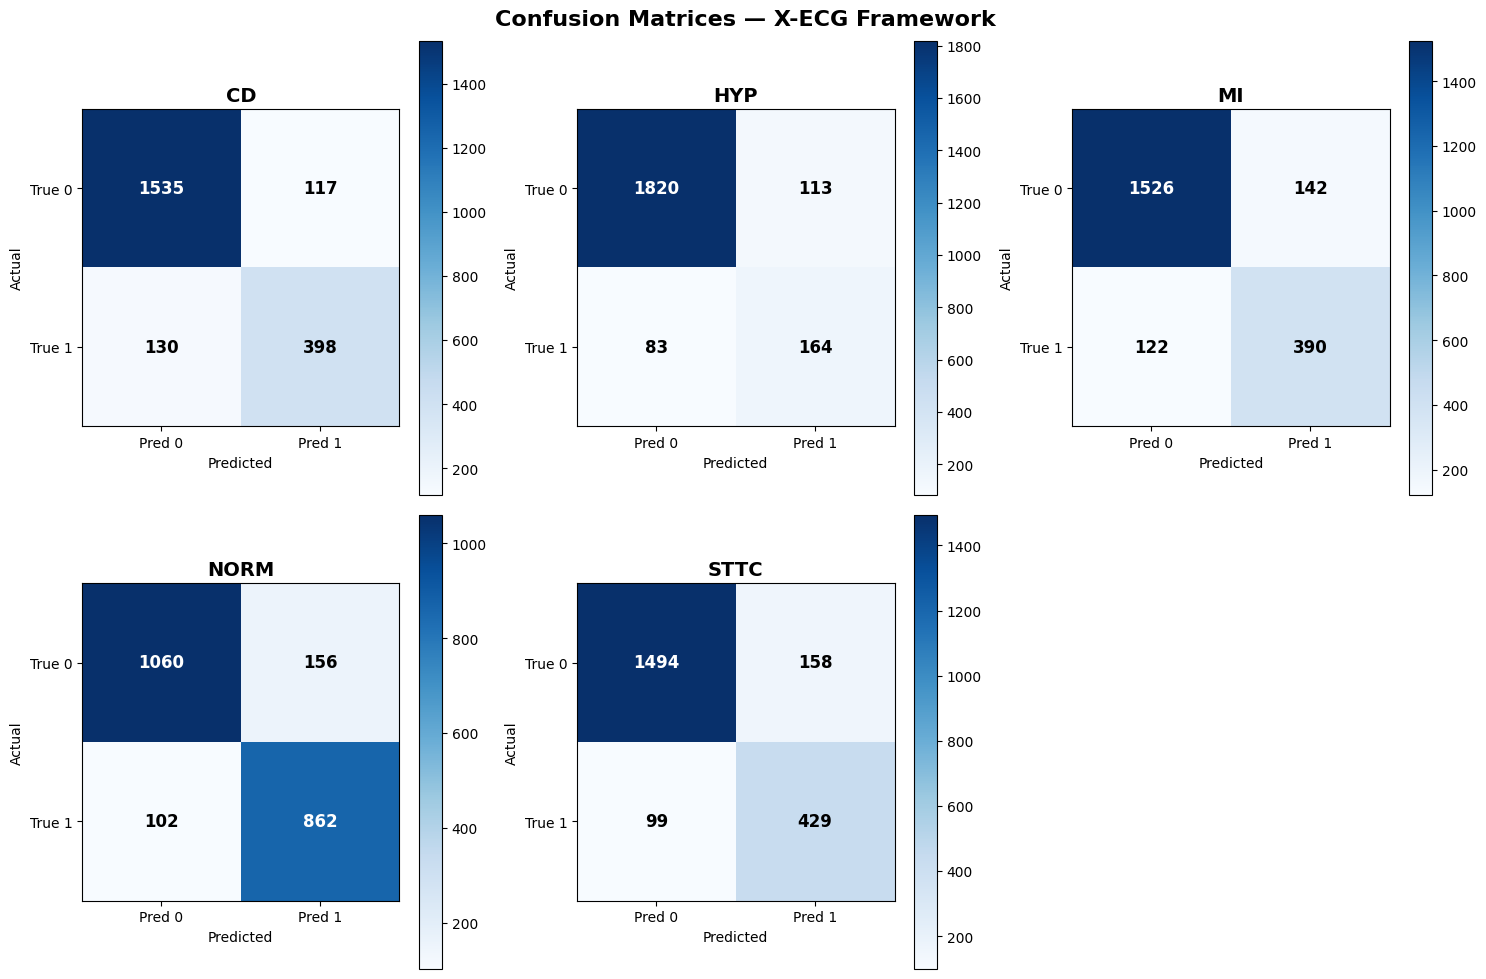

Saved: confusion_matrix_FINAL.png


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import json

BASE = r'D:\heart_disease'
y_test = np.load(f'{BASE}/y_test.npy')
y_prob = np.load(f'{BASE}/y_test_prob.npy')

with open(f'{BASE}/best_thresholds.json') as f:
    thresh = json.load(f)
class_names = thresh['classes']
tau = np.array(thresh['thresholds'])
y_pred = (y_prob >= tau).astype(int)

# Plot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, cls in enumerate(class_names):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test[:,i], y_pred[:,i])
    
    ax = axes[i]
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(cls, fontsize=14, fontweight='bold')
    
    for row in range(2):
        for col in range(2):
            ax.text(col, row, str(cm[row,col]), 
                   ha='center', va='center', 
                   fontsize=12, fontweight='bold',
                   color='white' if cm[row,col] > cm.max()/2 
                   else 'black')
    
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred 0', 'Pred 1'])
    ax.set_yticklabels(['True 0', 'True 1'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.colorbar(im, ax=ax)

axes[5].axis('off')
plt.suptitle('Confusion Matrices — X-ECG Framework', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE}/confusion_matrix_FINAL.png', 
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix_FINAL.png")

In [134]:
from sklearn.metrics import roc_auc_score

micro_auc = roc_auc_score(
    y_test,
    y_prob,
    average='micro'
)

print("Micro-average ROC AUC:", micro_auc)

Micro-average ROC AUC: 0.9427510114980513


In [70]:
print("Current AUC list:", auc_scores)

Current AUC list: [0.9342454075813293, 0.9319949150085449, 0.9358223080635071, 0.9350918531417847, 0.9333289265632629]


In [135]:
for i, layer in enumerate(model.layers):
    print(i, layer.name)

0 input_2
1 conv1d_7
2 batch_normalization_3
3 activation_3
4 global_average_pooling1d_4
5 reshape_3
6 dense_8
7 dense_9
8 multiply_3
9 max_pooling1d_3
10 conv1d_8
11 batch_normalization_4
12 activation_4
13 global_average_pooling1d_5
14 reshape_4
15 dense_10
16 dense_11
17 multiply_4
18 max_pooling1d_4
19 conv1d_9
20 batch_normalization_5
21 activation_5
22 global_average_pooling1d_6
23 reshape_5
24 dense_12
25 dense_13
26 multiply_5
27 max_pooling1d_5
28 bidirectional_1
29 spatial_dropout1d_1
30 multi_head_attention_2
31 dropout_5
32 tf.__operators__.add_4
33 layer_normalization_4
34 conv1d_10
35 dropout_6
36 conv1d_11
37 tf.__operators__.add_5
38 layer_normalization_5
39 multi_head_attention_3
40 dropout_7
41 tf.__operators__.add_6
42 layer_normalization_6
43 conv1d_12
44 dropout_8
45 conv1d_13
46 tf.__operators__.add_7
47 layer_normalization_7
48 global_average_pooling1d_7
49 dense_14
50 dropout_9
51 dense_15


In [72]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def make_gradcam_heatmap(input_signal, model, last_conv_layer_name, class_idx):

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(
            np.expand_dims(input_signal, axis=0)
        )

        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        pooled_grads * conv_outputs,
        axis=-1
    )

    heatmap = np.maximum(heatmap,0)
    heatmap /= np.max(heatmap)

    return heatmap

In [73]:
sample_idx = 10   # any test sample

heatmap = make_gradcam_heatmap(
    X_test[sample_idx],
    model,
    last_conv_layer_name='conv1d_9',
    class_idx=2   # MI example
)

In [74]:
from scipy.ndimage import gaussian_filter1d

heatmap = gaussian_filter1d(heatmap, sigma=5)

In [75]:
# import tensorflow as tf
# from tensorflow.keras import layers, models

# # =========================
# # SE BLOCK (unchanged)
# # =========================
# def squeeze_excitation_block(input_tensor, ratio=16):
#     filters = input_tensor.shape[-1]
#     se = layers.GlobalAveragePooling1D()(input_tensor)
#     se = layers.Reshape((1, filters))(se)
#     se = layers.Dense(filters // ratio, activation='relu', use_bias=False)(se)
#     se = layers.Dense(filters, activation='sigmoid', use_bias=False)(se)
#     return layers.multiply([input_tensor, se])

# # =========================
# # TRANSFORMER BLOCK (improved stability)
# # =========================
# def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.2):
#     x = layers.MultiHeadAttention(
#         key_dim=head_size, num_heads=num_heads, dropout=dropout
#     )(inputs, inputs)

#     x = layers.Dropout(dropout)(x)
#     x = layers.LayerNormalization(epsilon=1e-6)(inputs + x)

#     ffn = layers.Conv1D(ff_dim, 1, activation="relu")(x)
#     ffn = layers.Dropout(dropout)(ffn)
#     ffn = layers.Conv1D(inputs.shape[-1], 1)(ffn)

#     return layers.LayerNormalization(epsilon=1e-6)(x + ffn)

# # =========================
# # FINAL MODEL
# # =========================
# def build_final_model(input_shape=(1000,12), num_classes=5):

#     inputs = layers.Input(shape=input_shape)

#     # CNN BLOCK 1
#     x = layers.Conv1D(64, 7, padding='same')(inputs)
#     x = layers.BatchNormalization()(x)
#     x = layers.Activation('relu')(x)
#     x = squeeze_excitation_block(x)
#     x = layers.MaxPooling1D(2)(x)

#     #  CNN BLOCK 2
#     x = layers.Conv1D(128, 5, padding='same')(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.Activation('relu')(x)
#     x = squeeze_excitation_block(x)
#     x = layers.MaxPooling1D(2)(x)

#     #  NEW CNN BLOCK (important for morphology)
#     x = layers.Conv1D(256, 3, padding='same')(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.Activation('relu')(x)
#     x = squeeze_excitation_block(x)
#     x = layers.MaxPooling1D(2)(x)

#     # BiLSTM (reduced → better generalization)
#     x = layers.Bidirectional(
#         layers.LSTM(64, return_sequences=True)
#     )(x)

#     x = layers.SpatialDropout1D(0.3)(x)

#     # DOUBLE ATTENTION (very important)
#     x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128)
#     x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=128)

#     # Global pooling
#     x = layers.GlobalAveragePooling1D()(x)

#     # Dense head
#     x = layers.Dense(128, activation='relu')(x)
#     x = layers.Dropout(0.4)(x)

#     outputs = layers.Dense(num_classes, activation='sigmoid')(x)

#     model = models.Model(inputs, outputs)
#     return model

# # =========================
# # BUILD MODEL
# # =========================
# # model = build_final_model()
# # model.summary()

In [76]:
# import tensorflow as tf

# def focal_loss(gamma=2., alpha=0.25):
#     def loss(y_true, y_pred):
#         bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
#         p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
#         return tf.reduce_mean(alpha * tf.pow((1 - p_t), gamma) * bce)
#     return loss

In [77]:
# auc_metric = tf.keras.metrics.AUC(name='auc', multi_label=True)

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
#     loss=focal_loss(),
#     metrics=[auc_metric]
# )

In [78]:
# callbacks = [
#     tf.keras.callbacks.EarlyStopping(
#         monitor='val_auc',
#         patience=8,
#         mode='max',
#         restore_best_weights=True
#     ),

#     tf.keras.callbacks.ReduceLROnPlateau(
#         monitor='val_auc',
#         factor=0.3,
#         patience=3,
#         min_lr=1e-6,
#         mode='max',
#         verbose=1
#     ),

#     tf.keras.callbacks.ModelCheckpoint(
#         'best_xecg_model.h5',
#         monitor='val_auc',
#         mode='max',
#         save_best_only=True
#     )
# ]

In [79]:
import tensorflow as tf

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.config.list_physical_devices('GPU'))

Num GPUs Available: 2
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [80]:
# y_train = y_train.astype('float32')
# y_val   = y_val.astype('float32')
# y_test  = y_test.astype('float32')

In [81]:
# history = model.fit(
#     X_train, y_train,
#     validation_data=(X_val, y_val),
#     epochs=50,
#     batch_size=32,
#     callbacks=callbacks,
#     verbose=1
# )

In [82]:
# model.evaluate(X_test, y_test)

In [83]:
# model.load_weights('best_xecg_model.h5')

In [85]:
# import numpy as np
# from sklearn.metrics import f1_score, classification_report
# import pandas as pd

# # =========================
# # 1. Predictions
# # =========================
# y_pred_prob = model.predict(X_test)

# # =========================
# # 2. Auto Threshold Tuning
# # =========================
# best_thresholds = []
# best_f1_scores = []

# thresholds = np.arange(0.1, 0.9, 0.05)

# for i in range(y_test.shape[1]):  
#     f1_scores = []

#     for t in thresholds:
#         y_pred_temp = (y_pred_prob[:, i] > t).astype(int)
#         f1 = f1_score(y_test[:, i], y_pred_temp)
#         f1_scores.append(f1)

#     best_idx = np.argmax(f1_scores)
#     best_thresholds.append(thresholds[best_idx])
#     best_f1_scores.append(f1_scores[best_idx])

# # =========================
# # 3. Print Auto Results
# # =========================
# print("\n Auto Threshold Results:")
# for i, class_name in enumerate(mlb.classes_):
#     print(f"{class_name}: Threshold = {best_thresholds[i]:.2f}, F1 = {best_f1_scores[i]:.4f}")

# # =========================
# # 4. MANUAL FIX FOR HYP
# # =========================
# # Check index first (IMPORTANT)
# print("\nClass Order:", mlb.classes_)

# # Usually: ['CD', 'HYP', 'MI', 'NORM', 'STTC']
# HYP_INDEX = list(mlb.classes_).index('HYP')

# # Lower threshold for better recall
# best_thresholds[HYP_INDEX] = 0.45   # try 0.30 if needed

# print(f"\n Updated HYP Threshold: {best_thresholds[HYP_INDEX]}")

# # =========================
# # 5. Apply Final Thresholds
# # =========================
# y_pred_tuned = np.zeros_like(y_pred_prob)

# for i in range(y_test.shape[1]):
#     y_pred_tuned[:, i] = (y_pred_prob[:, i] > best_thresholds[i]).astype(int)

# # =========================
# # 6. Final Classification Report
# # =========================
# report = classification_report(
#     y_test,
#     y_pred_tuned,
#     target_names=mlb.classes_,
#     output_dict=True,
#     zero_division=0
# )

# df_report = pd.DataFrame(report).transpose()

# print("\n Final Tuned Performance:")
# print(df_report[['precision', 'recall', 'f1-score']])

In [86]:
import numpy as np

f1_scores = df_report.loc[['CD','HYP','MI','NORM','STTC'], 'f1-score'].values

print("F1 Mean:", np.mean(f1_scores))
print("F1 Std Dev:", np.std(f1_scores))

F1 Mean: 0.7564611326927718
F1 Std Dev: 0.07853678429138629


In [87]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    plt.figure(figsize=(14,5))

    #AUC Plot (instead of accuracy)
    plt.subplot(1,2,1)
    plt.plot(history.history['auc'], label='Train AUC', linewidth=2)
    plt.plot(history.history['val_auc'], label='Val AUC', linewidth=2)
    plt.title('Model AUC (Training vs Validation)', fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('AUC')
    plt.legend()
    plt.grid(alpha=0.3)

    # Loss Plot
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    plt.title('Model Loss', fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [88]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

def plot_roc_curve(model, X_test, y_test, class_names):
    y_pred_probs = model.predict(X_test, verbose=0)

    plt.figure(figsize=(10,8))

    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (PTB-XL - X-ECG Model)', fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)

    plt.show()

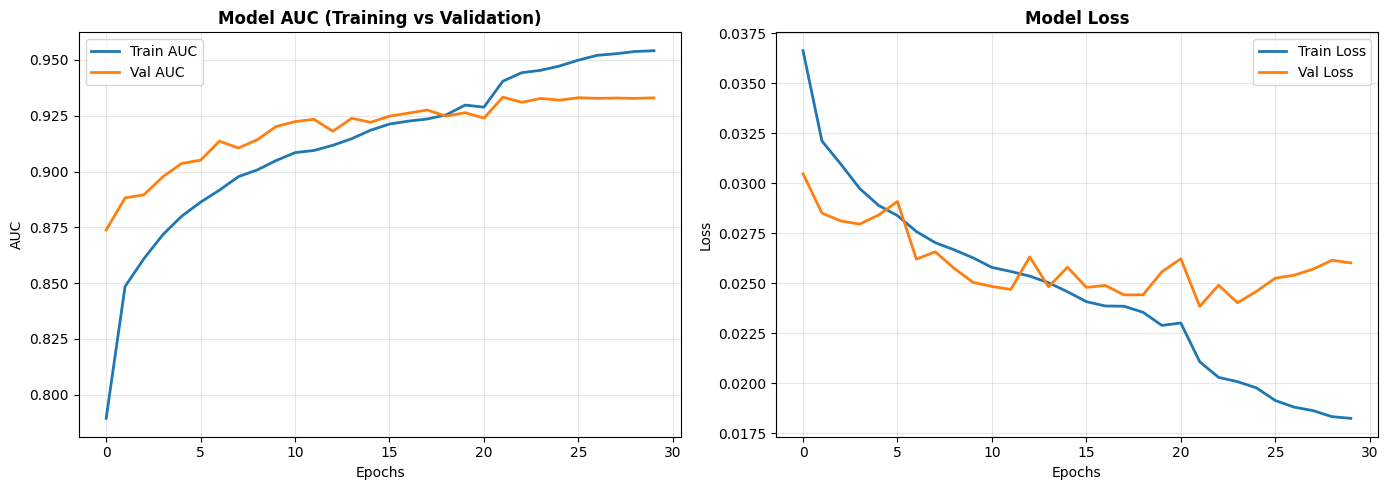

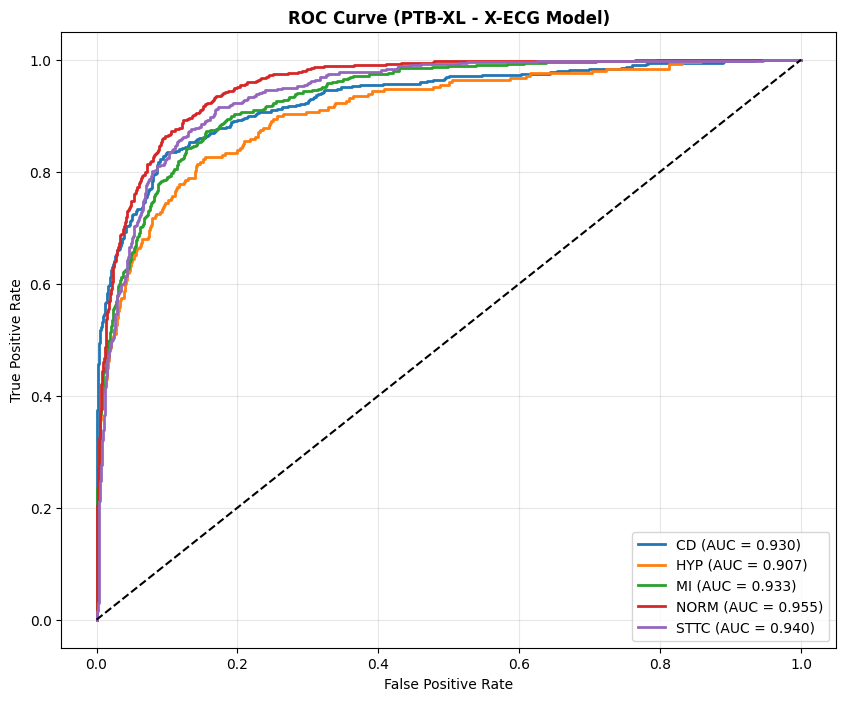

In [89]:
class_names = mlb.classes_

plot_training_history(history)   
plot_roc_curve(model, X_test, y_test, class_names)   

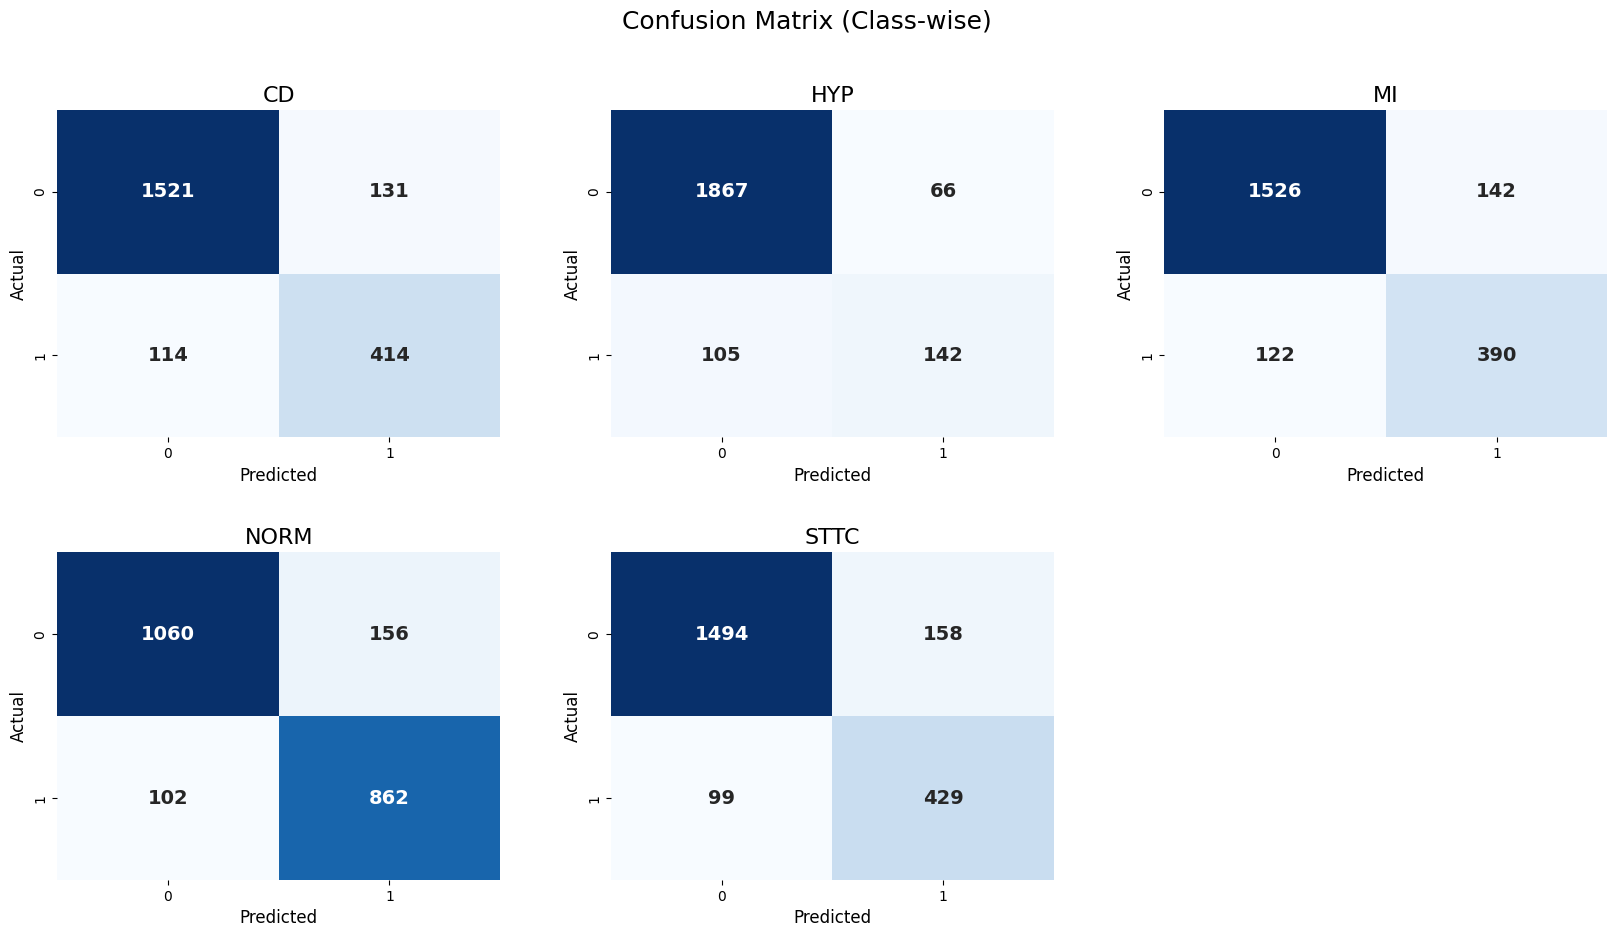

In [90]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix

def plot_confusion_matrix_grid(y_true, y_pred, class_names):
    
    mcm = multilabel_confusion_matrix(y_true, y_pred)

    # 2 rows × 3 columns (5 classes → 1 empty)
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    plt.subplots_adjust(hspace=0.35, wspace=0.25)

    axes = axes.flatten()

    for i in range(len(class_names)):
        cm = mcm[i]
        ax = axes[i]

        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            cbar=False,
            ax=ax,
            annot_kws={"size": 14, "weight": "bold"}
        )

        ax.set_title(f'{class_names[i]}', fontsize=16)
        ax.set_xlabel('Predicted', fontsize=12)
        ax.set_ylabel('Actual', fontsize=12)

        ax.set_xticklabels(['0', '1'])
        ax.set_yticklabels(['0', '1'])

    # last empty plot hide
    axes[-1].axis('off')

    plt.suptitle("Confusion Matrix (Class-wise)", fontsize=18)
    plt.show()



plot_confusion_matrix_grid(y_test, y_pred_tuned, mlb.classes_)

In [91]:
import matplotlib.pyplot as plt

def plot_training_history_new(history):
    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train Loss', color='red')
    plt.plot(history.history['val_loss'], label='Val Loss', color='blue')
    plt.title('Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

    # AUC
    plt.subplot(1,2,2)
    plt.plot(history.history['auc'], label='Train AUC', color='red')
    plt.plot(history.history['val_auc'], label='Val AUC', color='blue')
    plt.title('AUC Curve')
    plt.xlabel('Epochs')
    plt.ylabel('AUC')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

In [92]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

def plot_roc_curves_new(model, X_test, y_test, class_names):
    y_pred_probs = model.predict(X_test)

    plt.figure(figsize=(10,8))

    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, lw=2,
                 label=f'{class_names[i]} (AUC = {roc_auc:.4f})')

    # diagonal line
    plt.plot([0,1],[0,1],'k--')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (Multi-label ECG)')
    plt.legend(loc='lower right')
    plt.grid()

    plt.show()

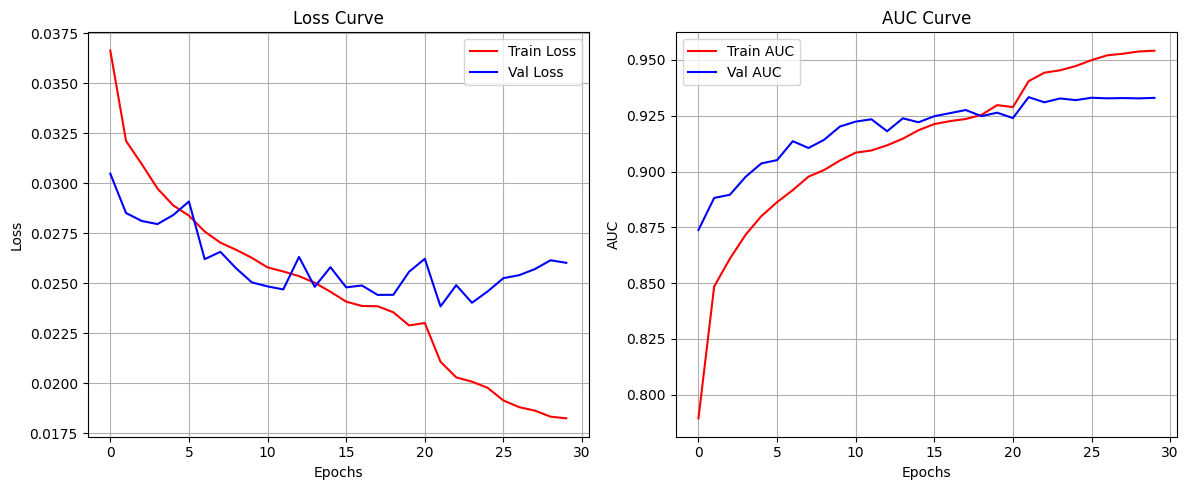

69/69 [==============================] - 1s 18ms/step


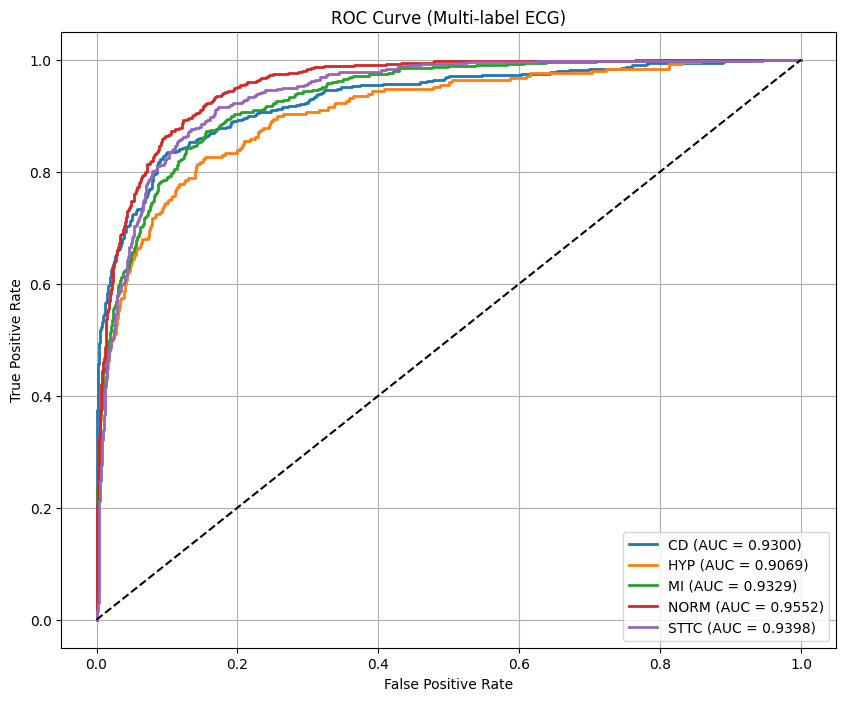

In [93]:
# Correct class order 
class_names = mlb.classes_

# 1. Training curves
plot_training_history_new(history)

# 2. ROC curves
plot_roc_curves_new(model, X_test, y_test, class_names)

In [94]:
import matplotlib.pyplot as plt
import numpy as np

def plot_model_behavior(history):
    
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = np.arange(1, len(loss) + 1)

    plt.figure(figsize=(18, 6))

    # -------------------------
    # (a) Underfitting zone (early epochs)
    # -------------------------
    plt.subplot(1, 3, 1)
    plt.plot(epochs[:10], loss[:10], label='Training Loss', color='#2ecc71', linewidth=2)
    plt.plot(epochs[:10], val_loss[:10], label='Validation Loss', color='#e67e22', linestyle='--', linewidth=2)
    plt.title('(a) Initial Learning Phase\n(Early Epoch Behavior)', fontsize=13)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(alpha=0.3)

    # -------------------------
    # (b) Ideal Fit (best region)
    # -------------------------
    best_epoch = np.argmin(val_loss)

    plt.subplot(1, 3, 2)
    plt.plot(epochs, loss, label='Training Loss', color='#2ecc71', linewidth=3)
    plt.plot(epochs, val_loss, label='Validation Loss', color='#e67e22', linestyle='--', linewidth=3)

    plt.scatter(best_epoch+1, val_loss[best_epoch], color='red', s=80)
    plt.annotate('Best Generalization',
                 xy=(best_epoch+1, val_loss[best_epoch]),
                 xytext=(best_epoch+5, val_loss[best_epoch]+0.01),
                 arrowprops=dict(facecolor='black', shrink=0.05))

    plt.title('(b) Optimal Fit (Your Proposed Model)\n(CNN-BiLSTM-Attention)', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(alpha=0.3)

    # -------------------------
    # (c) Overfitting region
    # -------------------------
    plt.subplot(1, 3, 3)
    plt.plot(epochs, loss, label='Training Loss', color='#2ecc71', linewidth=2)
    plt.plot(epochs, val_loss, label='Validation Loss', color='#e67e22', linestyle='--', linewidth=2)

    # Overfitting highlight
    plt.axvline(x=best_epoch+1, color='red', linestyle='--', label='Overfitting starts')

    plt.title('(c) Overfitting Trend (Later Epochs)', fontsize=13)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(alpha=0.3)

    # -------------------------
    plt.suptitle(
        "Model Generalization Analysis (PTB-XL)\nProposed CNN-BiLSTM-Attention Framework",
        fontsize=16,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()


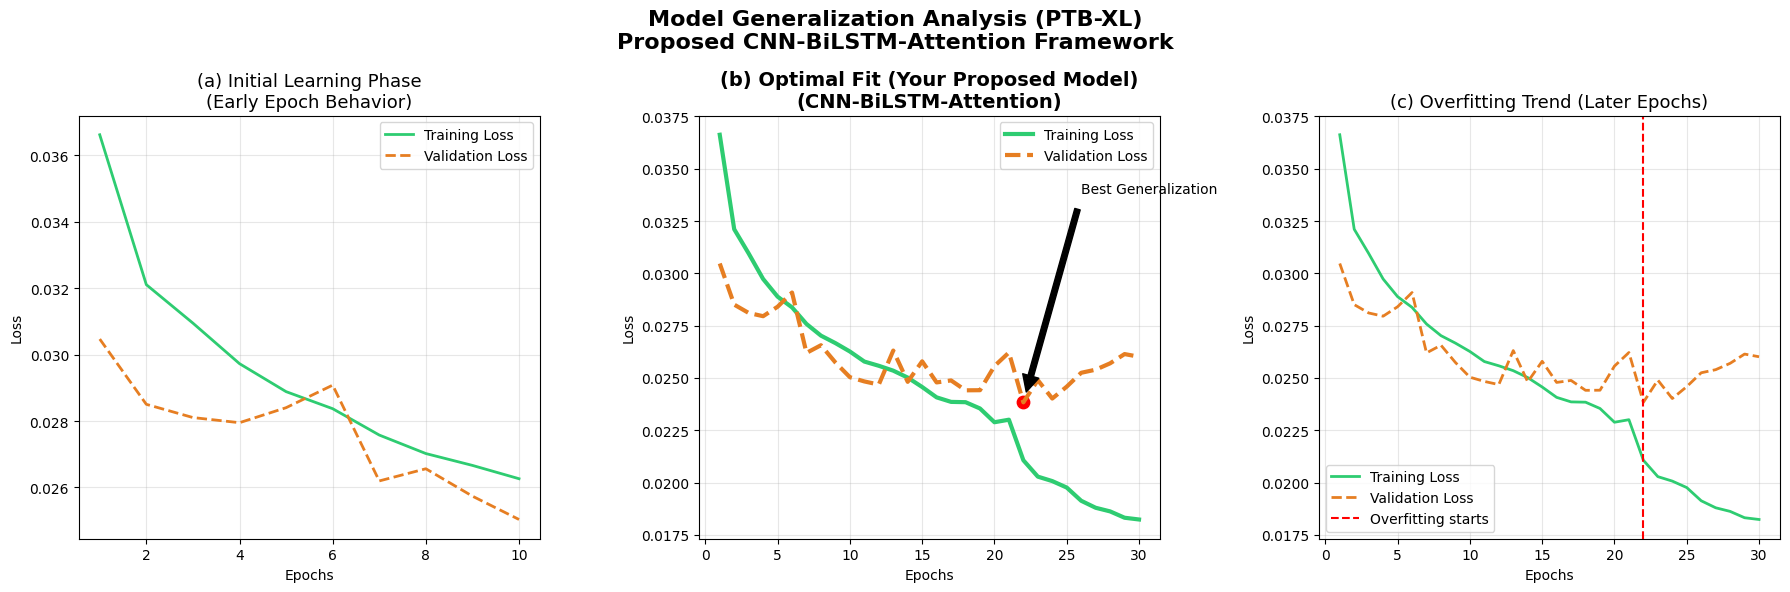

In [95]:
plot_model_behavior(history)

In [ ]:
# import tensorflow as tf
# import numpy as np

# def integrated_gradients(model, input_signal, target_class_idx, steps=50):
#     """
#     Integrated Gradients for ECG (Hybrid Model Compatible)
#     input_signal: (1, 1000, 12)
#     """

#     input_signal = tf.cast(input_signal, tf.float32)
#     baseline = tf.zeros_like(input_signal)

#     # Interpolation
#     alphas = tf.linspace(0.0, 1.0, steps)

#     interpolated = []
#     for alpha in alphas:
#         interpolated.append(baseline + alpha * (input_signal - baseline))

#     interpolated = tf.concat(interpolated, axis=0)  # (steps, 1000, 12)

#     # Gradient computation
#     with tf.GradientTape() as tape:
#         tape.watch(interpolated)
#         preds = model(interpolated)
#         target = preds[:, target_class_idx]

#     grads = tape.gradient(target, interpolated)

#     # Average gradients
#     avg_grads = tf.reduce_mean(grads, axis=0)

#     # IG formula
#     ig = (input_signal[0] - baseline[0]) * avg_grads

#     return ig.numpy()

In [ ]:
# import matplotlib.pyplot as plt
# from matplotlib.collections import LineCollection

# def plot_ig_ecg(signal, attribution, class_name):

#     ecg = signal[0, :, 1]  # Lead II
#     attr = np.abs(attribution[:, 1])

#     # Normalize
#     attr = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)

#     # Threshold (clean look)
#     attr = np.where(attr > 0.1, attr, 0)

#     time = np.arange(len(ecg))

#     fig, ax = plt.subplots(figsize=(16, 5))

#     # Background ECG
#     ax.plot(time, ecg, color='lightgray', alpha=0.6)

#     # Colored segments
#     points = np.array([time, ecg]).T.reshape(-1, 1, 2)
#     segments = np.concatenate([points[:-1], points[1:]], axis=1)

#     lc = LineCollection(segments, cmap='hot', array=attr)
#     lc.set_linewidth(3)

#     line = ax.add_collection(lc)

#     cbar = plt.colorbar(line, ax=ax)
#     cbar.set_label("Importance")

#     ax.set_title(f"Integrated Gradients (Class: {class_name})", fontsize=14)
#     ax.set_xlabel("Time")
#     ax.set_ylabel("Amplitude")

#     ax.set_xlim(0, len(ecg))
#     ax.set_ylim(min(ecg)-0.2, max(ecg)+0.2)

#     ax.grid(True, linestyle=':')

#     plt.tight_layout()
#     plt.show()

In [ ]:
# def plot_all_classes_ig(model, sample, class_names):

#     ecg = sample[0, :, 1]

#     fig, axes = plt.subplots(5, 1, figsize=(16, 10))

#     for i, class_name in enumerate(class_names):

#         ig = integrated_gradients(model, sample, i)

#         attr = np.abs(ig[:, 1])
#         attr = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)
#         attr = np.where(attr > 0.1, attr, 0)

#         time = np.arange(len(ecg))

#         axes[i].plot(ecg, color='lightgray')

#         points = np.array([time, ecg]).T.reshape(-1, 1, 2)
#         segments = np.concatenate([points[:-1], points[1:]], axis=1)

#         lc = LineCollection(segments, cmap='hot', array=attr)
#         lc.set_linewidth(2.5)

#         axes[i].add_collection(lc)
#         axes[i].set_title(f"{class_name}")

#         axes[i].set_xlim(0, len(ecg))
#         axes[i].set_ylim(min(ecg)-0.2, max(ecg)+0.2)

#     plt.tight_layout()
#     plt.show()

1/1 [==============================] - 0s 69ms/step
Predicted: MI


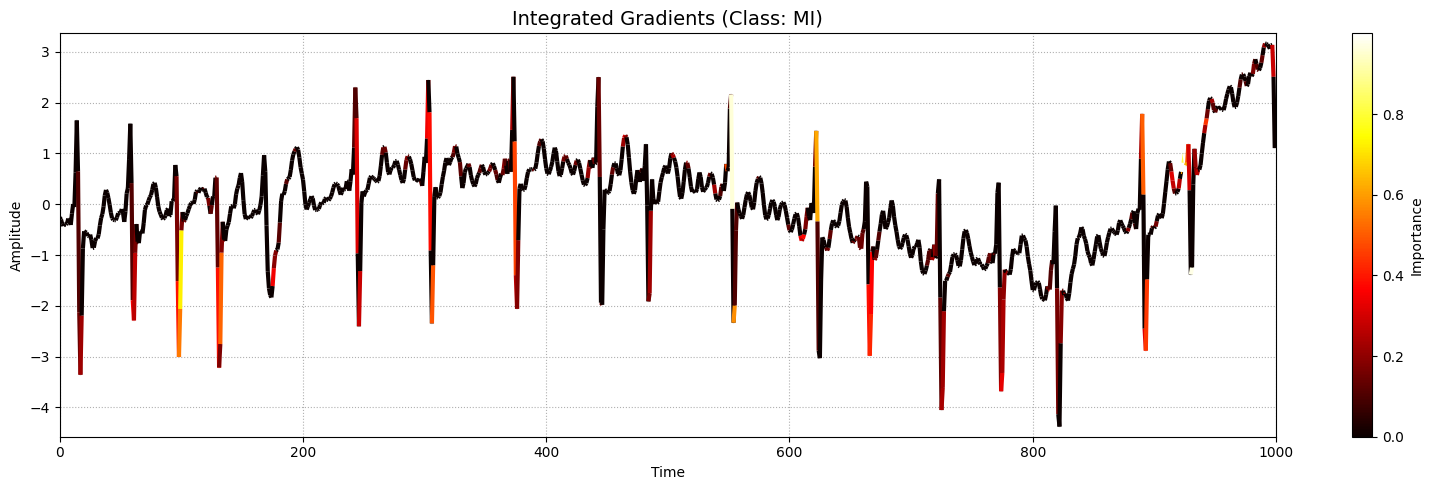

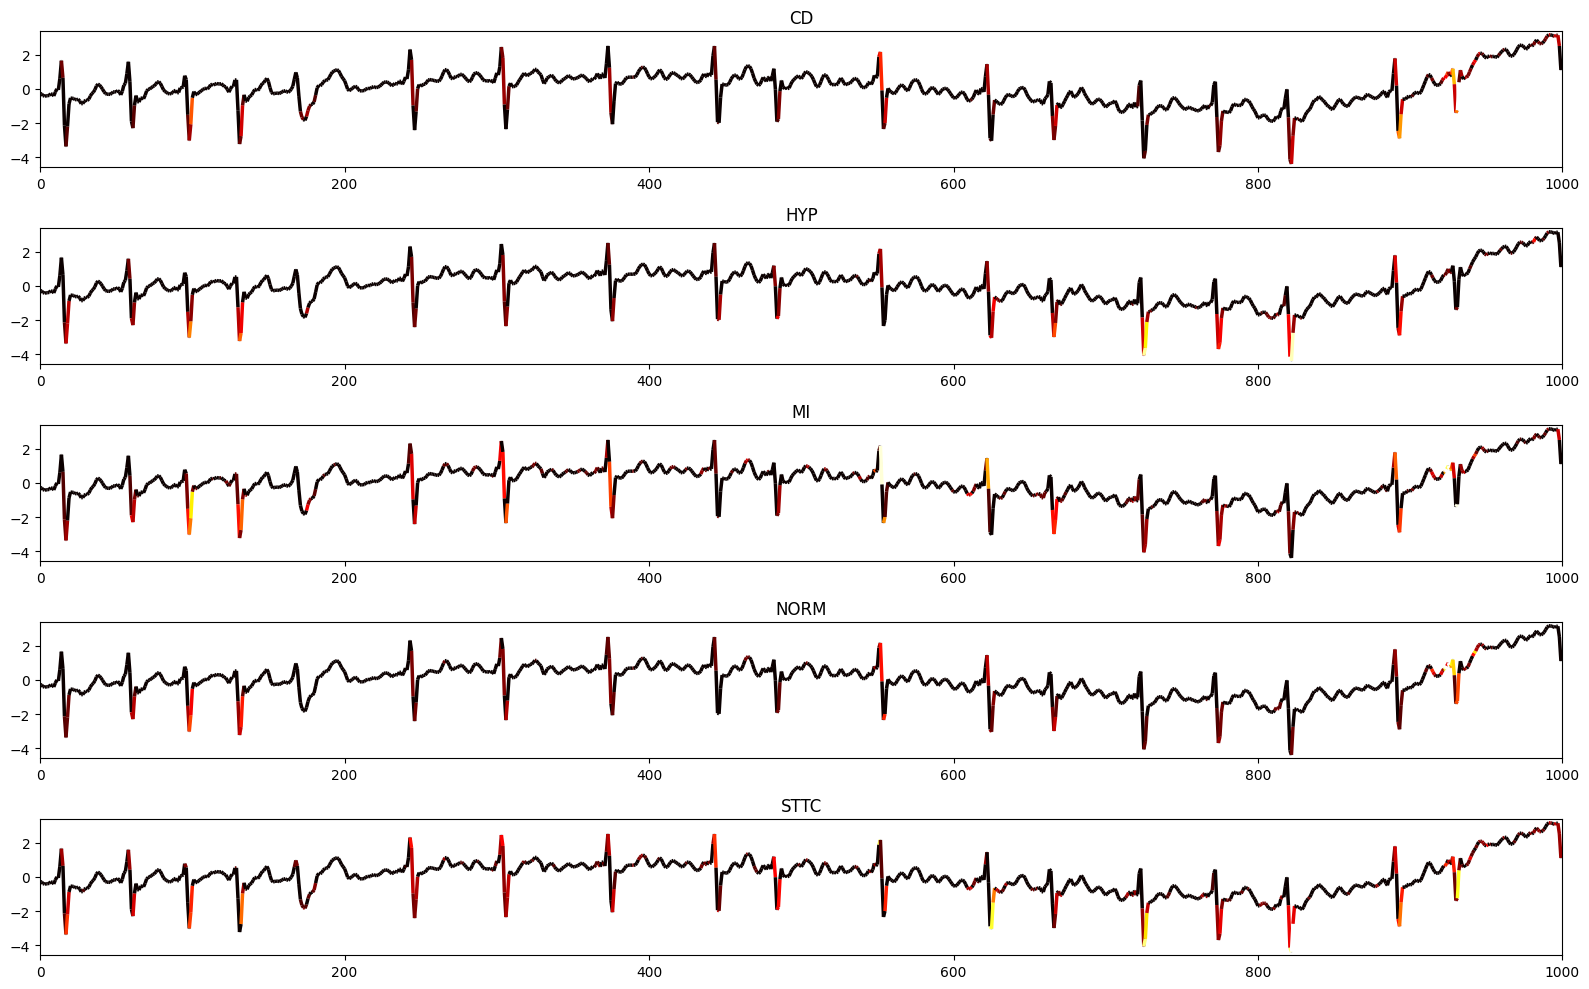

In [ ]:
# sample_idx = 25
# sample = X_test[sample_idx:sample_idx+1]

# class_names = list(mlb.classes_)

# # Prediction
# preds = model.predict(sample)
# pred_idx = np.argmax(preds[0])

# print("Predicted:", class_names[pred_idx])

# # Single class IG
# ig = integrated_gradients(model, sample, pred_idx)
# plot_ig_ecg(sample, ig, class_names[pred_idx])

# # ALL classes (paper figure 🔥)
# plot_all_classes_ig(model, sample, class_names)

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import tensorflow as tf

def plot_tsne_evolution_final(model, X_data, y_labels):

    # =========================
    # 1. Select 2 classes (clean visualization)
    # =========================
    class_names = list(mlb.classes_)

    idx_norm = np.where(y_labels[:, class_names.index('NORM')] == 1)[0]
    idx_cd   = np.where(y_labels[:, class_names.index('CD')] == 1)[0]

    np.random.seed(42)

    selected_indices = np.concatenate([
        np.random.choice(idx_norm, 150, replace=False),
        np.random.choice(idx_cd, 150, replace=False)
    ])

    X_subset = X_data[selected_indices]

    y_subset = np.array([
        0 if i in idx_norm else 1 for i in selected_indices
    ])

    # =========================
    # 2. IMPORTANT: Correct layers from YOUR model
    # =========================
    layer_names = []

    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv1D):
            layer_names.append(layer.name)

    # pick meaningful layers
    conv_layer = layer_names[-1]  # last CNN block
    lstm_layer = [l.name for l in model.layers if 'bidirectional' in l.name][0]
    attn_layer = [l.name for l in model.layers if 'multi_head_attention' in l.name][0]
    dense_layer = [l.name for l in model.layers if 'dense' in l.name][-2]

    stages = [conv_layer, lstm_layer, attn_layer, dense_layer]

    stage_titles = [
        "CNN Feature Extraction",
        "Temporal (BiLSTM)",
        "Attention Learning",
        "Final Decision Space"
    ]

    # =========================
    # 3. Plot
    # =========================
    plt.figure(figsize=(18, 14))

    for i, layer_name in enumerate(stages):

        print(f"Processing: {layer_name}")

        intermediate_model = tf.keras.Model(
            inputs=model.input,
            outputs=model.get_layer(layer_name).output
        )

        features = intermediate_model.predict(X_subset, verbose=0)

        # flatten / reduce
        if len(features.shape) > 2:
            features = np.mean(features, axis=1)

        # =========================
        # t-SNE
        # =========================
        tsne = TSNE(n_components=2, perplexity=30, random_state=42)
        embeds = tsne.fit_transform(features)

        plt.subplot(2, 2, i+1)

        colors = ['blue' if y == 0 else 'red' for y in y_subset]

        plt.scatter(
            embeds[:, 0],
            embeds[:, 1],
            c=colors,
            s=60,
            alpha=0.7,
            edgecolors='black'
        )

        plt.title(stage_titles[i], fontsize=14, fontweight='bold')
        plt.grid(alpha=0.2)

    plt.suptitle(
        "t-SNE Evolution in Hybrid ECG Model",
        fontsize=18,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()

Processing: conv1d_13


d:\ecg_env\lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\ecg_env\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "d:\ecg_env\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "d:\ecg_env\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "d:\ecg_env\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "d:\ecg_env\lib\subprocess.py", line 1456, in _execute_child
   

Processing: bidirectional_1
Processing: multi_head_attention_2
Processing: dense_14


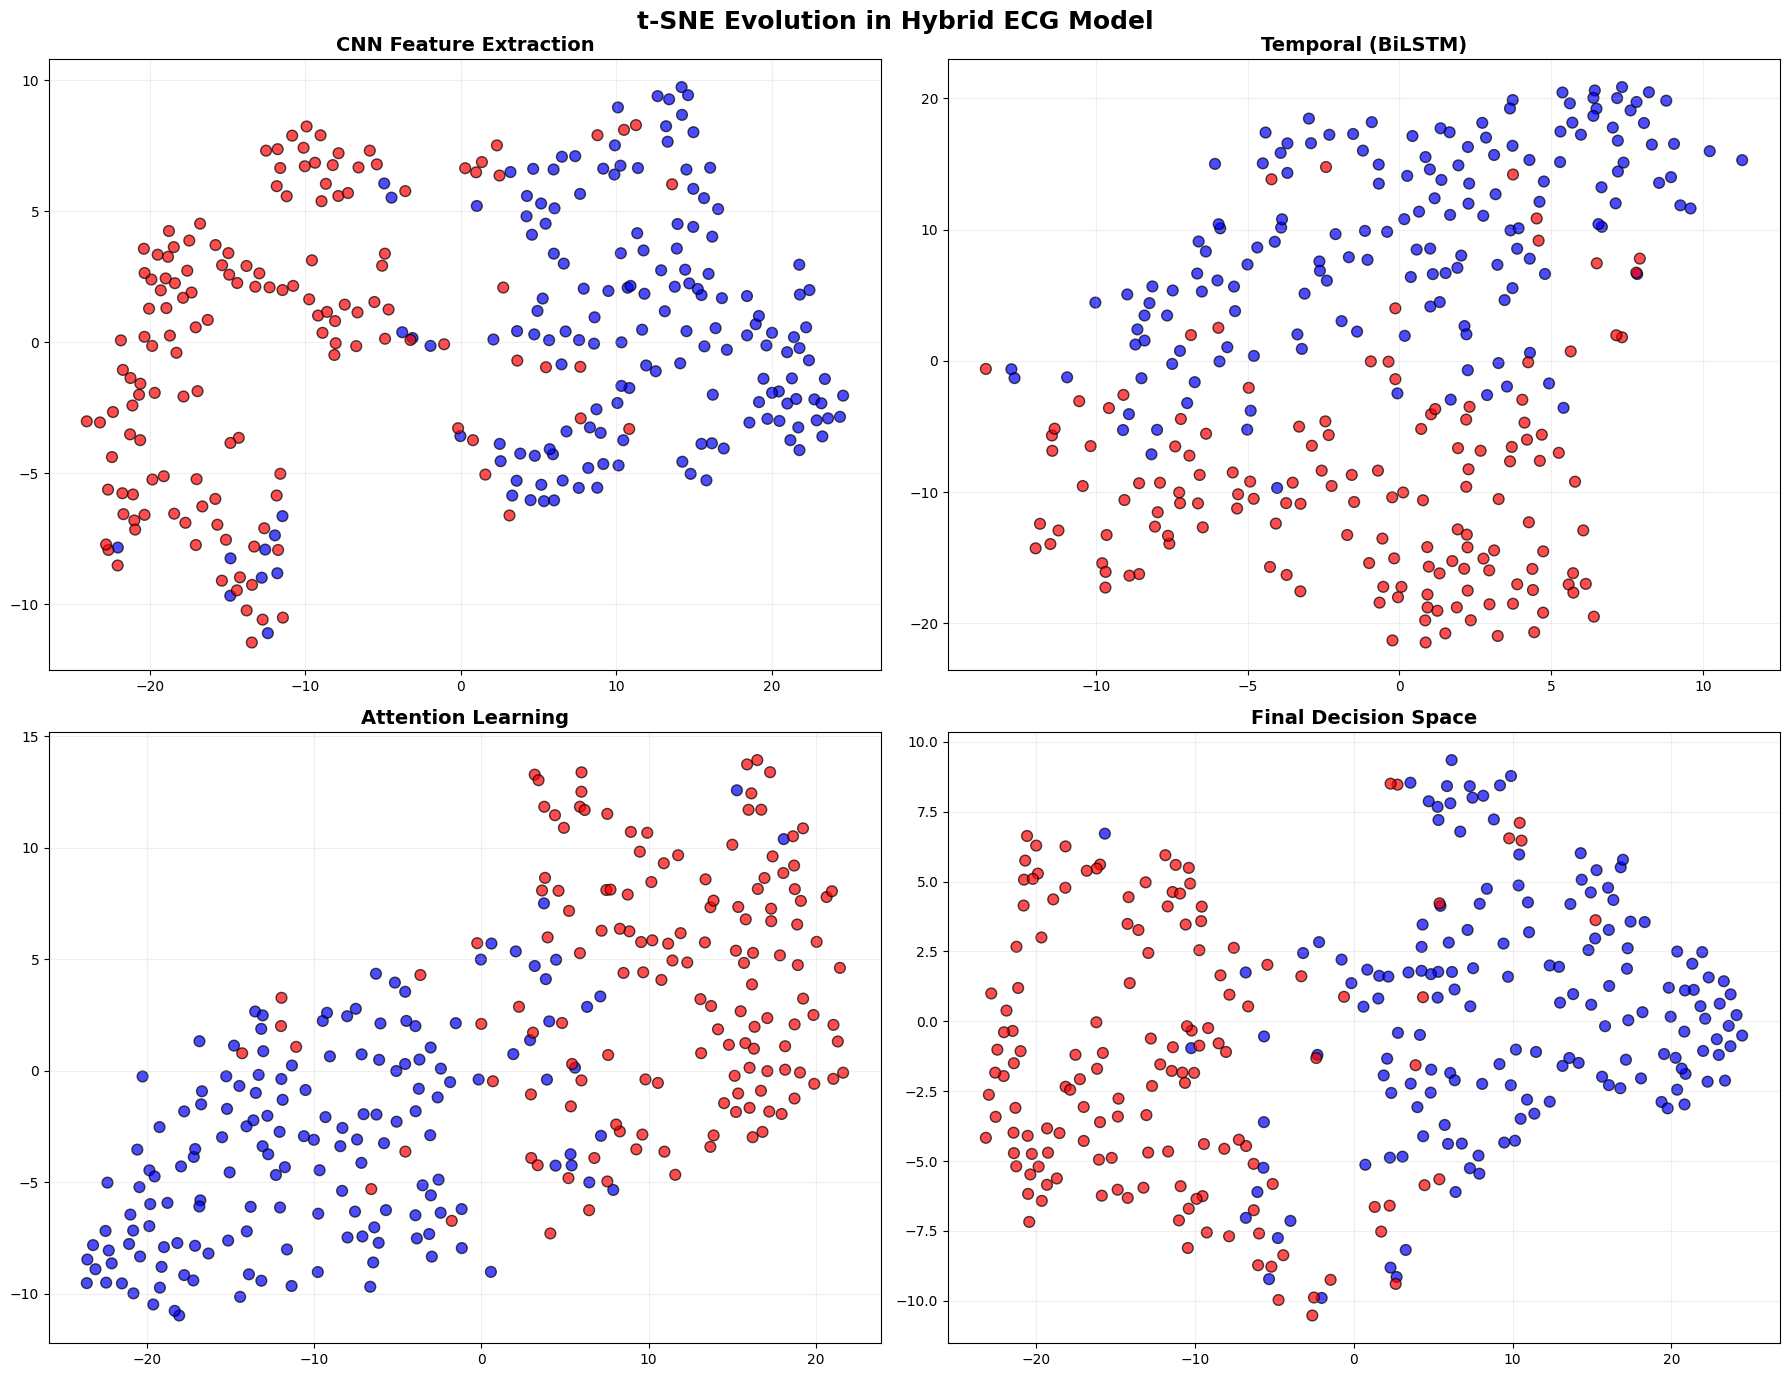

In [103]:
plot_tsne_evolution_final(model, X_test, y_test)

In [ ]:
# import tensorflow as tf
# import numpy as np

# def integrated_gradients(model, input_signal, class_idx, steps=100):

#     # Ensure float
#     input_signal = tf.cast(input_signal, tf.float32)   # (1,1000,12)
#     baseline = tf.zeros_like(input_signal)

#     # Remove batch dim → (1000,12)
#     input_signal = input_signal[0]
#     baseline = baseline[0]

#     # Interpolation
#     alphas = tf.linspace(0.0, 1.0, steps)

#     # Create interpolated inputs → (steps,1000,12)
#     interpolated = baseline + alphas[:, None, None] * (input_signal - baseline)

#     # Gradient computation
#     with tf.GradientTape() as tape:
#         tape.watch(interpolated)
#         preds = model(interpolated)   # ✅ correct shape
#         target = preds[:, class_idx]

#     grads = tape.gradient(target, interpolated)

#     # Average gradients
#     avg_grads = tf.reduce_mean(grads, axis=0)

#     # Final IG
#     ig = (input_signal - baseline) * avg_grads

#     return ig.numpy()

In [ ]:
# import matplotlib.pyplot as plt

# def plot_ig(signal, ig_attr, class_name, lead=1):

#     ecg = signal[0, :, lead]   # Lead II
#     attr = np.abs(ig_attr[:, lead])

#     # Normalize
#     attr = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)

#     # Highlight top regions (top 10%)
#     threshold = np.percentile(attr, 90)
#     mask = attr > threshold

#     time = np.arange(len(ecg))

#     plt.figure(figsize=(16,5))

#     # Base ECG
#     plt.plot(time, ecg, color='gray', alpha=0.6, label='ECG Signal')

#     # Important points
#     plt.scatter(time[mask], ecg[mask],
#                 color='red', s=25, label='Important Regions')

#     # Highlight band
#     plt.fill_between(time, ecg.min(), ecg.max(),
#                      where=mask, color='red', alpha=0.1)

#     plt.title(f"Integrated Gradients Explanation → {class_name}", fontsize=14)
#     plt.xlabel("Time")
#     plt.ylabel("Amplitude")
#     plt.legend()
#     plt.grid(alpha=0.3)

#     plt.show()

1/1 [==============================] - 0s 42ms/step
Predicted Class: MI


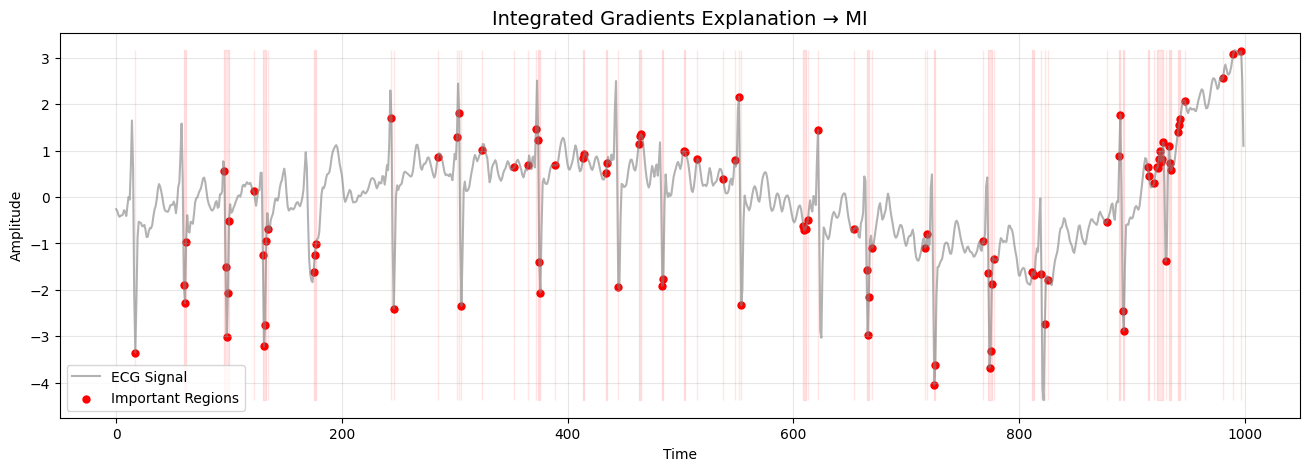

In [ ]:
# sample = X_test[25:26]

# preds = model.predict(sample)
# class_idx = np.argmax(preds[0])

# print("Predicted Class:", mlb.classes_[class_idx])

# ig = integrated_gradients(model, sample, class_idx, steps=100)

# plot_ig(sample, ig, mlb.classes_[class_idx])


Class: CD


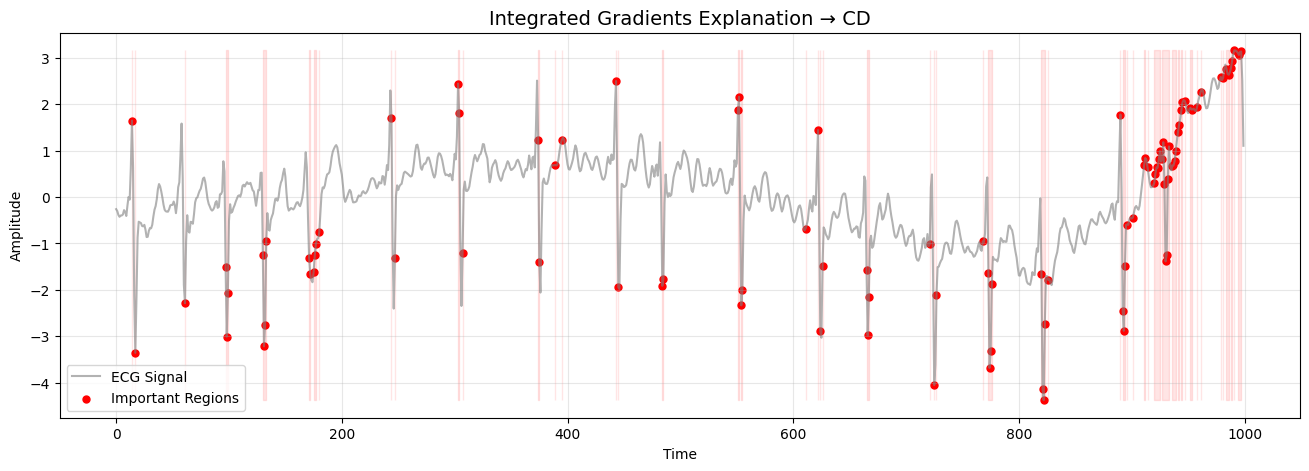


Class: HYP


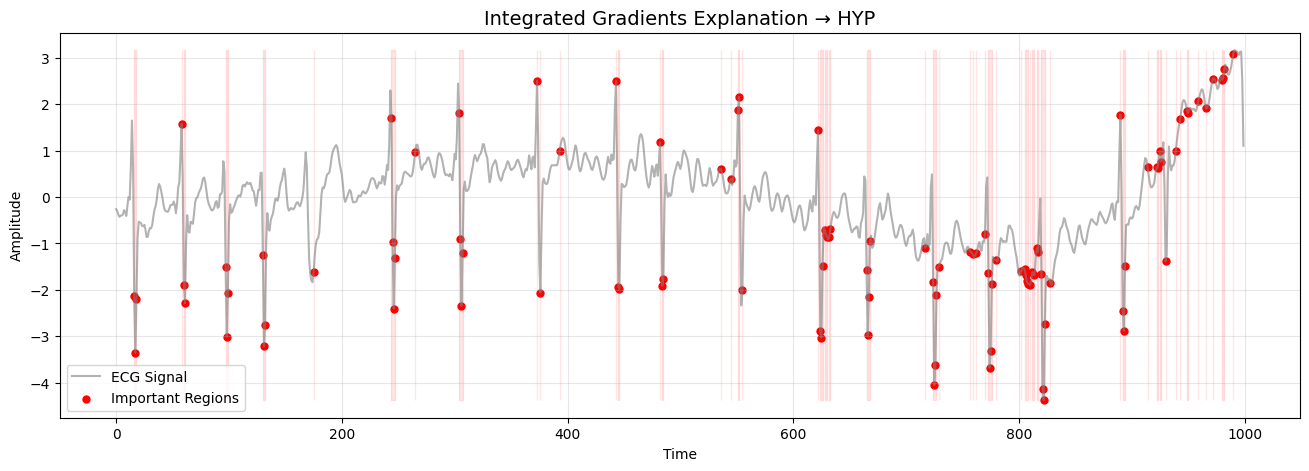


Class: MI


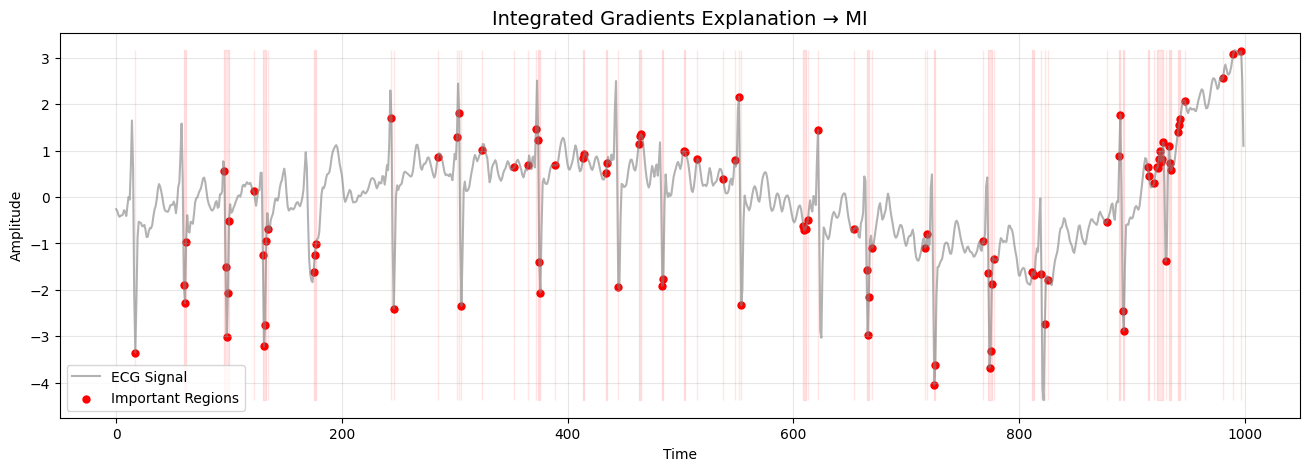


Class: NORM


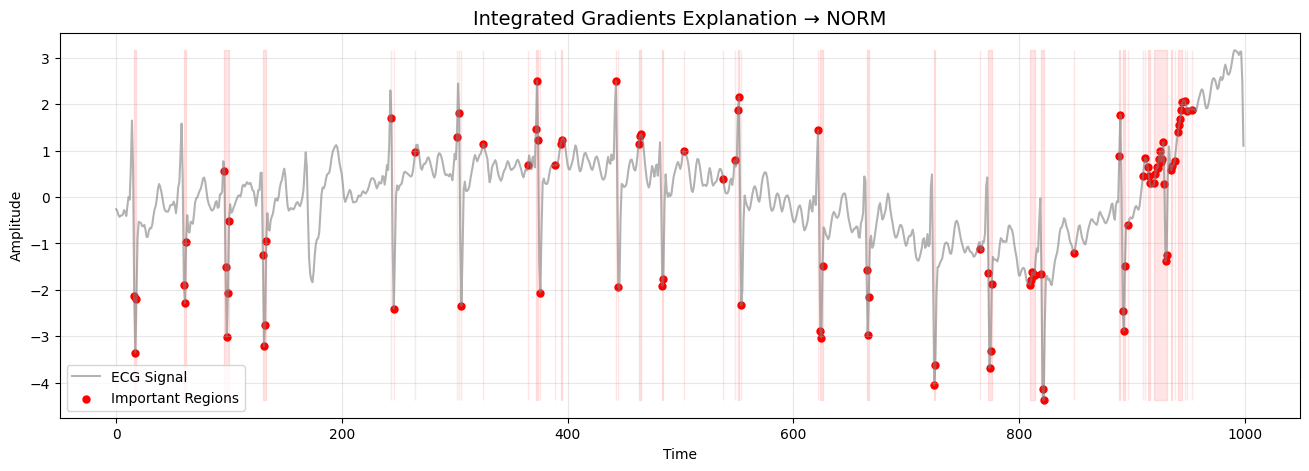


Class: STTC


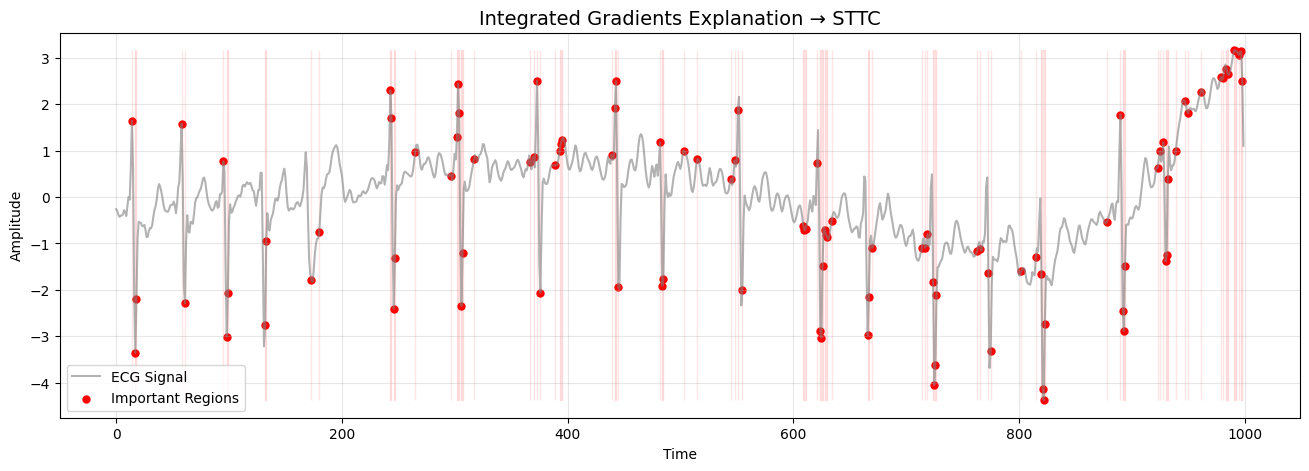

In [107]:
sample = X_test[25:26]

for i, class_name in enumerate(mlb.classes_):
    
    ig = integrated_gradients(model, sample, i, steps=100)
    
    print(f"\nClass: {class_name}")
    plot_ig(sample, ig, class_name)

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import tensorflow as tf

# def plot_internal_activations(model, X_data, sample_index=25, layer_name=None):

#     # =========================
#     # 1. AUTO SELECT BEST LAYER
#     # =========================
#     if layer_name is None:
#         for layer in model.layers:
#             if isinstance(layer, tf.keras.layers.MultiHeadAttention):
#                 layer_name = layer.name
#                 break

#     print(f"Using layer: {layer_name}")

#     # =========================
#     # 2. SAMPLE
#     # =========================
#     sample = X_data[sample_index:sample_index+1]

#     # =========================
#     # 3. INTERMEDIATE MODEL
#     # =========================
#     try:
#         intermediate_model = tf.keras.Model(
#             inputs=model.input,
#             outputs=model.get_layer(layer_name).output
#         )
#         features = intermediate_model.predict(sample, verbose=0)

#     except:
#         print("⚠️ Fallback → Last Conv Layer")

#         for layer in reversed(model.layers):
#             if isinstance(layer, tf.keras.layers.Conv1D):
#                 layer_name = layer.name
#                 break

#         intermediate_model = tf.keras.Model(
#             inputs=model.input,
#             outputs=model.get_layer(layer_name).output
#         )
#         features = intermediate_model.predict(sample, verbose=0)

#     # =========================
#     # 4. PROCESS FEATURES
#     # =========================
#     if len(features.shape) == 3:
#         # (1, time, channels)
#         matrix = features[0]

#     else:
#         flat = features.flatten()
#         size = int(np.sqrt(len(flat)))
#         matrix = flat[:size*size].reshape(size, size)

#     # =========================
#     # 5. NORMALIZE
#     # =========================
#     matrix = (matrix - matrix.min()) / (matrix.max() - matrix.min() + 1e-8)

#     # =========================
#     # 6. PLOT (PAPER READY)
#     # =========================
#     plt.figure(figsize=(12,6))

#     im = plt.imshow(
#         matrix,
#         cmap='inferno',   # better than magma/jet
#         aspect='auto'
#     )

#     plt.colorbar(im, label='Activation Strength')

#     plt.title(
#         f"Internal Activations (Hybrid Model)\nLayer: {layer_name}",
#         fontsize=13,
#         fontweight='bold'
#     )

#     plt.xlabel("Feature Channels")
#     plt.ylabel("Time Steps")

#     plt.tight_layout()
#     plt.show()

Using layer: conv1d_14
⚠️ Fallback → Last Conv Layer


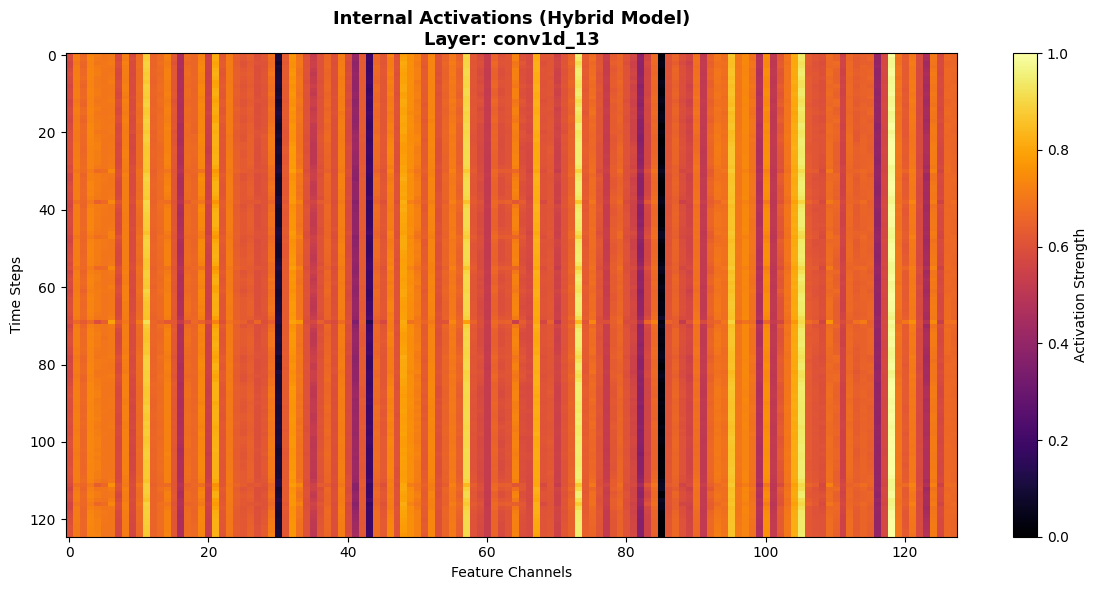

Using layer: bidirectional
⚠️ Fallback → Last Conv Layer


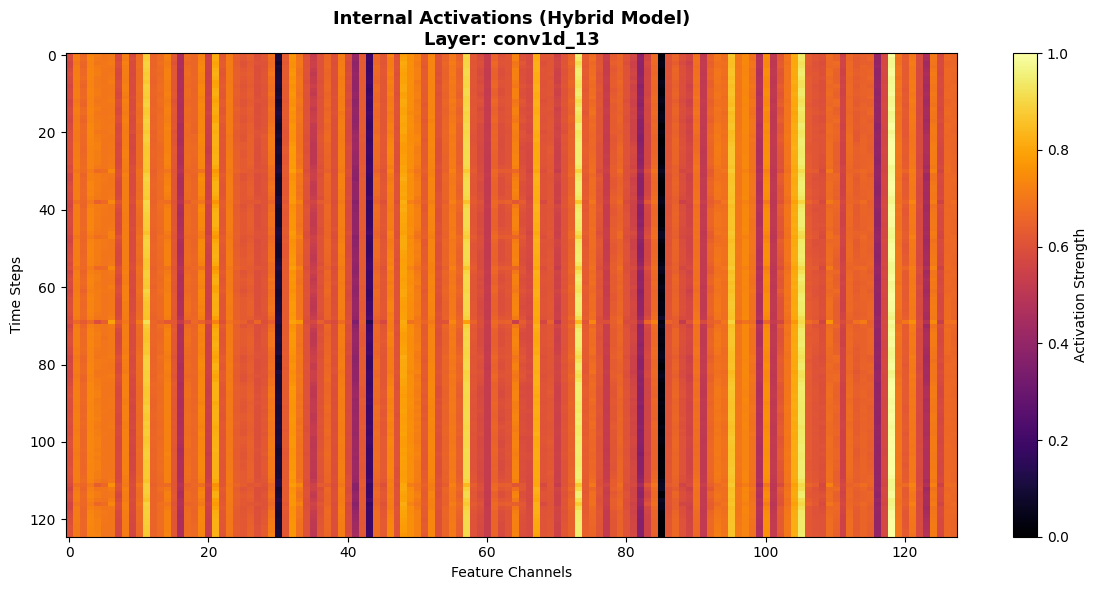

Using layer: multi_head_attention_2


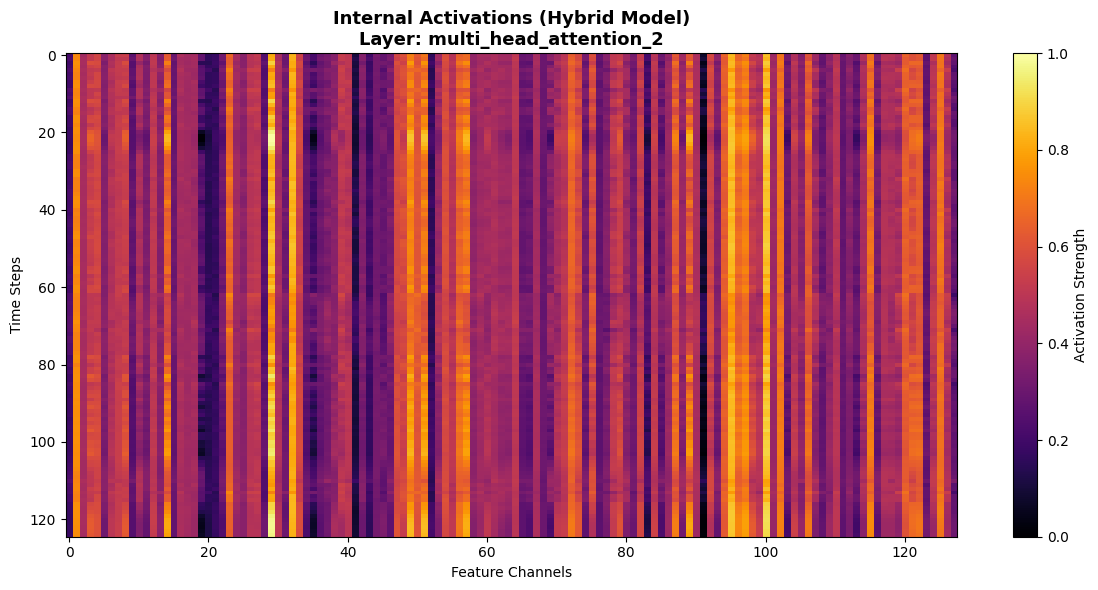

In [ ]:
# # CNN
# plot_internal_activations(model, X_test, 25, 'conv1d_14')

# # LSTM
# plot_internal_activations(model, X_test, 25, 'bidirectional')

# # Attention
# plot_internal_activations(model, X_test, 25)

In [ ]:
# import tensorflow as tf
# import numpy as np
# import matplotlib.pyplot as plt

In [ ]:
# for layer in model.layers:
#     print(layer.name, layer.output.shape)

input_2 (None, 1000, 12)
conv1d_7 (None, 1000, 64)
batch_normalization_3 (None, 1000, 64)
activation_3 (None, 1000, 64)
global_average_pooling1d_4 (None, 64)
reshape_3 (None, 1, 64)
dense_8 (None, 1, 4)
dense_9 (None, 1, 64)
multiply_3 (None, 1000, 64)
max_pooling1d_3 (None, 500, 64)
conv1d_8 (None, 500, 128)
batch_normalization_4 (None, 500, 128)
activation_4 (None, 500, 128)
global_average_pooling1d_5 (None, 128)
reshape_4 (None, 1, 128)
dense_10 (None, 1, 8)
dense_11 (None, 1, 128)
multiply_4 (None, 500, 128)
max_pooling1d_4 (None, 250, 128)
conv1d_9 (None, 250, 256)
batch_normalization_5 (None, 250, 256)
activation_5 (None, 250, 256)
global_average_pooling1d_6 (None, 256)
reshape_5 (None, 1, 256)
dense_12 (None, 1, 16)
dense_13 (None, 1, 256)
multiply_5 (None, 250, 256)
max_pooling1d_5 (None, 125, 256)
bidirectional_1 (None, 125, 128)
spatial_dropout1d_1 (None, 125, 128)
multi_head_attention_2 (None, 125, 128)
dropout_5 (None, 125, 128)
tf.__operators__.add_4 (None, 125, 128)
layer